In [1]:
# Waveform and Firing Rate Clustering Analysis
# This notebook performs comprehensive clustering analysis combining waveform data with firing rate and bursting metrics

import pynapple as nap
from spikeinterface import load_sorting_analyzer
import spikeinterface.widgets as sw
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import fnmatch
import matplotlib as mpl
import re
import os
from scipy import stats
from sklearn.decomposition import PCA, FastICA
from scipy.linalg import norm
from scipy.stats import kstest
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import umap
from scipy.signal import correlate
import warnings
warnings.filterwarnings('ignore')

print("All imports loaded successfully!")

# Bursting capacity metrics based on autocorrelograms
def calculate_autocorrelogram(spike_times, bin_size=0.001, window_size=0.1):
    """
    Calculate autocorrelogram for spike times.
    
    Parameters:
    - spike_times: array of spike times in seconds
    - bin_size: bin size in seconds (default 1ms)
    - window_size: window size in seconds (default 100ms)
    
    Returns:
    - bins: time bins
    - autocorr: autocorrelogram values
    """
    if len(spike_times) < 2:
        return np.array([0]), np.array([0])
    
    # Create bins
    bins = np.arange(-window_size, window_size + bin_size, bin_size)
    
    # Calculate autocorrelogram
    autocorr = np.zeros(len(bins) - 1)
    
    for i, spike_time in enumerate(spike_times):
        # Find all other spikes
        other_spikes = np.concatenate([spike_times[:i], spike_times[i+1:]])
        
        # Calculate time differences
        time_diffs = other_spikes - spike_time
        
        # Bin the differences
        hist, _ = np.histogram(time_diffs, bins=bins)
        autocorr += hist
    
    # Normalize by number of spikes
    autocorr = autocorr / len(spike_times)
    
    return bins[:-1], autocorr

def calculate_bursting_metrics(spike_times, bin_size=0.001, window_size=0.1):
    """
    Calculate multiple bursting capacity metrics from autocorrelogram.
    
    Returns a dictionary with various bursting metrics:
    1. Burst Index: ratio of short-interval spikes to long-interval spikes
    2. Refractory Period Violation: spikes in refractory period
    3. Burst Peak Height: height of the first peak after time 0
    4. Burst Peak Width: width of the first peak
    5. Autocorr Skewness: skewness of the autocorrelogram
    6. Short ISI Ratio: ratio of ISIs < 10ms to total ISIs
    """
    if len(spike_times) < 10:  # Need sufficient spikes for reliable metrics
        return {
            'burst_index': 0,
            'refractory_violation': 0,
            'burst_peak_height': 0,
            'burst_peak_width': 0,
            'autocorr_skewness': 0,
            'short_isi_ratio': 0,
            'autocorr_vector': np.zeros(200)  # Fixed size for consistency
        }
    
    # Calculate autocorrelogram
    bins, autocorr = calculate_autocorrelogram(spike_times, bin_size, window_size)
    
    # Find center bin (time = 0)
    center_idx = len(bins) // 2
    
    # 1. Burst Index: ratio of short-interval spikes (1-10ms) to long-interval spikes (50-100ms)
    short_window = (bins >= 0.001) & (bins <= 0.010)  # 1-10ms
    long_window = (bins >= 0.050) & (bins <= 0.100)   # 50-100ms
    
    short_count = np.sum(autocorr[short_window])
    long_count = np.sum(autocorr[long_window])
    burst_index = short_count / (long_count + 1e-10)  # Add small value to avoid division by zero
    
    # 2. Refractory Period Violation: spikes in 0-2ms window
    refractory_window = (bins >= 0) & (bins <= 0.002)
    refractory_violation = np.sum(autocorr[refractory_window])
    
    # 3. Burst Peak Height: height of the first peak after time 0
    # Look for peaks in the 1-20ms window
    peak_window = (bins >= 0.001) & (bins <= 0.020)
    if np.any(peak_window):
        burst_peak_height = np.max(autocorr[peak_window])
    else:
        burst_peak_height = 0
    
    # 4. Burst Peak Width: width at half height of the first peak
    if burst_peak_height > 0:
        half_height = burst_peak_height / 2
        # Fix the indexing issue - use the correct window for peak_indices
        peak_indices = np.where(autocorr[peak_window] >= half_height)[0]
        if len(peak_indices) > 0:
            burst_peak_width = (np.max(peak_indices) - np.min(peak_indices)) * bin_size
        else:
            burst_peak_width = 0
    else:
        burst_peak_width = 0
    
    # 5. Autocorr Skewness: skewness of the autocorrelogram
    autocorr_skewness = stats.skew(autocorr)
    
    # 6. Short ISI Ratio: ratio of ISIs < 10ms to total ISIs
    isis = np.diff(spike_times)
    short_isis = np.sum(isis < 0.010)
    total_isis = len(isis)
    short_isi_ratio = short_isis / (total_isis + 1e-10)
    
    # Create a standardized autocorr vector (fixed size for consistency)
    autocorr_vector = np.zeros(200)
    if len(autocorr) > 0:
        # Interpolate to fixed size
        autocorr_vector = np.interp(np.linspace(0, len(autocorr)-1, 200), 
                                  np.arange(len(autocorr)), autocorr)
    
    return {
        'burst_index': burst_index,
        'refractory_violation': refractory_violation,
        'burst_peak_height': burst_peak_height,
        'burst_peak_width': burst_peak_width,
        'autocorr_skewness': autocorr_skewness,
        'short_isi_ratio': short_isi_ratio,
        'autocorr_vector': autocorr_vector
    }

print("Bursting metrics functions defined")

def imec_key_sorter(key):
    """Extract the number after 'imec', default to a large number if not found."""
    match = re.search(r'imec(\d+)', key)
    return int(match.group(1)) if match else float('inf')

Traceback (most recent call last):
  File "/userdata/gumbach/miniforge3/envs/my_se2nwb/lib/python3.10/site-packages/tensorflow/python/pywrap_tensorflow.py", line 27, in <module>
    import ssl
  File "/userdata/gumbach/miniforge3/envs/my_se2nwb/lib/python3.10/ssl.py", line 99, in <module>
    import _ssl             # if we can't import it, let the error propagate
ImportError: /lib/x86_64-linux-gnu/libcrypto.so.3: version `OPENSSL_3.3.0' not found (required by /userdata/gumbach/miniforge3/envs/my_se2nwb/lib/python3.10/lib-dynload/_ssl.cpython-310-x86_64-linux-gnu.so)




2026-05-08 16:43:56.080995: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


All imports loaded successfully!
Bursting metrics functions defined


In [2]:
#subject definitions for tumor cohort
nwb_paths = [
    Path("/data_store2/neuropixels/nwb/old/NP93_B1/NP93_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/old/NP95_B1/NP95_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/old/NP101_B3/NP101_B3.nwb"),
    Path("/data_store2/neuropixels/nwb/old/NP105_B1/NP105_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/old/NP113_B1/NP113_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/old/NP114_B1/NP114_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/old/NP116_B2/NP116_B2.nwb"),
    Path("/data_store2/neuropixels/nwb/old/NP122_B1/NP122_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/old/NP128_B1/NP128_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/old/NP129_B1/NP129_B1.nwb"),
    #Path("/data_store2/neuropixels/nwb/old/NP132_B2/NP132_B2.nwb"),
    #Path("/data_store2/neuropixels/nwb/old/NP132_B3/NP132_B3.nwb"),
    Path("/data_store2/neuropixels/nwb/old/NP136_B1/NP136_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/old/NP137_B1/NP137_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/old/NP138_B1/NP138_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/old/NP139_B1/NP139_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/old/NP139_B2/NP139_B2.nwb"),
    Path("/data_store2/neuropixels/nwb/old/NP147_B2/NP147_B2.nwb"),
    Path("/data_store2/neuropixels/nwb/old/NP150_B1/NP150_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/old/NP153_B1/NP153_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/old/NP171_B1/NP171_B1.nwb"), # new gbm flair-
    Path("/data_store2/neuropixels/nwb/old/NP174_B3/NP174_B3.nwb"), # new gbm flair-
]   

### adjust for the depth of the probe
subj_list = [1, 2, 3, 5, 6, 6, 6, 7, 8, 9, 10, 10, 11, 12, 13, 14, 15, 16, 16, 17, 17, 18, 19, 20, 20, 21, 22, 23]
path_list = ['ast', 'ast', 'gbm','oli', 'gbm', 'gbm', 'gbm', 'gbm', 'gbm', 'ast', 'ast', 'ast', 'ast', 'oli', 'oli', 'gbm', 'ast', 'ast', 'ast', 'ast', 'ast', 'ast', 'gbm', 'ast', 'ast', 'oli', 'gbm', 'gbm']
grade_list = [4, 4, 4, 3, 4, 4, 4, 4, 4, 3, 2, 2, 4, 2, 2, 4, 2, 2, 2, 2, 2, 2, 4, 2, 2, 3, 4, 4]
yield_list = [1, 57, 17, 1, 139, 178, 202, 49, 4, 30, 9, 29, 3, 77, 126, 30, 35, 10, 1, 34, 8, 42, 30, 10, 11, 22, 17, 24]
opercular_list = [1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1]
region_list = ['aSTG','SFG','aSTG','SFG','vPrCG','vPrCG','vPrCG','pSTG','aMTG','MFG','aSTG','parsOp','MFG','PoCG','PoCG','pSTG','parsOr','vPrCG','pSTG','parsTr','pSTG','parsTr','SMG','parsTr','pSTG','vPrCG', 'aSTG', 'vPrCG']
age_list = [28, 28, 54, 34, 52, 52, 52, 59, 64, 34, 34, 34, 39, 43, 43, 63, 38, 43, 43, 29, 29, 29, 47, 31, 31, 41, 79, 55]
gender_list = [1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0]

manual_exclude_lists = [
    [2], # NP93_B1.imec0
    [], # NP95_B1.imec0
    [29, 45, 55], # NP101_B3.imec0
    [130, 150, 151, 245, 371, 375, 377, 380, 386, 452], # NP105_B1.imec0
    [149, 156, 172, 173, 176, 217, 221, 253, 272, 276, 336, 487], # NP113_B1.imec0
    [22, 112, 149, 155, 161, 167, 176, 188, 190, 196, 213, 216, 241, 252, 255, 258, 286, 289, 307, 325, 326, 370, 395, 442, 443, 448, 449, 451, 455, 510, 549, 582, 692, 710, 717, 719, 722, 726, 729], # NP113_B1.imec1
    [385, 448], # NP113_B2.imec2
    [32, 34, 37, 39, 67, 142, 145, 175, 188, 310, 325, 331, 391, 392], # NP114_B1.imec0
    [11, 15, 30, 36], # NP116_B2.imec0
    [340, 382], # NP122_B1.imec0
    [54, 109, 152], # NP128_B1.imec0
    [], # NP128_B1.imec1
    [0, 6, 13, 33, 51, 52], # NP129_B1.imec0
    [19, 62, 111, 151, 171, 192, 199, 200, 205, 210, 227, 229, 244, 290, 298, 311], # NP132_B2.imec0
    [0, 10, 11, 15, 29, 45, 61, 112, 127, 149, 151, 158, 159, 172, 197, 209, 212, 218, 297, 315], # NP132_B3.imec0
    [334, 335, 333], # NP136_B1.imec0
    [361], # NP137_B1.imec0
    [], # NP138_B1.imec0
    [169, 195, 198], # NP138_B1.imec1
    [137, 149, 196, 197, 199, 206, 212, 220, 223, 231], # NP139_B1.imec0
    [129, 248, 249], # NP139_B1.imec1
    [28, 59, 60, 62, 63, 82, 104, 112, 146], # NP139_B2.imec0
    [47, 57, 59, 73, 82, 88, 116, 124, 125, 126, 127, 129, 148, 175, 194, 196, 239, 240, 242, 243, 244, 246, 253, 267, 245, 247, 248, 249, 250, 251, 254], # NP147_B2.imec0
    [], # NP150_B1.imec0
    [34, 64, 119, 135], # NP150_B1.imec1
    [20, 22, 47, 71, 80, 118, 125, 134, 141, 145, 146, 166, 173, 176, 191, 270, 298, 307, 385, 414, 391, 472, 473, 490, 491], # NP153_B1.imec0
    [16, 67, 74, 78, 91, 99, 221, 224, 225, 288], # NP171_B1.imec0
    [9, 11, 13, 23, 40, 43, 47, 59, 67, 72, 87, 104, 109, 122, 166, 169, 172, 175, 197, 199, 203, 205, 211, 212, 219, 227, 229, 230, 235, 237, 240, 251, 256, 295, 296], # NP174_B3.imec0
]

tipDepth_list = [
    5000, # NP93_B1.imec0
    6600, # NP95_B1.imec0
    5843, # NP101_B3.imec0
    7200, # NP105_B1.imec0
    7600, # NP113_B1.imec0
    7600, # NP113_B1.imec1
    7600, # NP113_B1.imec2
    6900, # NP114_B1.imec0
    6100, # NP116_B2.imec0
    6880, # NP122_B1.imec0
    6200, # NP128_B1.imec0
    6200, # NP128_B1.imec1
    6600, # NP129_B1.imec0
    3820, # NP132_B2.imec0
    3820, # NP132_B3.imec0
    6620, # NP136_B1.imec0
    7000, # NP137_B1.imec0
    7100, # NP138_B1.imec0
    7400, # NP138_B1.imec1
    6900, # NP139_B1.imec0
    7400, # NP139_B1.imec1
    7000, # NP139_B2.imec0
    6400, # NP147_B2.imec0
    6840, # NP150_B1.imec0
    6500, # NP150_B1.imec1
    6500, # NP153_B1.imec0
    6800, # NP171_B1.imec0
    5640, # NP174_B3.imec0
]

# Exclude PoCG entries since not using since don't have depth info on them since used dense montage
exclude_indices = [13, 14] #subject definitions for tumor cohort

def exclude_indices_from_list(the_list, indices):
    return [item for idx, item in enumerate(the_list) if idx not in indices]

subj_list = exclude_indices_from_list(subj_list, exclude_indices)
path_list = exclude_indices_from_list(path_list, exclude_indices)
grade_list = exclude_indices_from_list(grade_list, exclude_indices)
yield_list = exclude_indices_from_list(yield_list, exclude_indices)
opercular_list = exclude_indices_from_list(opercular_list, exclude_indices)
region_list = exclude_indices_from_list(region_list, exclude_indices)
age_list = exclude_indices_from_list(age_list, exclude_indices)
gender_list = exclude_indices_from_list(gender_list, exclude_indices)
manual_exclude_lists = exclude_indices_from_list(manual_exclude_lists, exclude_indices)
tipDepth_list = exclude_indices_from_list(tipDepth_list, exclude_indices)

print(f"Loaded {len(nwb_paths)} NWB files")
print(len(subj_list))
print(len(grade_list))
print(len(path_list))
print(len(yield_list))
print(len(opercular_list))
print(len(region_list))
print(len(age_list))
print(len(gender_list))
print(len(manual_exclude_lists))
print(len(tipDepth_list))
print(region_list)
print(subj_list)

Loaded 20 NWB files
26
26
26
26
26
26
26
26
26
26
['aSTG', 'SFG', 'aSTG', 'SFG', 'vPrCG', 'vPrCG', 'vPrCG', 'pSTG', 'aMTG', 'MFG', 'aSTG', 'parsOp', 'MFG', 'pSTG', 'parsOr', 'vPrCG', 'pSTG', 'parsTr', 'pSTG', 'parsTr', 'SMG', 'parsTr', 'pSTG', 'vPrCG', 'aSTG', 'vPrCG']
[1, 2, 3, 5, 6, 6, 6, 7, 8, 9, 10, 10, 11, 14, 15, 16, 16, 17, 17, 18, 19, 20, 20, 21, 22, 23]


In [3]:
import numpy as np

# Indices to inspect
test_idx = [7, 13, 18, 22]
# test_idx = [1, 2, 8, 9, 10, 14, 20]

# Print selected entries for quick verification
print("Indices:", test_idx)
print("Regions:", [region_list[i] for i in test_idx])
print("Paths:", [path_list[i] for i in test_idx])
print("Yields:", [yield_list[i] for i in test_idx])
print("Yield sum:", sum(yield_list[i] for i in test_idx))

Indices: [7, 13, 18, 22]
Regions: ['pSTG', 'pSTG', 'pSTG', 'pSTG']
Paths: ['gbm', 'gbm', 'ast', 'ast']
Yields: [49, 30, 8, 11]
Yield sum: 98


In [4]:
# LOAD SAVED EXTRACTED DATA
# Run this cell instead of re-running the data extraction cell above
# This loads the previously extracted data from extracted_data.pkl

import pickle
from pathlib import Path

load_path = Path('revision_waveform_tumor_v3.pkl')

if load_path.exists():
    print(f"Loading saved data from {load_path}...")
    with open(load_path, 'rb') as f:
        saved_data = pickle.load(f)
    
    # Restore all variables
    indicesAll = saved_data['indicesAll']
    firingRatesAll = saved_data['firingRatesAll']
    waveformAll = saved_data['waveformAll']
    depthAll = saved_data['depthAll']
    burstingMetricsAll = saved_data['burstingMetricsAll']
    autocorrVectorsAll = saved_data['autocorrVectorsAll']
    spikeTimesAll = saved_data['spikeTimesAll']
    insertion = saved_data.get('insertion', len(indicesAll))  # Use saved value or fallback
    
    print(f"✓ Data loaded successfully!")
    print(f"  Processed {insertion} sessions")
    print(f"  Total waveforms: {sum(len(w) for w in waveformAll)}")
    print(f"  Total firing rate measurements: {sum(len(f) for f in firingRatesAll)}")
    print(f"  Total bursting metric measurements: {sum(len(b) for b in burstingMetricsAll)}")
    print(f"  Total spike time measurements: {sum(len(s) for s in spikeTimesAll)}")
    print(f"  File size: {load_path.stat().st_size / (1024**2):.2f} MB")
else:
    print(f"⚠️  Warning: {load_path} not found!")
    print("  Please run the data extraction cell above first to create the saved data file.")
    print("  Or check that the file path is correct.")


Loading saved data from revision_waveform_tumor_v3.pkl...
✓ Data loaded successfully!
  Processed 26 sessions
  Total waveforms: 993
  Total firing rate measurements: 993
  Total bursting metric measurements: 993
  Total spike time measurements: 993
  File size: 57.84 MB


In [5]:
# CLUSTERING ANALYSIS - prepare data > define metrics > collect and standardize > cluster



# 1. prepare data
print("\n=== PREPARING DATA FOR CLUSTERING ===")

# Flatten all data into single arrays
waveforms_flat = []
firing_rates_flat = []
bursting_metrics_flat = []
autocorr_vectors_flat = []
spike_times_flat = []  # NEW: Flatten spike times
metadata_flat = []

for insertion_idx in range(len(waveformAll)):
    for neuron_idx in range(len(waveformAll[insertion_idx])):
        waveforms_flat.append(waveformAll[insertion_idx][neuron_idx])
        firing_rates_flat.append(firingRatesAll[insertion_idx][neuron_idx])
        bursting_metrics_flat.append(burstingMetricsAll[insertion_idx][neuron_idx])
        autocorr_vectors_flat.append(autocorrVectorsAll[insertion_idx][neuron_idx])
        spike_times_flat.append(spikeTimesAll[insertion_idx][neuron_idx])  # NEW
        
        metadata_flat.append({
            'insertion_idx': insertion_idx,
            'unit_id': indicesAll[insertion_idx][neuron_idx],  # Store unit_id for proper matching
            'subj': subj_list[insertion_idx],
            'grade': grade_list[insertion_idx],
            'pathology': path_list[insertion_idx],
            'yield': yield_list[insertion_idx],
            'opercular': opercular_list[insertion_idx],
            'region': region_list[insertion_idx],
            'age': age_list[insertion_idx],
            'gender': gender_list[insertion_idx],
            'depth': depthAll[insertion_idx][neuron_idx]
        })

# Convert to numpy arrays
waveforms_array = np.array(waveforms_flat)
firing_rates_array = np.array(firing_rates_flat)
autocorr_vectors_array = np.array(autocorr_vectors_flat)

print(f"Total neurons: {len(waveforms_flat)}")
print(f"Waveform array shape: {waveforms_array.shape}")
print(f"Firing rates array shape: {firing_rates_array.shape}")
print(f"Autocorr vectors array shape: {autocorr_vectors_array.shape}")
print(f"Spike times data: {len(spike_times_flat)} neurons")  # NEW

# Extract individual bursting metrics
burst_indices = np.array([bm['burst_index'] for bm in bursting_metrics_flat])
refractory_violations = np.array([bm['refractory_violation'] for bm in bursting_metrics_flat])
burst_peak_heights = np.array([bm['burst_peak_height'] for bm in bursting_metrics_flat])
burst_peak_widths = np.array([bm['burst_peak_width'] for bm in bursting_metrics_flat])
autocorr_skewness = np.array([bm['autocorr_skewness'] for bm in bursting_metrics_flat])
short_isi_ratios = np.array([bm['short_isi_ratio'] for bm in bursting_metrics_flat])

print(f"\nBursting metrics extracted:")
print(f"Burst indices: mean={np.mean(burst_indices):.3f}, std={np.std(burst_indices):.3f}")
print(f"Refractory violations: mean={np.mean(refractory_violations):.3f}, std={np.std(refractory_violations):.3f}")
print(f"Burst peak heights: mean={np.mean(burst_peak_heights):.3f}, std={np.std(burst_peak_heights):.3f}")
print(f"Burst peak widths: mean={np.mean(burst_peak_widths):.3f}, std={np.std(burst_peak_widths):.3f}")
print(f"Autocorr skewness: mean={np.mean(autocorr_skewness):.3f}, std={np.std(autocorr_skewness):.3f}")
print(f"Short ISI ratios: mean={np.mean(short_isi_ratios):.3f}, std={np.std(short_isi_ratios):.3f}")

# Standardize waveforms
waveform_scaler = StandardScaler()
waveforms_scaled = waveform_scaler.fit_transform(waveforms_array)
print(f"\nWaveforms standardized: shape={waveforms_scaled.shape}")

# Prepare spiking data (firing rates + bursting metrics)
spiking_data = np.column_stack([
    firing_rates_array,
    burst_indices,
    refractory_violations,
    burst_peak_heights,
    burst_peak_widths,
    autocorr_skewness,
    short_isi_ratios
])

# Standardize spiking data
spiking_scaler = StandardScaler()
spiking_data_scaled = spiking_scaler.fit_transform(spiking_data)
print(f"Spiking data standardized: shape={spiking_data_scaled.shape}")

# Prepare combined data (waveforms + spiking metrics)
# First standardize each component separately, then combine
combined_data = np.column_stack([
    waveforms_scaled,
    spiking_data_scaled
])

print(f"Combined data prepared: shape={combined_data.shape}")
print("Data preparation complete!")



### 2. Define metrics
# COMPREHENSIVE SPIKE CHARACTERISTICS ANALYSIS
# Based on literature review for distinguishing interneurons vs pyramidal neurons

print("\n=== COMPREHENSIVE SPIKE CHARACTERISTICS ANALYSIS ===")
print("Selected metrics based on literature review:")
print("Waveform: Spike Width, Amplitude, Asymmetry, Rise Time, Decay Time")
print("Firing Rate: Mean Firing Rate, Burst Index, ISI CV, ISI Violation Rate, Spike Frequency Adaptation")

# Import additional libraries for comprehensive analysis
from sklearn.mixture import GaussianMixture
from scipy.stats import chi2_contingency, fisher_exact
import matplotlib.patches as mpatches

def calculate_spike_width(waveform):
    """Calculate spike width (trough-to-peak duration)"""
    # Find peak and trough
    peak_idx = np.argmax(waveform)
    trough_idx = np.argmin(waveform)
    
    # Calculate width in samples (assuming 30kHz sampling rate)
    width_samples = abs(peak_idx - trough_idx)
    width_ms = width_samples / 30.0  # Convert to milliseconds
    
    return width_ms

def calculate_spike_amplitude(waveform):
    """Calculate spike amplitude (peak-to-trough amplitude).
    Returns positive if abs(peak) > abs(trough), negative if abs(trough) > abs(peak)."""
    peak_amp = np.max(waveform)
    trough_amp = np.min(waveform)
    amplitude = peak_amp - trough_amp
    if abs(trough_amp) > abs(peak_amp):
        amplitude = -abs(amplitude)
    return amplitude

def calculate_spike_asymmetry(waveform):
    """Calculate spike asymmetry (peak/trough ratio)"""
    peak_amp = np.max(waveform)
    trough_amp = np.min(waveform)
    
    # Avoid division by zero
    if abs(trough_amp) < 1e-10:
        return np.inf
    
    asymmetry = abs(peak_amp / trough_amp)
    return asymmetry

def calculate_spike_rise_time(waveform):
    """Calculate spike rise time (baseline to peak)"""
    # Find baseline (first 10% of waveform)
    baseline_end = len(waveform) // 10
    baseline = np.mean(waveform[:baseline_end])
    
    # Find peak
    peak_idx = np.argmax(waveform)
    
    # Find where waveform crosses baseline going up
    rising_phase = waveform[:peak_idx]
    baseline_crossings = np.where(np.diff(np.sign(rising_phase - baseline)) > 0)[0]
    
    if len(baseline_crossings) > 0:
        rise_start = baseline_crossings[-1]  # Last crossing before peak
        rise_time_samples = peak_idx - rise_start
        rise_time_ms = rise_time_samples / 30.0  # Convert to milliseconds
    else:
        rise_time_ms = peak_idx / 30.0  # Fallback
    
    return rise_time_ms

def calculate_spike_decay_time(waveform):
    """Calculate spike decay time (peak to baseline)"""
    # Find baseline (last 10% of waveform)
    baseline_start = int(len(waveform) * 0.9)
    baseline = np.mean(waveform[baseline_start:])
    
    # Find peak
    peak_idx = np.argmax(waveform)
    
    # Find where waveform crosses baseline going down after peak
    decay_phase = waveform[peak_idx:]
    baseline_crossings = np.where(np.diff(np.sign(decay_phase - baseline)) < 0)[0]
    
    if len(baseline_crossings) > 0:
        decay_end = baseline_crossings[0]  # First crossing after peak
        decay_time_samples = decay_end
        decay_time_ms = decay_time_samples / 30.0  # Convert to milliseconds
    else:
        decay_time_ms = (len(waveform) - peak_idx) / 30.0  # Fallback
    
    return decay_time_ms

def calculate_isi_cv(spike_times):
    """Calculate ISI coefficient of variation"""
    if len(spike_times) < 2:
        return 0
    
    isis = np.diff(spike_times)
    if len(isis) == 0:
        return 0
    
    mean_isi = np.mean(isis)
    if mean_isi == 0:
        return 0
    
    cv = np.std(isis) / mean_isi
    return cv

def calculate_isi_violation_rate(spike_times, refractory_period=0.002):
    """Calculate ISI violation rate (spikes within refractory period)"""
    if len(spike_times) < 2:
        return 0
    
    isis = np.diff(spike_times)
    violations = np.sum(isis < refractory_period)
    total_spikes = len(spike_times)
    
    violation_rate = violations / total_spikes if total_spikes > 0 else 0
    return violation_rate

def calculate_spike_frequency_adaptation(spike_times, window_size=1.0):
    """Calculate spike frequency adaptation"""
    if len(spike_times) < 10:
        return 0
    
    # Divide spike train into windows
    total_time = spike_times[-1] - spike_times[0]
    n_windows = int(total_time / window_size)
    
    if n_windows < 2:
        return 0
    
    window_firing_rates = []
    for i in range(n_windows):
        window_start = spike_times[0] + i * window_size
        window_end = window_start + window_size
        
        spikes_in_window = np.sum((spike_times >= window_start) & (spike_times < window_end))
        firing_rate = spikes_in_window / window_size
        window_firing_rates.append(firing_rate)
    
    if len(window_firing_rates) < 2:
        return 0
    
    # Calculate adaptation as decrease in firing rate over time
    early_rate = np.mean(window_firing_rates[:len(window_firing_rates)//2])
    late_rate = np.mean(window_firing_rates[len(window_firing_rates)//2:])
    
    if early_rate == 0:
        return 0
    
    adaptation = (early_rate - late_rate) / early_rate
    return adaptation

print("Spike characteristic calculation functions defined!")



### 3. Collect and standarize spike metrics
# COLLECT COMPREHENSIVE SPIKE CHARACTERISTICS DATA (CORRECTED VERSION)
print("\n=== COLLECTING COMPREHENSIVE SPIKE CHARACTERISTICS ===")

# Initialize lists for comprehensive characteristics
comprehensive_waveform_metrics = []
comprehensive_firing_rate_metrics = []
comprehensive_metadata = []

print("Processing all neurons for comprehensive spike characteristics...")

# Process each neuron to extract comprehensive metrics
for neuron_idx in range(len(waveforms_flat)):
    if neuron_idx % 100 == 0:
        print(f"Processing neuron {neuron_idx+1}/{len(waveforms_flat)}")
    
    # Get waveform
    waveform = waveforms_flat[neuron_idx]
    
    # Calculate waveform characteristics
    spike_width = calculate_spike_width(waveform)
    spike_amplitude = calculate_spike_amplitude(waveform)
    spike_asymmetry = calculate_spike_asymmetry(waveform)
    spike_rise_time = calculate_spike_rise_time(waveform)
    spike_decay_time = calculate_spike_decay_time(waveform)
    
    waveform_metrics = [spike_width, spike_amplitude, spike_asymmetry, spike_rise_time, spike_decay_time]
    comprehensive_waveform_metrics.append(waveform_metrics)
    
    # Get firing rate characteristics
    firing_rate = firing_rates_flat[neuron_idx]
    burst_index = bursting_metrics_flat[neuron_idx]['burst_index']
    
    # Calculate additional firing rate characteristics using actual spike times
    spike_times_unit = spike_times_flat[neuron_idx]
    
    # Calculate ISI CV from actual spike times
    isi_cv = calculate_isi_cv(spike_times_unit)
    
    # Calculate ISI violation rate from actual spike times
    isi_violation_rate = calculate_isi_violation_rate(spike_times_unit)
    
    # Calculate spike frequency adaptation from actual spike times
    spike_frequency_adaptation = calculate_spike_frequency_adaptation(spike_times_unit)
    
    firing_rate_metrics = [firing_rate, burst_index, isi_cv, isi_violation_rate, spike_frequency_adaptation]
    comprehensive_firing_rate_metrics.append(firing_rate_metrics)
    
    # Store metadata
    comprehensive_metadata.append(metadata_flat[neuron_idx])

# Convert to numpy arrays
comprehensive_waveform_array = np.array(comprehensive_waveform_metrics)
comprehensive_firing_rate_array = np.array(comprehensive_firing_rate_metrics)

print(f"\nComprehensive metrics collected:")
print(f"Waveform metrics shape: {comprehensive_waveform_array.shape}")
print(f"Firing rate metrics shape: {comprehensive_firing_rate_array.shape}")

# Display summary statistics
waveform_metric_names = ['Spike Width (ms)', 'Spike Amplitude', 'Spike Asymmetry', 'Rise Time (ms)', 'Decay Time (ms)']
firing_rate_metric_names = ['Firing Rate (Hz)', 'Burst Index', 'ISI CV', 'ISI Violation Rate', 'Spike Frequency Adaptation']

print("\nWaveform Metrics Summary:")
for i, name in enumerate(waveform_metric_names):
    mean_val = np.mean(comprehensive_waveform_array[:, i])
    std_val = np.std(comprehensive_waveform_array[:, i])
    print(f"  {name}: {mean_val:.3f} ± {std_val:.3f}")

print("\nFiring Rate Metrics Summary:")
for i, name in enumerate(firing_rate_metric_names):
    mean_val = np.mean(comprehensive_firing_rate_array[:, i])
    std_val = np.std(comprehensive_firing_rate_array[:, i])
    print(f"  {name}: {mean_val:.3f} ± {std_val:.3f}")

print("\nComprehensive data collection complete!")

# STANDARDIZE COMPREHENSIVE METRICS AND PREPARE FOR CLUSTERING
print("\n=== STANDARDIZING COMPREHENSIVE METRICS ===")

# Standardize waveform metrics
waveform_scaler_comprehensive = StandardScaler()
comprehensive_waveform_scaled = waveform_scaler_comprehensive.fit_transform(comprehensive_waveform_array)

# Standardize firing rate metrics
firing_rate_scaler_comprehensive = StandardScaler()
comprehensive_firing_rate_scaled = firing_rate_scaler_comprehensive.fit_transform(comprehensive_firing_rate_array)

# Create combined dataset
comprehensive_combined_data = np.column_stack([
    comprehensive_waveform_scaled,
    comprehensive_firing_rate_scaled
])

print(f"Standardized waveform metrics shape: {comprehensive_waveform_scaled.shape}")
print(f"Standardized firing rate metrics shape: {comprehensive_firing_rate_scaled.shape}")
print(f"Combined comprehensive data shape: {comprehensive_combined_data.shape}")



### 4. CLUSTER
# Apply UMAP dimensionality reduction to comprehensive metrics
print("\n=== APPLYING UMAP TO COMPREHENSIVE METRICS ===")

# UMAP parameters
n_neighbors = 15
min_dist = 0.1
n_components = 2
random_state = 42

# UMAP on comprehensive waveform metrics
print("Applying UMAP to comprehensive waveform metrics...")
umap_waveform_comprehensive = umap.UMAP(
    n_neighbors=n_neighbors,
    min_dist=min_dist,
    n_components=n_components,
    random_state=random_state,
    metric='euclidean'
)
waveform_comprehensive_umap = umap_waveform_comprehensive.fit_transform(comprehensive_waveform_scaled)

# UMAP on comprehensive firing rate metrics
print("Applying UMAP to comprehensive firing rate metrics...")
umap_firing_rate_comprehensive = umap.UMAP(
    n_neighbors=n_neighbors,
    min_dist=min_dist,
    n_components=n_components,
    random_state=random_state,
    metric='euclidean'
)
firing_rate_comprehensive_umap = umap_firing_rate_comprehensive.fit_transform(comprehensive_firing_rate_scaled)

# UMAP on combined comprehensive data
print("Applying UMAP to combined comprehensive data...")
umap_combined_comprehensive = umap.UMAP(
    n_neighbors=n_neighbors,
    min_dist=min_dist,
    n_components=n_components,
    random_state=random_state,
    metric='euclidean'
)
combined_comprehensive_umap = umap_combined_comprehensive.fit_transform(comprehensive_combined_data)

print(f"Comprehensive waveform UMAP shape: {waveform_comprehensive_umap.shape}")
print(f"Comprehensive firing rate UMAP shape: {firing_rate_comprehensive_umap.shape}")
print(f"Comprehensive combined UMAP shape: {combined_comprehensive_umap.shape}")

print("UMAP dimensionality reduction complete!")


=== PREPARING DATA FOR CLUSTERING ===
Total neurons: 993
Waveform array shape: (993, 90)
Firing rates array shape: (993,)
Autocorr vectors array shape: (993, 200)
Spike times data: 993 neurons

Bursting metrics extracted:
Burst indices: mean=0.224, std=0.291
Refractory violations: mean=0.004, std=0.004
Burst peak heights: mean=0.019, std=0.021
Burst peak widths: mean=0.012, std=0.005
Autocorr skewness: mean=0.101, std=1.880
Short ISI ratios: mean=0.072, std=0.065

Waveforms standardized: shape=(993, 90)
Spiking data standardized: shape=(993, 7)
Combined data prepared: shape=(993, 97)
Data preparation complete!

=== COMPREHENSIVE SPIKE CHARACTERISTICS ANALYSIS ===
Selected metrics based on literature review:
Waveform: Spike Width, Amplitude, Asymmetry, Rise Time, Decay Time
Firing Rate: Mean Firing Rate, Burst Index, ISI CV, ISI Violation Rate, Spike Frequency Adaptation
Spike characteristic calculation functions defined!

=== COLLECTING COMPREHENSIVE SPIKE CHARACTERISTICS ===
Processi


=== COMPREHENSIVE CLUSTERING ANALYSIS ===

--- METHOD 1: UMAP + K-means Clustering ---
Testing optimal k for comprehensive waveform UMAP:
k=2: Silhouette Score = 0.533, Inertia = 23979.7
k=3: Silhouette Score = 0.600, Inertia = 10788.3
k=4: Silhouette Score = 0.662, Inertia = 3982.5
k=5: Silhouette Score = 0.651, Inertia = 2453.5
k=6: Silhouette Score = 0.633, Inertia = 1823.9
k=7: Silhouette Score = 0.638, Inertia = 1419.7
Optimal number of clusters: 4
Testing optimal k for comprehensive firing rate UMAP:
k=2: Silhouette Score = 0.444, Inertia = 6561.7
k=3: Silhouette Score = 0.466, Inertia = 3905.3
k=4: Silhouette Score = 0.426, Inertia = 2947.6
k=5: Silhouette Score = 0.414, Inertia = 2284.5
k=6: Silhouette Score = 0.392, Inertia = 1899.7
k=7: Silhouette Score = 0.395, Inertia = 1607.8
Optimal number of clusters: 3
Testing optimal k for comprehensive combined UMAP:
k=2: Silhouette Score = 0.526, Inertia = 7484.3
k=3: Silhouette Score = 0.608, Inertia = 3007.9
k=4: Silhouette Score 

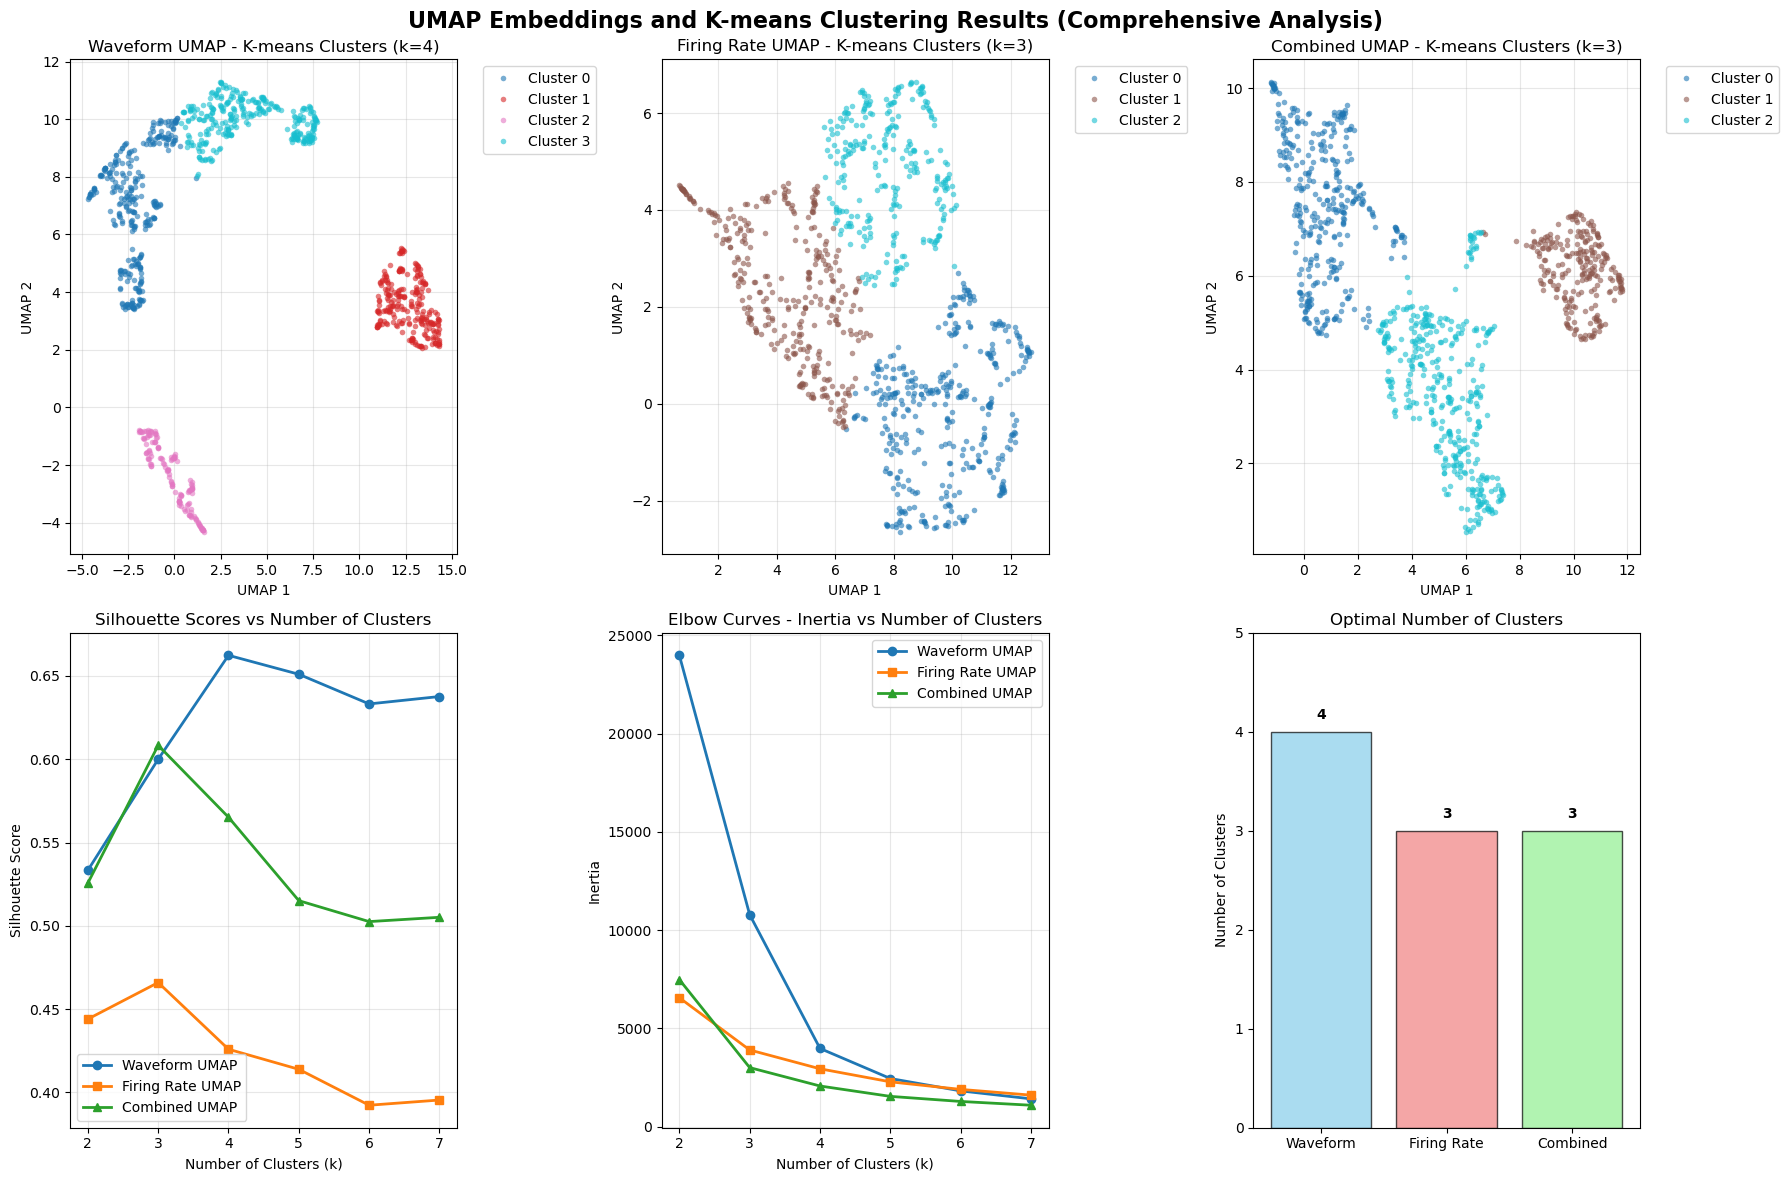


=== DETAILED CLUSTER ANALYSIS ===

Waveform UMAP Cluster Analysis:
  Cluster 0 (n=306):
    Waveform Metrics:
      Spike Width: 0.341 ± 0.123 ms
      Spike Amplitude: -63.866 ± 41.887
      Spike Asymmetry: 0.334 ± 0.160
      Rise Time: 0.180 ± 0.064 ms
      Decay Time: 0.984 ± 0.363 ms
    Firing Rate Metrics:
      Firing Rate: 3.86 ± 5.13 Hz
      Burst Index: 0.194 ± 0.134
      ISI CV: 2.812 ± 1.990
      ISI Violation Rate: 0.004 ± 0.005
      Spike Frequency Adaptation: -0.108 ± 0.662
  Cluster 1 (n=248):
    Waveform Metrics:
      Spike Width: 0.407 ± 0.145 ms
      Spike Amplitude: 57.873 ± 37.752
      Spike Asymmetry: 3.213 ± 1.259
      Rise Time: 0.292 ± 0.143 ms
      Decay Time: 0.198 ± 0.081 ms
    Firing Rate Metrics:
      Firing Rate: 6.04 ± 7.08 Hz
      Burst Index: 0.163 ± 0.142
      ISI CV: 2.938 ± 2.544
      ISI Violation Rate: 0.004 ± 0.004
      Spike Frequency Adaptation: -0.173 ± 0.669
  Cluster 2 (n=141):
    Waveform Metrics:
      Spike Width: 0.1

In [6]:
# COMPREHENSIVE CLUSTERING ANALYSIS
print("\n=== COMPREHENSIVE CLUSTERING ANALYSIS ===")

# Method 1: UMAP + K-means Clustering
print("\n--- METHOD 1: UMAP + K-means Clustering ---")

def find_optimal_k_comprehensive(data, k_range, method_name):
    """Find optimal number of clusters using silhouette score"""
    silhouette_scores = []
    inertias = []
    
    print(f"Testing optimal k for {method_name}:")
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(data)
        
        silhouette_avg = silhouette_score(data, labels)
        inertia = kmeans.inertia_
        
        silhouette_scores.append(silhouette_avg)
        inertias.append(inertia)
        
        print(f"k={k}: Silhouette Score = {silhouette_avg:.3f}, Inertia = {inertia:.1f}")
    
    optimal_k = k_range[np.argmax(silhouette_scores)]
    print(f"Optimal number of clusters: {optimal_k}")
    
    return optimal_k, silhouette_scores, inertias

# Test different k values
k_range = range(2, 8)

# Find optimal k for each UMAP embedding
optimal_k_waveform_comp, silhouette_scores_waveform_comp, inertias_waveform_comp = find_optimal_k_comprehensive(
    waveform_comprehensive_umap, k_range, "comprehensive waveform UMAP"
)

optimal_k_firing_rate_comp, silhouette_scores_firing_rate_comp, inertias_firing_rate_comp = find_optimal_k_comprehensive(
    firing_rate_comprehensive_umap, k_range, "comprehensive firing rate UMAP"
)

optimal_k_combined_comp, silhouette_scores_combined_comp, inertias_combined_comp = find_optimal_k_comprehensive(
    combined_comprehensive_umap, k_range, "comprehensive combined UMAP"
)

# Perform final clustering with optimal k values
print("\nPerforming final UMAP + K-means clustering...")

# Waveform clustering
kmeans_waveform_comp_final = KMeans(n_clusters=optimal_k_waveform_comp, random_state=42, n_init=10)
waveform_comp_labels = kmeans_waveform_comp_final.fit_predict(waveform_comprehensive_umap)
print(f"Comprehensive waveform clustering completed with {optimal_k_waveform_comp} clusters")

# Firing rate clustering
kmeans_firing_rate_comp_final = KMeans(n_clusters=optimal_k_firing_rate_comp, random_state=42, n_init=10)
firing_rate_comp_labels = kmeans_firing_rate_comp_final.fit_predict(firing_rate_comprehensive_umap)
print(f"Comprehensive firing rate clustering completed with {optimal_k_firing_rate_comp} clusters")

# Combined clustering
kmeans_combined_comp_final = KMeans(n_clusters=optimal_k_combined_comp, random_state=42, n_init=10)
combined_comp_labels = kmeans_combined_comp_final.fit_predict(combined_comprehensive_umap)
print(f"Comprehensive combined clustering completed with {optimal_k_combined_comp} clusters")

print("UMAP + K-means clustering complete!")



# VISUALIZE UMAP CLUSTERS FOR ALL METHODS WITH COLOR KEYS
print("\n=== UMAP CLUSTER VISUALIZATIONS ===")
plt.rcParams['svg.fonttype'] = 'none'  # Ensures text is editable in Illustrator

# Create figure with subplots for all UMAP embeddings and clustering results
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('UMAP Embeddings and K-means Clustering Results (Comprehensive Analysis)', fontsize=16, fontweight='bold')

# Plot 1: Waveform UMAP with clustering
ax1 = axes[0, 0]
# Use plot instead of scatter for cleaner dots without outlines
for cluster_id in range(optimal_k_waveform_comp):
    mask = waveform_comp_labels == cluster_id
    ax1.plot(waveform_comprehensive_umap[mask, 0], waveform_comprehensive_umap[mask, 1], 
             'o', alpha=0.6, markersize=4, markeredgewidth=0, markeredgecolor='none',
             color=plt.cm.tab10(cluster_id / max(1, optimal_k_waveform_comp - 1)),
             label=f'Cluster {cluster_id}')
ax1.set_title(f'Waveform UMAP - K-means Clusters (k={optimal_k_waveform_comp})')
ax1.set_xlabel('UMAP 1')
ax1.set_ylabel('UMAP 2')
ax1.grid(True, alpha=0.3)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 2: Firing Rate UMAP with clustering
ax2 = axes[0, 1]
for cluster_id in range(optimal_k_firing_rate_comp):
    mask = firing_rate_comp_labels == cluster_id
    ax2.plot(firing_rate_comprehensive_umap[mask, 0], firing_rate_comprehensive_umap[mask, 1], 
             'o', alpha=0.6, markersize=4, markeredgewidth=0, markeredgecolor='none',
             color=plt.cm.tab10(cluster_id / max(1, optimal_k_firing_rate_comp - 1)),
             label=f'Cluster {cluster_id}')
ax2.set_title(f'Firing Rate UMAP - K-means Clusters (k={optimal_k_firing_rate_comp})')
ax2.set_xlabel('UMAP 1')
ax2.set_ylabel('UMAP 2')
ax2.grid(True, alpha=0.3)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 3: Combined UMAP with clustering
ax3 = axes[0, 2]
for cluster_id in range(optimal_k_combined_comp):
    mask = combined_comp_labels == cluster_id
    ax3.plot(combined_comprehensive_umap[mask, 0], combined_comprehensive_umap[mask, 1], 
             'o', alpha=0.6, markersize=4, markeredgewidth=0, markeredgecolor='none',
             color=plt.cm.tab10(cluster_id / max(1, optimal_k_combined_comp - 1)),
             label=f'Cluster {cluster_id}')
ax3.set_title(f'Combined UMAP - K-means Clusters (k={optimal_k_combined_comp})')
ax3.set_xlabel('UMAP 1')
ax3.set_ylabel('UMAP 2')
ax3.grid(True, alpha=0.3)
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 4: Silhouette scores comparison
ax4 = axes[1, 0]
ax4.plot(k_range, silhouette_scores_waveform_comp, 'o-', label='Waveform UMAP', linewidth=2, markersize=6)
ax4.plot(k_range, silhouette_scores_firing_rate_comp, 's-', label='Firing Rate UMAP', linewidth=2, markersize=6)
ax4.plot(k_range, silhouette_scores_combined_comp, '^-', label='Combined UMAP', linewidth=2, markersize=6)
ax4.set_title('Silhouette Scores vs Number of Clusters')
ax4.set_xlabel('Number of Clusters (k)')
ax4.set_ylabel('Silhouette Score')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Plot 5: Elbow curves comparison
ax5 = axes[1, 1]
ax5.plot(k_range, inertias_waveform_comp, 'o-', label='Waveform UMAP', linewidth=2, markersize=6)
ax5.plot(k_range, inertias_firing_rate_comp, 's-', label='Firing Rate UMAP', linewidth=2, markersize=6)
ax5.plot(k_range, inertias_combined_comp, '^-', label='Combined UMAP', linewidth=2, markersize=6)
ax5.set_title('Elbow Curves - Inertia vs Number of Clusters')
ax5.set_xlabel('Number of Clusters (k)')
ax5.set_ylabel('Inertia')
ax5.legend()
ax5.grid(True, alpha=0.3)

# Plot 6: Cluster size comparison
ax6 = axes[1, 2]
cluster_counts = [optimal_k_waveform_comp, optimal_k_firing_rate_comp, optimal_k_combined_comp]
methods = ['Waveform', 'Firing Rate', 'Combined']
colors = ['skyblue', 'lightcoral', 'lightgreen']

bars = ax6.bar(methods, cluster_counts, color=colors, alpha=0.7, edgecolor='black')
ax6.set_title('Optimal Number of Clusters')
ax6.set_ylabel('Number of Clusters')
ax6.set_ylim(0, max(cluster_counts) + 1)

# Add value labels on bars
for bar, count in zip(bars, cluster_counts):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             str(count), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig("cluster_results.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# Additional detailed cluster analysis
print("\n=== DETAILED CLUSTER ANALYSIS ===")

def analyze_cluster_characteristics_comprehensive(labels, data_name, n_clusters, waveform_data, firing_rate_data):
    """Analyze characteristics of each cluster"""
    print(f"\n{data_name} Cluster Analysis:")
    
    for cluster_id in range(n_clusters):
        cluster_mask = labels == cluster_id
        cluster_size = np.sum(cluster_mask)
        
        if cluster_size > 0:
            # Analyze waveform characteristics for this cluster
            cluster_waveform_metrics = comprehensive_waveform_array[cluster_mask]
            cluster_firing_rate_metrics = comprehensive_firing_rate_array[cluster_mask]
            
            print(f"  Cluster {cluster_id} (n={cluster_size}):")
            
            # Waveform characteristics
            print(f"    Waveform Metrics:")
            print(f"      Spike Width: {np.mean(cluster_waveform_metrics[:, 0]):.3f} ± {np.std(cluster_waveform_metrics[:, 0]):.3f} ms")
            print(f"      Spike Amplitude: {np.mean(cluster_waveform_metrics[:, 1]):.3f} ± {np.std(cluster_waveform_metrics[:, 1]):.3f}")
            print(f"      Spike Asymmetry: {np.mean(cluster_waveform_metrics[:, 2]):.3f} ± {np.std(cluster_waveform_metrics[:, 2]):.3f}")
            print(f"      Rise Time: {np.mean(cluster_waveform_metrics[:, 3]):.3f} ± {np.std(cluster_waveform_metrics[:, 3]):.3f} ms")
            print(f"      Decay Time: {np.mean(cluster_waveform_metrics[:, 4]):.3f} ± {np.std(cluster_waveform_metrics[:, 4]):.3f} ms")
            
            # Firing rate characteristics
            print(f"    Firing Rate Metrics:")
            print(f"      Firing Rate: {np.mean(cluster_firing_rate_metrics[:, 0]):.2f} ± {np.std(cluster_firing_rate_metrics[:, 0]):.2f} Hz")
            print(f"      Burst Index: {np.mean(cluster_firing_rate_metrics[:, 1]):.3f} ± {np.std(cluster_firing_rate_metrics[:, 1]):.3f}")
            print(f"      ISI CV: {np.mean(cluster_firing_rate_metrics[:, 2]):.3f} ± {np.std(cluster_firing_rate_metrics[:, 2]):.3f}")
            print(f"      ISI Violation Rate: {np.mean(cluster_firing_rate_metrics[:, 3]):.3f} ± {np.std(cluster_firing_rate_metrics[:, 3]):.3f}")
            print(f"      Spike Frequency Adaptation: {np.mean(cluster_firing_rate_metrics[:, 4]):.3f} ± {np.std(cluster_firing_rate_metrics[:, 4]):.3f}")

# Analyze each clustering method
analyze_cluster_characteristics_comprehensive(waveform_comp_labels, "Waveform UMAP", optimal_k_waveform_comp, 
                                            comprehensive_waveform_array, comprehensive_firing_rate_array)
analyze_cluster_characteristics_comprehensive(firing_rate_comp_labels, "Firing Rate UMAP", optimal_k_firing_rate_comp, 
                                            comprehensive_waveform_array, comprehensive_firing_rate_array)
analyze_cluster_characteristics_comprehensive(combined_comp_labels, "Combined UMAP", optimal_k_combined_comp, 
                                            comprehensive_waveform_array, comprehensive_firing_rate_array)

print("\nUMAP cluster visualizations complete!")


=== COMPREHENSIVE VISUALIZATION FUNCTIONS ===
Comprehensive visualization functions defined!

=== COMPREHENSIVE VISUALIZATIONS: UMAP + K-MEANS ===

--- Combined UMAP + K-means Clustering ---


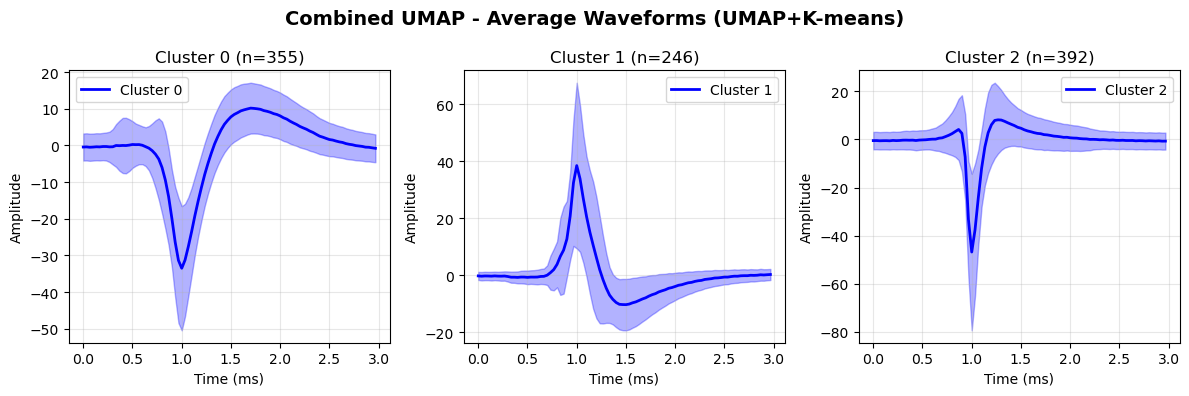

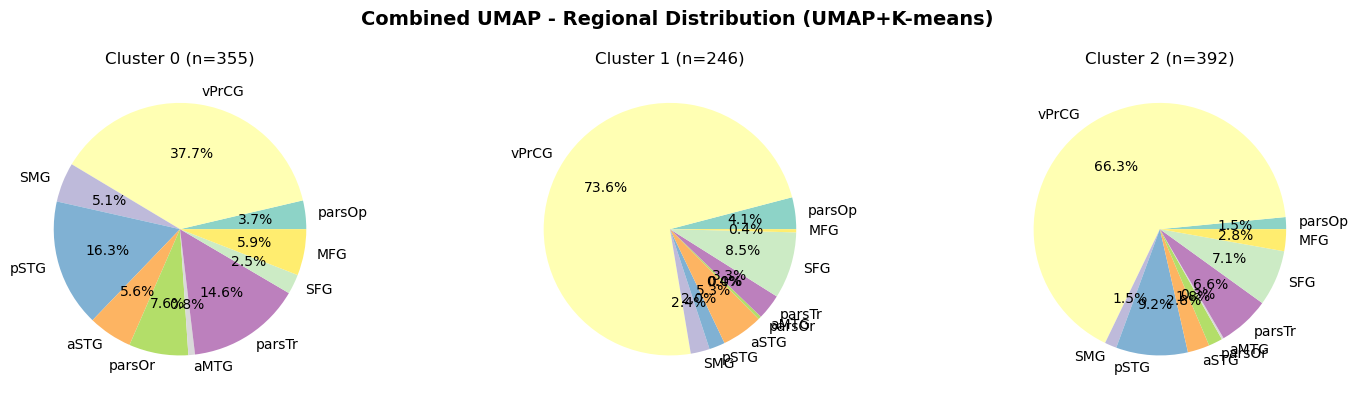

In [7]:
# Visualizaiton cell



#  1. DEFINE COMPREHENSIVE VISUALIZATION FUNCTIONS
print("\n=== COMPREHENSIVE VISUALIZATION FUNCTIONS ===")
plt.rcParams['svg.fonttype'] = 'none'  # Ensures text is editable in Illustrator

def plot_cluster_waveforms_comprehensive(labels, waveforms_array, title_prefix, n_clusters, method_name):
    """Plot average waveforms for each cluster"""
    fig, axes = plt.subplots(1, n_clusters, figsize=(4*n_clusters, 4))
    if n_clusters == 1:
        axes = [axes]
    
    fig.suptitle(f'{title_prefix} - Average Waveforms ({method_name})', fontsize=14, fontweight='bold')
    
    for cluster_id in range(n_clusters):
        cluster_mask = labels == cluster_id
        cluster_waveforms = waveforms_array[cluster_mask]
        
        if len(cluster_waveforms) > 0:
            # Calculate average waveform
            avg_waveform = np.mean(cluster_waveforms, axis=0)
            std_waveform = np.std(cluster_waveforms, axis=0)
            
            # Plot average waveform with error bars
            x_vals = np.arange(len(avg_waveform)) / 30.0  # Convert to ms
            axes[cluster_id].plot(x_vals, avg_waveform, 'b-', linewidth=2, label=f'Cluster {cluster_id}')
            axes[cluster_id].fill_between(x_vals, 
                                        avg_waveform - std_waveform, 
                                        avg_waveform + std_waveform, 
                                        alpha=0.3, color='blue')
            
            axes[cluster_id].set_title(f'Cluster {cluster_id} (n={len(cluster_waveforms)})')
            axes[cluster_id].set_xlabel('Time (ms)')
            axes[cluster_id].set_ylabel('Amplitude')
            axes[cluster_id].grid(True, alpha=0.3)
            axes[cluster_id].legend()
    
    plt.tight_layout()
    plt.savefig("cluster_waveforms.svg", format="svg", dpi=300, bbox_inches='tight')
    plt.show()

def plot_region_pie_charts(labels, metadata, title_prefix, n_clusters, method_name):
    """Plot pie charts showing regional distribution for each cluster"""
    fig, axes = plt.subplots(1, n_clusters, figsize=(5*n_clusters, 4))
    if n_clusters == 1:
        axes = [axes]
    
    fig.suptitle(f'{title_prefix} - Regional Distribution ({method_name})', fontsize=14, fontweight='bold')
    
    # Get unique regions
    all_regions = [meta['region'] for meta in metadata]
    unique_regions = list(set(all_regions))
    
    for cluster_id in range(n_clusters):
        cluster_mask = labels == cluster_id
        cluster_metadata = [metadata[i] for i in range(len(metadata)) if cluster_mask[i]]
        
        if len(cluster_metadata) > 0:
            # Count regions in this cluster
            cluster_regions = [meta['region'] for meta in cluster_metadata]
            region_counts = {region: cluster_regions.count(region) for region in unique_regions}
            
            # Create pie chart
            labels_pie = list(region_counts.keys())
            sizes = list(region_counts.values())
            colors = plt.cm.Set3(np.linspace(0, 1, len(labels_pie)))
            
            axes[cluster_id].pie(sizes, labels=labels_pie, autopct='%1.1f%%', colors=colors)
            axes[cluster_id].set_title(f'Cluster {cluster_id} (n={len(cluster_metadata)})')
    
    plt.tight_layout()
    plt.savefig("cluster_region.svg", format="svg", dpi=300, bbox_inches='tight')
    plt.show()

print("Comprehensive visualization functions defined!")



# 2. COMPREHENSIVE VISUALIZATIONS FOR UMAP + K-MEANS CLUSTERING
print("\n=== COMPREHENSIVE VISUALIZATIONS: UMAP + K-MEANS ===")
plt.rcParams['svg.fonttype'] = 'none'  # Ensures text is editable in Illustrator

# Convert waveforms_flat to numpy array for visualization
waveforms_array_for_viz = np.array(waveforms_flat)

# Combined UMAP + K-means visualizations
print("\n--- Combined UMAP + K-means Clustering ---")
plot_cluster_waveforms_comprehensive(combined_comp_labels, waveforms_array_for_viz, 
                                    "Combined UMAP", optimal_k_combined_comp, "UMAP+K-means")
plot_region_pie_charts(combined_comp_labels, comprehensive_metadata, 
                      "Combined UMAP", optimal_k_combined_comp, "UMAP+K-means")
#plot_depth_histograms(combined_comp_labels, comprehensive_metadata, 
#                     "Combined UMAP", optimal_k_combined_comp, "UMAP+K-means")
#plot_subgroup_bar_charts(combined_comp_labels, comprehensive_metadata, 
#                        "Combined UMAP", optimal_k_combined_comp, "UMAP+K-means")



=== ET-DENSE vs ET-SPARSE REGIONAL ANALYSIS ===
ET-dense regions: ['vPrCG', 'PoCG']
ET-sparse regions: ['pSTG', 'SFG', 'aSTG', 'aMTG', 'MFG', 'parsOp', 'parsTr', 'parsOr', 'SMG']
ET-dense neurons: 575
ET-sparse neurons: 418

=== ET-DENSE REGIONS VISUALIZATION ===
Analyzing 575 neurons from ET-dense regions (vPrCG, PoCG)

--- ET-Dense: Waveform Analysis ---


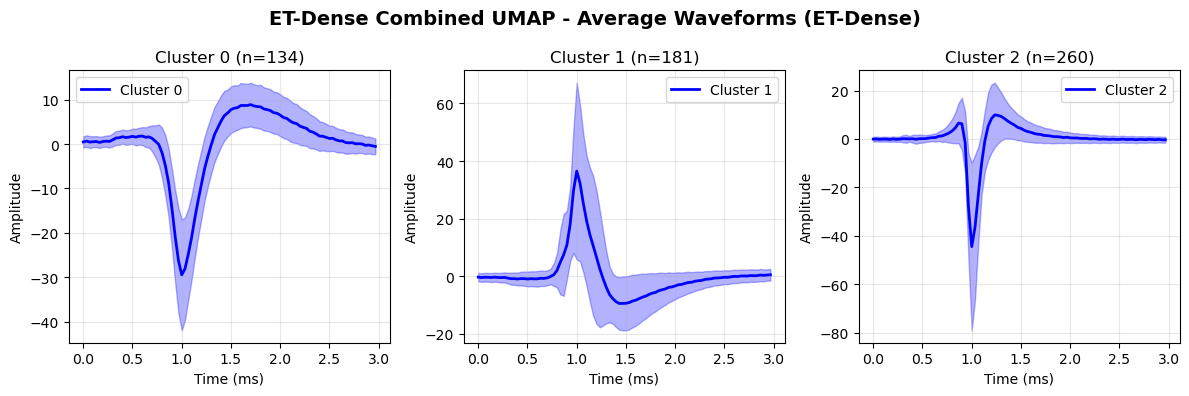


--- ET-Dense: Region Distribution ---


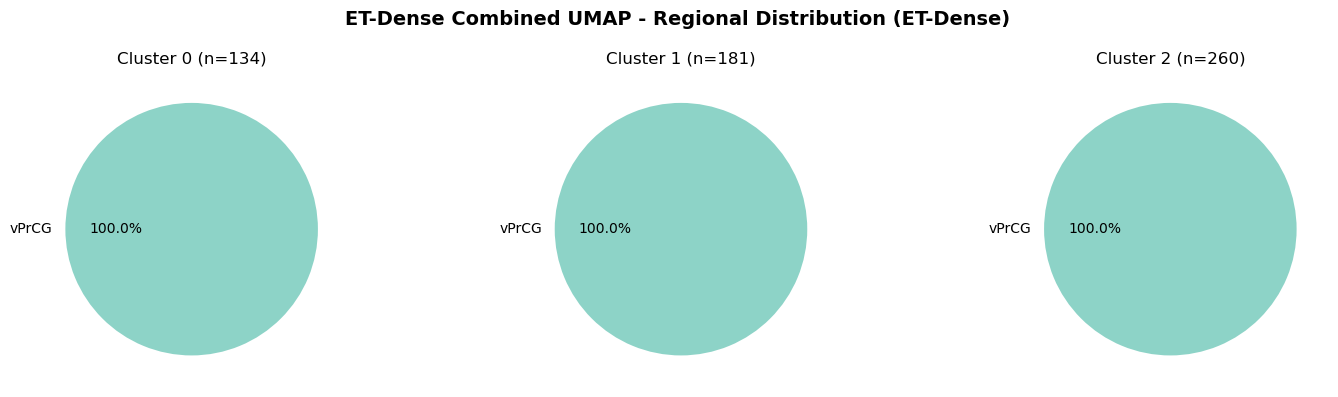


=== ET-SPARSE REGIONS VISUALIZATION ===
Analyzing 418 neurons from ET-sparse regions (all others)

--- ET-Sparse: Waveform Analysis ---


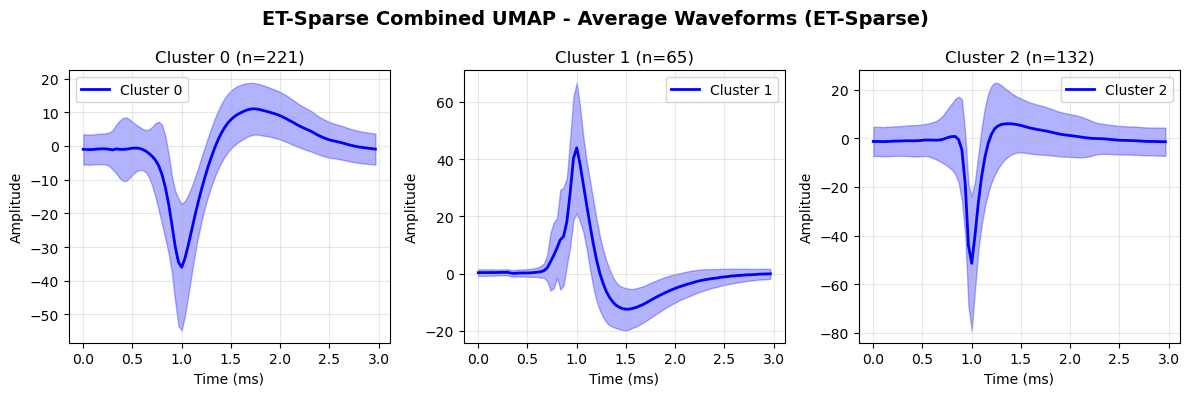


--- ET-Sparse: Region Distribution ---


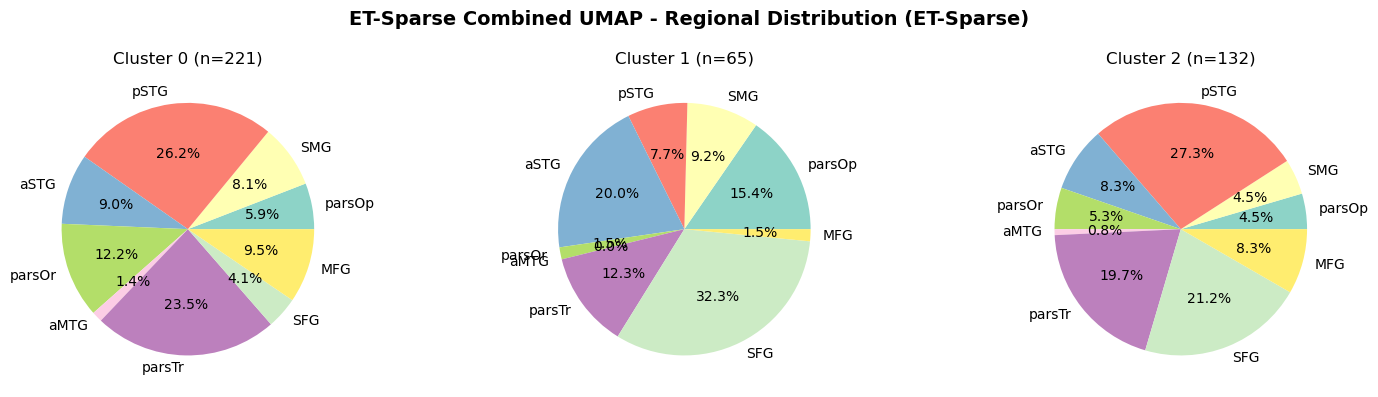

In [8]:
# ET sparse specific visualizations
print("\n=== ET-DENSE vs ET-SPARSE REGIONAL ANALYSIS ===")



# 0. Define ET-dense and ET-sparse regions
et_dense_regions = ['vPrCG', 'PoCG']  # Motor and somatosensory cortex
et_sparse_regions = ['pSTG', 'SFG', 'aSTG', 'aMTG', 'MFG', 'parsOp', 'parsTr', 'parsOr', 'SMG']

print(f"ET-dense regions: {et_dense_regions}")
print(f"ET-sparse regions: {et_sparse_regions}")

# Create masks for ET-dense and ET-sparse regions
et_dense_mask = np.array([neuron['region'] in et_dense_regions for neuron in comprehensive_metadata])
et_sparse_mask = np.array([neuron['region'] in et_sparse_regions for neuron in comprehensive_metadata])

print(f"ET-dense neurons: {np.sum(et_dense_mask)}")
print(f"ET-sparse neurons: {np.sum(et_sparse_mask)}")

# Separate the combined clustering data
et_dense_labels = combined_comp_labels[et_dense_mask]
et_sparse_labels = combined_comp_labels[et_sparse_mask]

et_dense_metadata = [comprehensive_metadata[i] for i in range(len(comprehensive_metadata)) if et_dense_mask[i]]
et_sparse_metadata = [comprehensive_metadata[i] for i in range(len(comprehensive_metadata)) if et_sparse_mask[i]]

et_dense_waveforms = waveforms_array_for_viz[et_dense_mask]
et_sparse_waveforms = waveforms_array_for_viz[et_sparse_mask]



# 1. ET-DENSE REGIONS VISUALIZATION
print("\n=== ET-DENSE REGIONS VISUALIZATION ===")
print(f"Analyzing {len(et_dense_labels)} neurons from ET-dense regions (vPrCG, PoCG)")

# 1. Waveform visualizations for ET-dense
print("\n--- ET-Dense: Waveform Analysis ---")
plot_cluster_waveforms_comprehensive(et_dense_labels, et_dense_waveforms, 
                                    "ET-Dense Combined UMAP", optimal_k_combined_comp, "ET-Dense")

# 2. Region pie charts for ET-dense
print("\n--- ET-Dense: Region Distribution ---")
plot_region_pie_charts(et_dense_labels, et_dense_metadata, 
                      "ET-Dense Combined UMAP", optimal_k_combined_comp, "ET-Dense")



# 2. ET-SPARSE REGIONS VISUALIZATION
print("\n=== ET-SPARSE REGIONS VISUALIZATION ===")
print(f"Analyzing {len(et_sparse_labels)} neurons from ET-sparse regions (all others)")

# 1. Waveform visualizations for ET-sparse
print("\n--- ET-Sparse: Waveform Analysis ---")
plot_cluster_waveforms_comprehensive(et_sparse_labels, et_sparse_waveforms, 
                                    "ET-Sparse Combined UMAP", optimal_k_combined_comp, "ET-Sparse")

# 2. Region pie charts for ET-sparse
print("\n--- ET-Sparse: Region Distribution ---")
plot_region_pie_charts(et_sparse_labels, et_sparse_metadata, 
                      "ET-Sparse Combined UMAP", optimal_k_combined_comp, "ET-Sparse")

PER-ASSEMBLY LOGISTIC REGRESSION ANALYSIS (LR ONLY) - BOOTSTRAP
pSTG regions with sens events (Sens vs Baseline)
Using yield_independent_capacity from pickle file
Running 1000 iterations with different baseline samples

Loading yield_independent_capacity data...
Loaded from pickle: 154 entries

Found 5 pSTG insertions with sens events

Pre-computing assemblies and extracting sens expression values...
  Behavioral duration 35.17 min (>= 0 min) — using TaskTimes restrict; KS window [0.000, 2602.000] s
  Behavioral duration 10.82 min (>= 0 min) — using TaskTimes restrict; KS window [232.000, 881.000] s
  Behavioral duration 16.63 min (>= 0 min) — using TaskTimes restrict; KS window [244.000, 1451.000] s
  Behavioral duration 13.40 min (>= 0 min) — using TaskTimes restrict; KS window [24.000, 983.000] s
  Behavioral duration 17.53 min (>= 0 min) — using TaskTimes restrict; KS window [410.000, 1522.000] s
Pre-computed data for 17 assemblies

Running 1000 bootstrap iterations...
Iteration 1/

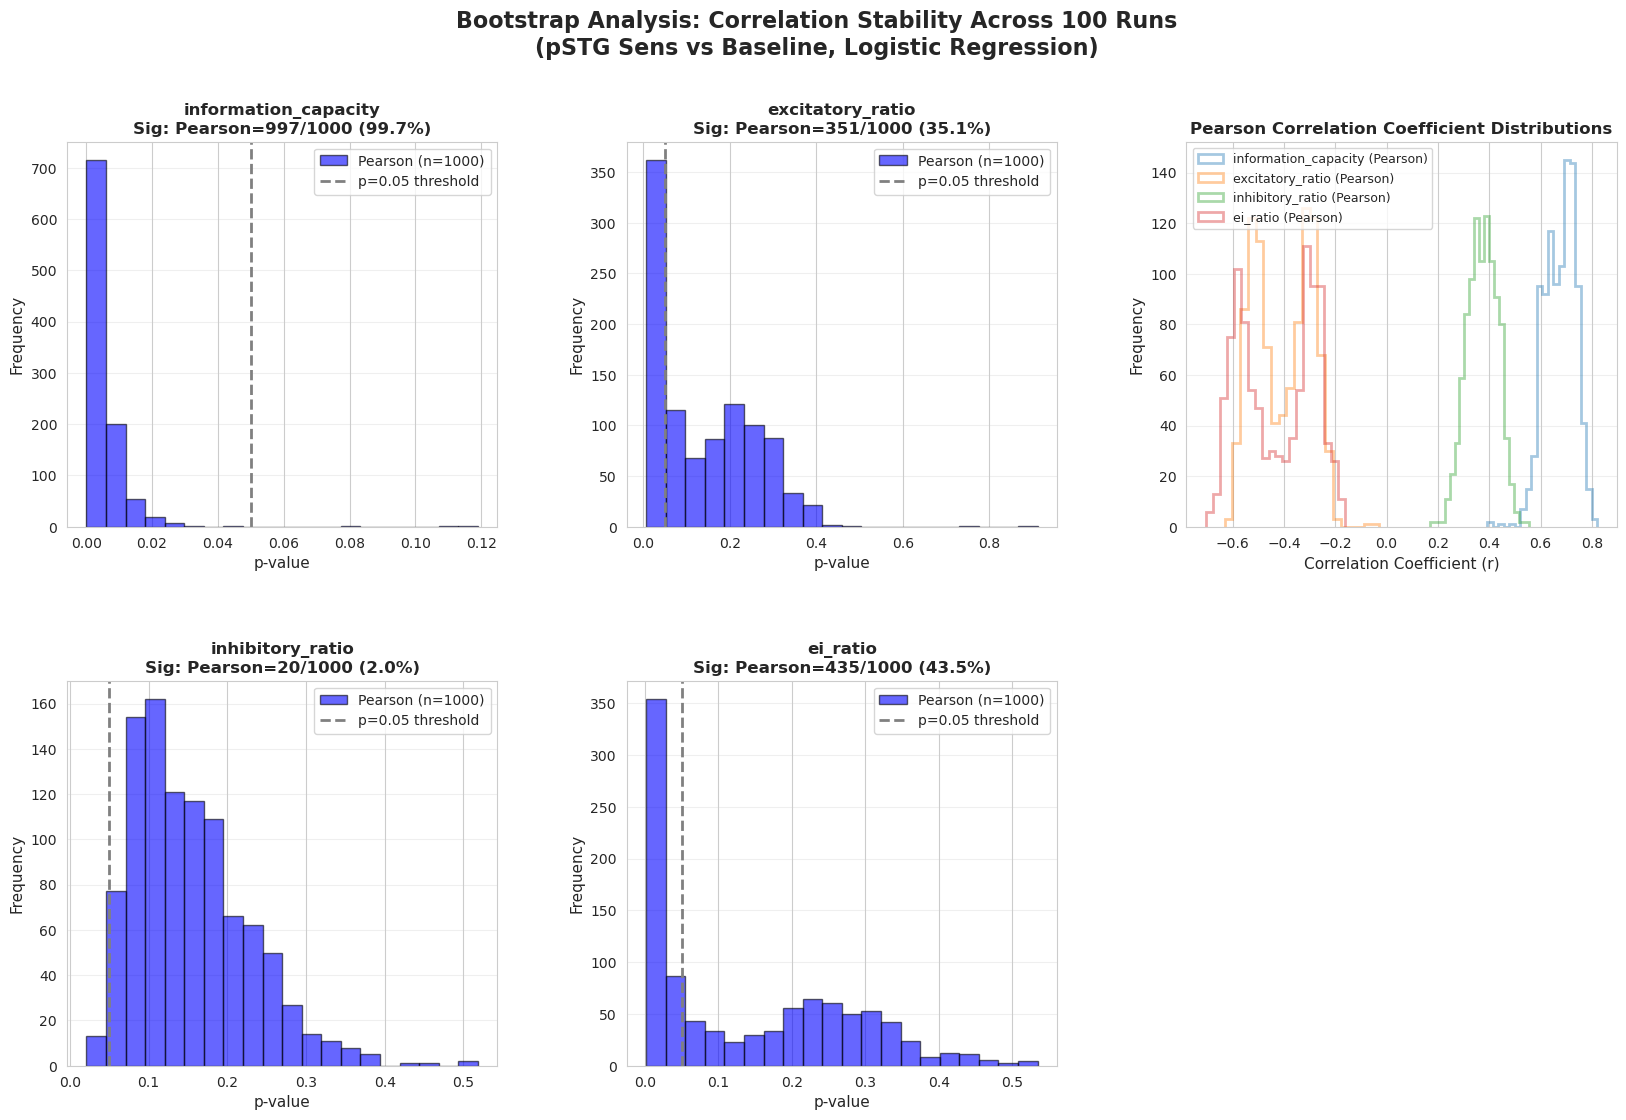


Created visualization showing p-value distributions and correlation stability

ANALYSIS COMPLETE


In [9]:
# PER-ASSEMBLY LOGISTIC REGRESSION ANALYSIS (LR ONLY) - BOOTSTRAP VERSION
# pSTG regions with sens events
# Compares sens periods vs non-language periods (baseline)
# Uses Logistic Regression classifier only
# Uses yield_independent_capacity from pickle file
# Runs 1000 times with different baseline samples to assess stability

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import ttest_ind, mannwhitneyu, kstest, spearmanr, pearsonr
from scipy.linalg import norm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.decomposition import FastICA
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import fnmatch
import pickle
import os
warnings.filterwarnings('ignore')

plt.rcParams['svg.fonttype'] = 'none'
sns.set_style("whitegrid")

print("=" * 80)
print("PER-ASSEMBLY LOGISTIC REGRESSION ANALYSIS (LR ONLY) - BOOTSTRAP")
print("pSTG regions with sens events (Sens vs Baseline)")
print("Using yield_independent_capacity from pickle file")
print("Running 1000 iterations with different baseline samples")
print("=" * 80)

# Load yield_independent_capacity from pickle or CSV
print("\nLoading yield_independent_capacity data...")
capacity_map = {}

try:
    pkl_path = 'yield_independent_assembly_capacity.pkl'
    if os.path.exists(pkl_path):
        with open(pkl_path, 'rb') as f:
            capacity_data = pickle.load(f)
        
        if isinstance(capacity_data, pd.DataFrame):
            for idx, row in capacity_data.iterrows():
                insertion_idx = int(row['insertion_idx'])
                assembly_number = int(row['assembly_number'])
                capacity = float(row['yield_independent_capacity'])
                capacity_map[(insertion_idx, assembly_number)] = capacity
        elif isinstance(capacity_data, dict):
            if len(capacity_data) > 0:
                first_key = list(capacity_data.keys())[0]
                if isinstance(first_key, tuple) and len(first_key) == 2:
                    capacity_map = capacity_data
                else:
                    for key, value in capacity_data.items():
                        if isinstance(value, dict) and 'yield_independent_capacity' in value:
                            capacity_map[key] = value['yield_independent_capacity']
        print(f"Loaded from pickle: {len(capacity_map)} entries")
    else:
        raise FileNotFoundError("Pickle file not found")
except Exception as e:
    print(f"Error loading pickle: {e}")
    try:
        csv_path = 'yield_independent_assembly_capacity.csv'
        capacity_df = pd.read_csv(csv_path)
        for idx, row in capacity_df.iterrows():
            insertion_idx = int(row['insertion_idx'])
            assembly_number = int(row['assembly_number'])
            capacity = float(row['yield_independent_capacity'])
            capacity_map[(insertion_idx, assembly_number)] = capacity
        print(f"Loaded from CSV: {len(capacity_map)} entries")
    except Exception as e2:
        print(f"ERROR: Could not load capacity data: {e2}")
        capacity_map = {}

def calculate_expression_strength(firingRateMatrix, ap_norm_matrix):
    """Calculate expression strength"""
    n_time_bins, n_neurons = firingRateMatrix.shape
    n_assemblies = ap_norm_matrix.shape[0]
    expression_strength = np.zeros((n_time_bins, n_assemblies))
    
    for assembly_idx in range(n_assemblies):
        weight_vector = ap_norm_matrix[assembly_idx, :]
        outer_product = np.outer(weight_vector, weight_vector)
        for time_bin in range(n_time_bins):
            firing_rate_vector = firingRateMatrix[time_bin, :]
            expression_strength[time_bin, assembly_idx] = firing_rate_vector.T @ outer_product @ firing_rate_vector
    
    return expression_strength

MIN_BEHAVIOR_MINUTES = 0

def _behavior_duration_seconds(task_times_obj):
    starts = np.asarray(task_times_obj.start, dtype=float).ravel()
    ends = np.asarray(task_times_obj.end, dtype=float).ravel()
    if starts.size != ends.size:
        return np.nan
    return float(np.sum(ends - starts))

def _ks_time_bounds_full_recording(spike_times_obj):
    """Min/max time for uniform KS (full recording)."""
    tmin, tmax = np.inf, -np.inf
    for u in range(len(spike_times_obj)):
        idx = spike_times_obj[u].as_series().index.values
        if len(idx):
            tmin = min(tmin, float(np.min(idx)))
            tmax = max(tmax, float(np.max(idx)))
    if np.isfinite(tmin) and np.isfinite(tmax):
        return tmin, tmax
    return np.nan, np.nan

def imec_key_sorter(key):
    """Extract the number after 'imec'"""
    match = re.search(r'imec(\d+)', key)
    return int(match.group(1)) if match else float('inf')

def map_to_pickle_insertion_idx(insertion_counter):
    """Map insertion_counter to pickle insertion_idx"""
    if insertion_counter >= 13:
        return insertion_counter + 2
    else:
        return insertion_counter

def find_valid_baseline_windows(task_start, task_end, all_language_starts, all_language_ends, 
                                buffer, baseline_duration, bin_starts, bin_ends):
    """
    Pre-compute all valid baseline windows that don't overlap with language events.
    Returns list of (start, end) tuples for valid baseline periods.
    """
    valid_windows = []
    
    # Create a fine grid of potential start times
    step_size = 0.01  # 10ms steps
    potential_starts = np.arange(task_start, task_end - baseline_duration + step_size, step_size)
    
    for start_candidate in potential_starts:
        end_candidate = start_candidate + baseline_duration
        
        # Check if this window overlaps with any language event
        overlaps = False
        for lang_start, lang_end in zip(all_language_starts, all_language_ends):
            if not (end_candidate < lang_start - buffer or start_candidate > lang_end + buffer):
                overlaps = True
                break
        
        if not overlaps:
            # Check if we have bins that cover this window
            mask = (bin_starts >= start_candidate) & (bin_ends <= end_candidate)
            if np.any(mask):
                valid_windows.append((start_candidate, end_candidate))
    
    return valid_windows

# Get pSTG insertions with sens events
pstg_insertions = []
insertion_counter = 0

for i in range(len(nwb_paths)):
    data = nap.load_file(nwb_paths[i])
    keys = data.keys()
    template = "*imec*"
    keys = [key for key in keys if fnmatch.fnmatch(key, template)]
    ks_keys = [key for key in keys if "KS4" in key]
    if ks_keys:
        keys = ks_keys
    th8_keys = [key for key in keys if "Th=8" in key]
    if th8_keys:
        keys = th8_keys
    else:
        th_keys = [key for key in keys if "Th=" in key]
        if th_keys:
            keys = th_keys
    template_sentgen = "*sentgen*"
    template_auto = "*_auto*"
    keys = [key for key in keys if not fnmatch.fnmatch(key, template_sentgen) and not fnmatch.fnmatch(key, template_auto)]
    if 'NP137' in str(nwb_paths[i]) or 'NP139_B2' in str(nwb_paths[i]):
        keys = [key for key in keys if 'imec1' not in key]
    keys = sorted(keys, key=imec_key_sorter)
    
    for s in range(len(keys)):
        if insertion_counter < len(region_list):
            region = region_list[insertion_counter]
            if region == 'pSTG':
                has_sens = ("StimSpeechWords" in data) or ("mfa_stim_words" in data)
                if has_sens:
                    pstg_insertions.append({
                        'nwb_idx': i,
                        'session_idx': s,
                        'insertion_idx': insertion_counter,
                        'region': region,
                        'opercular': opercular_list[insertion_counter] if insertion_counter < len(opercular_list) else None
                    })
        insertion_counter += 1

print(f"\nFound {len(pstg_insertions)} pSTG insertions with sens events")

# PRE-COMPUTE ALL ASSEMBLIES AND DATA (ONCE, OUTSIDE BOOTSTRAP LOOP)
print("\nPre-computing assemblies and extracting sens expression values...")

assembly_data = {}  # Store pre-computed data for each assembly

for ins_info in pstg_insertions:
    nwb_idx = ins_info['nwb_idx']
    session_idx = ins_info['session_idx']
    insertion_idx = ins_info['insertion_idx']
    region = ins_info['region']
    opercular = ins_info['opercular']
    
    # Load data
    data = nap.load_file(nwb_paths[nwb_idx])
    keys = data.keys()
    template = "*imec*"
    keys = [key for key in keys if fnmatch.fnmatch(key, template)]
    ks_keys = [key for key in keys if "KS4" in key]
    if ks_keys:
        keys = ks_keys
    th8_keys = [key for key in keys if "Th=8" in key]
    if th8_keys:
        keys = th8_keys
    else:
        th_keys = [key for key in keys if "Th=" in key]
        if th_keys:
            keys = th_keys
    template_sentgen = "*sentgen*"
    template_auto = "*_auto*"
    keys = [key for key in keys if not fnmatch.fnmatch(key, template_sentgen) and not fnmatch.fnmatch(key, template_auto)]
    if 'NP137' in str(nwb_paths[nwb_idx]) or 'NP139_B2' in str(nwb_paths[nwb_idx]):
        keys = [key for key in keys if 'imec1' not in key]
    keys = sorted(keys, key=imec_key_sorter)
    
    spike_times = data[keys[session_idx]]
    
    has_prod = "ProdSpeechWords" in data
    has_sens = ("StimSpeechWords" in data) or ("mfa_stim_words" in data)
    
    if not has_sens:
        continue
    
    # Filter to good neurons
    firingRates_all = spike_times.metadata["rate"]
    if "TaskTimes" in data.keys():
        task_times = data["TaskTimes"]
    else:
        task_times = data["task_times"]

    start_time = task_times.start
    end_time = task_times.end
    beh_epochs = nap.IntervalSet(start=task_times.start, end=task_times.end)

    beh_sec = _behavior_duration_seconds(task_times)
    beh_min = beh_sec / 60.0 if np.isfinite(beh_sec) else np.nan
    use_full_recording = (not np.isfinite(beh_min)) or (beh_min < MIN_BEHAVIOR_MINUTES)

    if use_full_recording:
        spike_times_beh = spike_times
        firingRates_beh = firingRates_all
        min_time, max_time = _ks_time_bounds_full_recording(spike_times)
        if not (np.isfinite(min_time) and np.isfinite(max_time)) or (max_time <= min_time):
            print(f"  Short behavior ({beh_min:.2f} min) but could not get recording bounds; skipping shank")
            continue
        print(
            f"  Behavioral duration {beh_min:.2f} min (< {MIN_BEHAVIOR_MINUTES} min) — using full recording for filters; KS window [{min_time:.3f}, {max_time:.3f}] s"
        )
    else:
        spike_times_beh = spike_times.restrict(beh_epochs)
        firingRates_beh = spike_times_beh.metadata["rate"]
        min_time = start_time[0]
        max_time = end_time[-1]
        print(
            f"  Behavioral duration {beh_min:.2f} min (>= {MIN_BEHAVIOR_MINUTES} min) — using TaskTimes restrict; KS window [{min_time:.3f}, {max_time:.3f}] s"
        )

    ks_stats = np.zeros(len(spike_times))
    ks_pvals = np.zeros(len(spike_times))
    for u in range(len(spike_times)):
        test = spike_times[u].as_series().index.values
        if len(test) > 1:
            normalized_spike_times = (test - min_time) / (max_time - min_time)
            ks_result = kstest(normalized_spike_times, 'uniform')
            ks_stats[u] = ks_result.statistic
            ks_pvals[u] = ks_result.pvalue
        else:
            ks_stats[u] = np.nan
            ks_pvals[u] = np.nan

    violationThreshold = 3/1000
    violationPct = np.zeros(len(spike_times))
    for u in range(len(spike_times)):
        unit = spike_times[u]
        unit = unit.as_series().index
        if len(unit) < 100:
            violationPct[u] = 1
        else:
            isi = unit.diff()[1:len(unit)]
            violations = np.where(isi<violationThreshold)
            violations = np.array(violations)
            violationPct[u] = violations.size/len(isi)
    
    if "KSLabel" in spike_times.metadata:
        KSLabels = spike_times.metadata["KSLabel"]
    else:
        KSLabels = spike_times.metadata["quality"]
    firingRates = firingRates_beh
    mask1 = violationPct<3/100
    mask2 = firingRates>0.5
    mask3 = KSLabels!="noise"
    mask4 = ks_stats < 0.3
    mask = mask1 & mask2 & mask3 & mask4
    indicesFinal = firingRates.index[mask]
    
    if insertion_idx < len(manual_exclude_lists):
        indicesFinal = np.setdiff1d(indicesFinal, manual_exclude_lists[insertion_idx])
    
    spike_times_good = spike_times[indicesFinal]
    n_neurons = len(spike_times_good)
    
    if n_neurons == 0:
        continue
    
    # Make spike rate matrix
    timescale = 25/1000
    spikeCountMatrix = spike_times_good.count(bin_size=timescale)
    bin_edges = spikeCountMatrix.index.values
    bin_centers = bin_edges[:-1] + np.diff(bin_edges)/2
    if len(bin_centers) < len(bin_edges):
        last_width = bin_edges[-1] - bin_edges[-2] if len(bin_edges) > 1 else 0
        last_center = bin_edges[-1] - last_width/2
        bin_centers = np.append(bin_centers, last_center)
    spikeCountMatrix = spikeCountMatrix.values
    firingRateMatrix = spikeCountMatrix/timescale
    firingRateMatrix = stats.zscore(firingRateMatrix, axis=0)
    
    # Calculate assemblies
    pca = PCA()
    firingRateMatrix_pca = pca.fit_transform(firingRateMatrix)
    eigenvalues = pca.explained_variance_
    upperbound = (1+np.sqrt(firingRateMatrix.shape[1]/firingRateMatrix.shape[0]))**2
    assemblyIndices = np.where(eigenvalues>upperbound)
    assemblyEigenvalues = eigenvalues[assemblyIndices]
    n_pcs = len(assemblyEigenvalues)
    
    if n_pcs == 0:
        continue
    
    # Get cluster labels if available
    insertion_cluster_labels = []
    if 'et_sparse_labels' in globals() and 'et_sparse_metadata' in globals():
        matching_neurons = [(idx, neuron) for idx, neuron in enumerate(et_sparse_metadata) 
                            if neuron.get('insertion_idx') == insertion_idx]
        for local_neuron_idx in range(len(indicesFinal)):
            cluster_label = -1
            if local_neuron_idx < len(matching_neurons):
                global_idx = matching_neurons[local_neuron_idx][0]
                cluster_label = et_sparse_labels[global_idx]
            insertion_cluster_labels.append(cluster_label)
    else:
        insertion_cluster_labels = [-1] * len(indicesFinal)
    
    insertion_cluster_labels = np.array(insertion_cluster_labels)
    
    # Orthogonalize with ICA
    pc_vectors = pca.components_[:n_pcs, :]
    projections = firingRateMatrix @ pc_vectors.T
    
    fastica = FastICA(n_components=n_pcs, algorithm='parallel', whiten='unit-variance',
                     max_iter=500, tol=1e-7, random_state=1)
    ica_components = fastica.fit_transform(projections)
    unmixing_matrix = fastica.components_
    ica_assembly_patterns = unmixing_matrix @ pc_vectors
    
    # Normalize assembly patterns
    ap_norm_matrix = ica_assembly_patterns.copy()
    for ii in range(n_pcs):
        ap = ica_assembly_patterns[ii,:]
        ap_norm = ap/norm(ap)
        maxW = max(ap_norm)
        minW = min(ap_norm)
        if abs(minW) > maxW:
            ap_norm = ap_norm*-1
        ap_norm_matrix[ii,:] = ap_norm
    
    # Calculate expression strength
    expression_strength_matrix = calculate_expression_strength(firingRateMatrix, ap_norm_matrix)
    
    # Get sens trial times and task times for baseline
    sens_rel_start = 0
    sens_rel_end = 0.10
    
    if "StimSpeechWords" in data:
        speech_sens_times = data["StimSpeechWords"]
    else:
        speech_sens_times = data["mfa_stim_words"]
    
    sens_onsets = nap.Ts(speech_sens_times.start)
    sens_offsets = nap.Ts(speech_sens_times.end)
    sens_starts = sens_onsets.as_series().index + sens_rel_start
    sens_ends = sens_offsets.as_series().index + sens_rel_end
    
    # Get task times for baseline
    if "TaskTimes" in data.keys():
        task_times = data["TaskTimes"]
    else:
        task_times = data["task_times"]
    if isinstance(task_times.start, np.ndarray):
        task_start = task_times.start[0]
        task_end = task_times.end[-1]
    else:
        task_start = task_times.start.values[0]
        task_end = task_times.end.values[-1]
    
    # Get prod times if available
    prod_starts = []
    prod_ends = []
    if has_prod:
        prod_rel_start = -0.10
        prod_rel_end = 0
        speech_prod_times = data["ProdSpeechWords"]
        prod_onsets = nap.Ts(speech_prod_times.start)
        prod_offsets = nap.Ts(speech_prod_times.end)
        prod_starts = (prod_onsets.as_series().index + prod_rel_start).values
        prod_ends = (prod_offsets.as_series().index + prod_rel_end).values
    
    sens_starts = sens_starts.values
    sens_ends = sens_ends.values
    
    # Pre-compute bin boundaries
    bin_starts = bin_centers - timescale / 2
    bin_ends = bin_centers + timescale / 2
    
    # Pre-compute all valid baseline windows once per insertion
    all_language_starts = list(sens_starts)
    all_language_ends = list(sens_ends)
    if has_prod:
        all_language_starts.extend(prod_starts)
        all_language_ends.extend(prod_ends)
    
    buffer = 0.1
    baseline_duration = 0.1
    
    valid_baseline_windows = find_valid_baseline_windows(
        task_start, task_end, all_language_starts, all_language_ends,
        buffer, baseline_duration, bin_starts, bin_ends
    )
    
    # For each assembly, pre-compute everything except baseline sampling
    for asm_idx in range(n_pcs):
        assembly_expression = ica_components[:, asm_idx]
        
        # Get yield-independent capacity
        pickle_insertion_idx = map_to_pickle_insertion_idx(insertion_idx)
        
        if (pickle_insertion_idx, asm_idx) in capacity_map:
            info_capacity = capacity_map[(pickle_insertion_idx, asm_idx)]
        else:
            info_capacity = np.nan
        
        # Calculate ratios
        assembly_pattern = ap_norm_matrix[asm_idx, :]
        weights = assembly_pattern
        
        excitatory_tone = np.sum(weights[insertion_cluster_labels == 0])
        inhibitory_tone = np.sum(weights[insertion_cluster_labels == 2])
        
        total_tone = np.sum(abs(weights))
        excitatory_ratio = np.abs(excitatory_tone) / (total_tone + 1e-10)
        inhibitory_ratio = np.abs(inhibitory_tone) / (total_tone + 1e-10)
        ei_ratio = excitatory_ratio / (inhibitory_ratio + 1e-10)
        
        # Extract sens expression values (same for all bootstrap iterations)
        sens_expression_values = []
        
        for u in range(len(sens_starts)):
            interval_start = sens_starts[u]
            interval_end = sens_ends[u]
            mask = (bin_starts >= interval_start) & (bin_ends <= interval_end)
            if np.any(mask):
                trial_expression = np.mean(assembly_expression[mask])
                sens_expression_values.append(trial_expression)
        
        # Store pre-computed data for this assembly
        assembly_id = (insertion_idx, asm_idx)
        assembly_data[assembly_id] = {
            'insertion_idx': insertion_idx,
            'assembly_idx': asm_idx,
            'region': region,
            'opercular': opercular,
            'assembly_expression': assembly_expression,
            'sens_expression_values': sens_expression_values,
            'valid_baseline_windows': valid_baseline_windows,
            'bin_starts': bin_starts,
            'bin_ends': bin_ends,
            'info_capacity': info_capacity,
            'excitatory_ratio': excitatory_ratio,
            'inhibitory_ratio': inhibitory_ratio,
            'ei_ratio': ei_ratio,
            'n_neurons': n_neurons
        }

print(f"Pre-computed data for {len(assembly_data)} assemblies")

# Number of bootstrap iterations
n_bootstrap = 1000

# Storage for bootstrap results
bootstrap_results = {
    'run': [],
    'assembly_id': [],
    'auc': [],
    'information_capacity': [],
    'excitatory_ratio': [],
    'inhibitory_ratio': [],
    'ei_ratio': [],
    'fpr': [],
    'tpr': []
}

# Storage for correlation results across runs
correlation_results = {
    'run': [],
    'metric': [],
    'pearson_r': [],
    'pearson_p': []
}

print(f"\nRunning {n_bootstrap} bootstrap iterations...")

# Run bootstrap iterations - ONLY baseline sampling and correlation calculation
for bootstrap_iter in range(n_bootstrap):
    print(f"Iteration {bootstrap_iter + 1}/{n_bootstrap}...", end=' ', flush=True)
    
    # Set random seed for this iteration
    np.random.seed(bootstrap_iter)
    
    # Process each assembly
    for assembly_id, asm_data in assembly_data.items():
        sens_expression_values = asm_data['sens_expression_values']
        valid_baseline_windows = asm_data['valid_baseline_windows']
        assembly_expression = asm_data['assembly_expression']
        bin_starts = asm_data['bin_starts']
        bin_ends = asm_data['bin_ends']
        
        if len(valid_baseline_windows) == 0:
            continue
        
        # Sample baseline periods from pre-computed valid windows
        baseline_expression_values = []
        n_baseline_samples = len(sens_expression_values)
        
        # Sample with replacement from valid windows
        if len(valid_baseline_windows) >= n_baseline_samples:
            selected_windows = np.random.choice(len(valid_baseline_windows), 
                                               size=n_baseline_samples, replace=False)
        else:
            selected_windows = np.random.choice(len(valid_baseline_windows), 
                                               size=n_baseline_samples, replace=True)
        
        for window_idx in selected_windows:
            start_candidate, end_candidate = valid_baseline_windows[window_idx]
            mask = (bin_starts >= start_candidate) & (bin_ends <= end_candidate)
            if np.any(mask):
                baseline_expression = np.mean(assembly_expression[mask])
                baseline_expression_values.append(baseline_expression)
        
        if len(sens_expression_values) < 3 or len(baseline_expression_values) < 3:
            continue
        
        # Prepare data
        X_all = np.array(sens_expression_values + baseline_expression_values).reshape(-1, 1)
        y_all = np.array([1] * len(sens_expression_values) + [0] * len(baseline_expression_values))
        
        # Cross-validation with Logistic Regression
        try:
            n_sens = np.sum(y_all == 1)
            n_baseline = np.sum(y_all == 0)
            n_splits = min(5, min(n_sens, n_baseline))
            
            if n_splits < 2:
                continue
            
            skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
            cv_aucs = []
            
            for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all)):
                X_train_cv, X_val_cv = X_all[train_idx], X_all[val_idx]
                y_train_cv, y_val_cv = y_all[train_idx], y_all[val_idx]
                
                lr = LogisticRegression(C=1.0, penalty='l2', class_weight='balanced', random_state=42, max_iter=1000)
                lr.fit(X_train_cv, y_train_cv)
                y_pred_proba_cv = lr.predict_proba(X_val_cv)[:, 1]
                auc_cv = roc_auc_score(y_val_cv, y_pred_proba_cv)
                cv_aucs.append(auc_cv)
            
            cv_aucs = np.array(cv_aucs)
            cv_auc_mean = np.mean(cv_aucs)
            
            # Train final model on all data for ROC curve
            lr_final = LogisticRegression(
                C=1.0,
                penalty='l2',
                class_weight='balanced',
                random_state=42,
                max_iter=1000
            )
            lr_final.fit(X_all, y_all)
            y_pred_proba_all = lr_final.predict_proba(X_all)[:, 1]
            fpr, tpr, thresholds = roc_curve(y_all, y_pred_proba_all)
            
            # Store results for this bootstrap iteration
            bootstrap_results['run'].append(bootstrap_iter)
            bootstrap_results['assembly_id'].append(assembly_id)
            bootstrap_results['auc'].append(cv_auc_mean)
            bootstrap_results['information_capacity'].append(asm_data['info_capacity'])
            bootstrap_results['excitatory_ratio'].append(asm_data['excitatory_ratio'])
            bootstrap_results['inhibitory_ratio'].append(asm_data['inhibitory_ratio'])
            bootstrap_results['ei_ratio'].append(asm_data['ei_ratio'])
            bootstrap_results['fpr'].append(fpr)
            bootstrap_results['tpr'].append(tpr)
            
        except Exception as e:
            continue
    
    # Calculate correlations for this bootstrap iteration
    # Get only results from this iteration
    start_idx = len([r for r in bootstrap_results['run'] if r < bootstrap_iter])
    end_idx = len([r for r in bootstrap_results['run'] if r <= bootstrap_iter])
    
    if end_idx > start_idx:
        df_iter = pd.DataFrame({
            'auc': bootstrap_results['auc'][start_idx:end_idx],
            'information_capacity': bootstrap_results['information_capacity'][start_idx:end_idx],
            'excitatory_ratio': bootstrap_results['excitatory_ratio'][start_idx:end_idx],
            'inhibitory_ratio': bootstrap_results['inhibitory_ratio'][start_idx:end_idx],
            'ei_ratio': bootstrap_results['ei_ratio'][start_idx:end_idx]
        })
        
        metrics_to_correlate = ['information_capacity', 'excitatory_ratio', 'inhibitory_ratio', 'ei_ratio']
        
        for metric in metrics_to_correlate:
            valid_data = df_iter.dropna(subset=[metric, 'auc'])
            if len(valid_data) > 1:
                r_pearson, p_pearson = pearsonr(valid_data[metric], valid_data['auc'])
                
                correlation_results['run'].append(bootstrap_iter)
                correlation_results['metric'].append(metric)
                correlation_results['pearson_r'].append(r_pearson)
                correlation_results['pearson_p'].append(p_pearson)
    
    print("Done")

print(f"\n{'='*80}")
print("BOOTSTRAP ANALYSIS COMPLETE")
print(f"{'='*80}")

# Create DataFrames
df_bootstrap = pd.DataFrame(bootstrap_results)
df_correlations = pd.DataFrame(correlation_results)
# Save results for comparison
df_bootstrap_pstg = df_bootstrap.copy()
df_correlations_pstg = df_correlations.copy()
print(f"✓ Saved pSTG bootstrap results: {len(df_bootstrap_pstg)} rows")


# Analyze correlation stability
print(f"\n{'='*80}")
print("CORRELATION STABILITY ANALYSIS")
print(f"{'='*80}")

metrics_to_correlate = ['information_capacity', 'excitatory_ratio', 'inhibitory_ratio', 'ei_ratio']

for metric in metrics_to_correlate:
    metric_corrs = df_correlations[df_correlations['metric'] == metric]
    
    if len(metric_corrs) > 0:
        print(f"\n{metric}:")
        print(f"  Pearson r: mean = {metric_corrs['pearson_r'].mean():.4f} ± {metric_corrs['pearson_r'].std():.4f}")
        print(f"  Pearson p: mean = {metric_corrs['pearson_p'].mean():.4f}, median = {metric_corrs['pearson_p'].median():.4f}")
        
        # Count how many runs are significant
        n_sig_pearson = np.sum(metric_corrs['pearson_p'] < 0.05)
        print(f"  Significant runs (p < 0.05): Pearson = {n_sig_pearson}/{len(metric_corrs)} ({100*n_sig_pearson/len(metric_corrs):.1f}%)")
        
        # Percentiles
        print(f"  Pearson p percentiles: 5th = {np.percentile(metric_corrs['pearson_p'], 5):.4f}, "
              f"95th = {np.percentile(metric_corrs['pearson_p'], 95):.4f}")

# Statistical tests for overall significance
print(f"\n{'='*80}")
print("STATISTICAL TESTS FOR OVERALL SIGNIFICANCE")
print(f"{'='*80}")
print("\nMultiple approaches to assess significance across bootstrap runs:")
print("  1. Bootstrap CI on correlation (RECOMMENDED): Tests if 95% CI excludes zero")
print("  2. Fisher's combined test: Combines all p-values into single test")
print("  3. Mean/median p-value tests: Assess if p-values are systematically < 0.05")
print("  4. Binomial test: Tests proportion significant (note: assumes independence)\n")

from scipy.stats import binomtest, ttest_1samp, wilcoxon, chi2

for metric in metrics_to_correlate:
    metric_corrs = df_correlations[df_correlations['metric'] == metric]
    
    if len(metric_corrs) > 0:
        print(f"\n{metric}:")
        
        # Test Pearson p-values
        p_values = metric_corrs['pearson_p'].values
        n = len(p_values)
        n_sig = np.sum(p_values < 0.05)
        prop_sig = n_sig / n
        
        print(f"\n  Pearson p-values:")
        
        # 1. Binomial test: Is proportion of significant results > 5%?
        # NOTE: This test assumes independence between bootstrap runs, which is not strictly true
        # since all runs share the same event data. Use with caution - primarily for comparison.
        # H0: proportion = 0.05 (expected under null hypothesis)
        # H1: proportion > 0.05 (more significant results than expected by chance)
        binom_result = binomtest(n_sig, n, p=0.05, alternative='greater')
        print(f"    Binomial test (prop > 0.05):")
        print(f"      Proportion significant: {prop_sig:.1%} ({n_sig}/{n})")
        print(f"      p-value: {binom_result.pvalue:.6f}")
        if binom_result.pvalue < 0.05:
            print(f"      ✓ Significant: More than 5% of runs are significant (p < 0.05)")
        else:
            print(f"      ✗ Not significant: Proportion not significantly > 5%")
        
        # 2. One-sample t-test: Is mean p-value < 0.05?
        # H0: mean p-value = 0.05
        # H1: mean p-value < 0.05
        t_stat, t_pval = ttest_1samp(p_values, 0.05, alternative='less')
        print(f"\n    One-sample t-test (mean < 0.05):")
        print(f"      Mean p-value: {np.mean(p_values):.6f}")
        print(f"      t-statistic: {t_stat:.4f}, p-value: {t_pval:.6f}")
        if t_pval < 0.05:
            print(f"      ✓ Significant: Mean p-value is significantly < 0.05")
        else:
            print(f"      ✗ Not significant: Mean p-value not significantly < 0.05")
        
        # 3. Wilcoxon signed-rank test: Is median p-value < 0.05?
        # H0: median p-value = 0.05
        # H1: median p-value < 0.05
        # Note: wilcoxon tests if median of (p_values - 0.05) < 0
        diff_from_threshold = p_values - 0.05
        w_pval = None
        if np.all(diff_from_threshold == 0):
            print(f"\n    Wilcoxon signed-rank test: Cannot compute (all p-values = 0.05)")
        else:
            w_stat, w_pval = wilcoxon(diff_from_threshold, alternative='less')
            print(f"\n    Wilcoxon signed-rank test (median < 0.05):")
            print(f"      Median p-value: {np.median(p_values):.6f}")
            print(f"      W-statistic: {w_stat:.4f}, p-value: {w_pval:.6f}")
            if w_pval < 0.05:
                print(f"      ✓ Significant: Median p-value is significantly < 0.05")
            else:
                print(f"      ✗ Not significant: Median p-value not significantly < 0.05")
        
        # 4. Fisher's combined probability test
        # Combines all p-values: X² = -2 * sum(ln(p_i)) ~ χ²(2n)
        # H0: All p-values are uniformly distributed (no effect)
        # H1: P-values are systematically small (effect exists)
        # Note: This test requires p-values > 0, so we handle zeros
        p_values_for_fisher = p_values.copy()
        # Replace zeros with a very small value (e.g., machine epsilon)
        p_values_for_fisher[p_values_for_fisher == 0] = np.finfo(float).eps
        
        chi2_stat = -2 * np.sum(np.log(p_values_for_fisher))
        df_fisher = 2 * n
        fisher_pval = 1 - chi2.cdf(chi2_stat, df_fisher)
        
        print(f"\n    Fisher's combined probability test:")
        print(f"      χ² statistic: {chi2_stat:.4f} (df={df_fisher})")
        print(f"      p-value: {fisher_pval:.6f}")
        if fisher_pval < 0.05:
            print(f"      ✓ Significant: Combined evidence suggests real effect")
        else:
            print(f"      ✗ Not significant: Combined evidence does not suggest real effect")
        
        # 5. Bootstrap Confidence Interval on Correlation Coefficient
        # This is the most direct and interpretable test: bootstrap the correlation itself
        # If the 95% CI excludes zero, the correlation is significant
        corr_values = metric_corrs['pearson_r'].values
        
        # Compute confidence intervals using percentile method
        ci_lower = np.percentile(corr_values, 2.5)  # 2.5th percentile
        ci_upper = np.percentile(corr_values, 97.5)  # 97.5th percentile
        median_corr = np.median(corr_values)
        mean_corr = np.mean(corr_values)
        std_corr = np.std(corr_values)
        
        print(f"\n    Bootstrap Confidence Interval on Correlation Coefficient:")
        print(f"      Mean correlation: {mean_corr:.4f} ± {std_corr:.4f}")
        print(f"      Median correlation: {median_corr:.4f}")
        print(f"      95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
        
        # Test if CI excludes zero
        if ci_lower > 0 and ci_upper > 0:
            print(f"      ✓ Significant: 95% CI excludes zero (positive correlation)")
            ci_significant = True
        elif ci_lower < 0 and ci_upper < 0:
            print(f"      ✓ Significant: 95% CI excludes zero (negative correlation)")
            ci_significant = True
        else:
            print(f"      ✗ Not significant: 95% CI includes zero")
            ci_significant = False
        
        # Also compute 90% and 99% CIs for more information
        ci_90_lower = np.percentile(corr_values, 5)
        ci_90_upper = np.percentile(corr_values, 95)
        ci_99_lower = np.percentile(corr_values, 0.5)
        ci_99_upper = np.percentile(corr_values, 99.5)
        
        print(f"      90% CI: [{ci_90_lower:.4f}, {ci_90_upper:.4f}]")
        print(f"      99% CI: [{ci_99_lower:.4f}, {ci_99_upper:.4f}]")
            
        # Summary recommendation
        print(f"\n    Summary for Pearson:")
        significant_tests = []
        if ci_significant:
            significant_tests.append("Bootstrap CI (RECOMMENDED)")
        if fisher_pval < 0.05:
            significant_tests.append("Fisher's combined")
        if t_pval < 0.05:
            significant_tests.append("t-test (mean p-value)")
        if w_pval is not None and np.any(diff_from_threshold != 0) and w_pval < 0.05:
            significant_tests.append("Wilcoxon (median p-value)")
        if binom_result.pvalue < 0.05:
            significant_tests.append("Binomial (note: assumes independence)")
        
        if len(significant_tests) > 0:
            print(f"      ✓ Overall significant: {len(significant_tests)}/{5} tests significant")
            print(f"        Significant tests: {', '.join(significant_tests)}")
            if ci_significant:
                print(f"        → PRIMARY CONCLUSION: Correlation is significant (95% CI excludes zero)")
            elif fisher_pval < 0.05:
                print(f"        → PRIMARY CONCLUSION: Combined evidence suggests significant correlation")
        else:
            print(f"      ✗ Overall not significant: 0/5 tests significant")
            print(f"        → PRIMARY CONCLUSION: No consistent evidence for significant correlation")

# Visualizations
print(f"\n{'='*80}")
print("CREATING VISUALIZATIONS")
print(f"{'='*80}")

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.3)

fig.suptitle('Bootstrap Analysis: Correlation Stability Across 100 Runs\n(pSTG Sens vs Baseline, Logistic Regression)', 
             fontsize=16, fontweight='bold', y=0.99)

for idx, metric in enumerate(metrics_to_correlate):
    row = idx // 2
    col = idx % 2
    
    if row >= 2:
        break
    
    ax = fig.add_subplot(gs[row, col])
    
    metric_corrs = df_correlations[df_correlations['metric'] == metric]
    
    if len(metric_corrs) > 0:
        # Plot distribution of p-values
        ax.hist(metric_corrs['pearson_p'], bins=20, alpha=0.6, label=f"Pearson (n={len(metric_corrs)})", 
               color='blue', edgecolor='black')
        ax.axvline(0.05, color='gray', linestyle='--', linewidth=2, label='p=0.05 threshold')
        
        n_sig_pearson = np.sum(metric_corrs['pearson_p'] < 0.05)
        
        ax.set_xlabel('p-value', fontsize=11)
        ax.set_ylabel('Frequency', fontsize=11)
        ax.set_title(f'{metric}\nSig: Pearson={n_sig_pearson}/{len(metric_corrs)} ({100*n_sig_pearson/len(metric_corrs):.1f}%)', 
                    fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')

# Plot correlation coefficient distributions
ax = fig.add_subplot(gs[0, 2])
for metric in metrics_to_correlate:
    metric_corrs = df_correlations[df_correlations['metric'] == metric]
    if len(metric_corrs) > 0:
        ax.hist(metric_corrs['pearson_r'], bins=20, alpha=0.4, label=f"{metric} (Pearson)", 
               histtype='step', linewidth=2)
ax.set_xlabel('Correlation Coefficient (r)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Pearson Correlation Coefficient Distributions', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# Removed Spearman correlation plot - only using Pearson

plt.tight_layout()
plt.savefig("bootstrap_correlation_stability.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

print(f"\nCreated visualization showing p-value distributions and correlation stability")
print(f"\n{'='*80}")
print("ANALYSIS COMPLETE")
print("=" * 80)


COMPREHENSIVE BOOTSTRAP VISUALIZATIONS



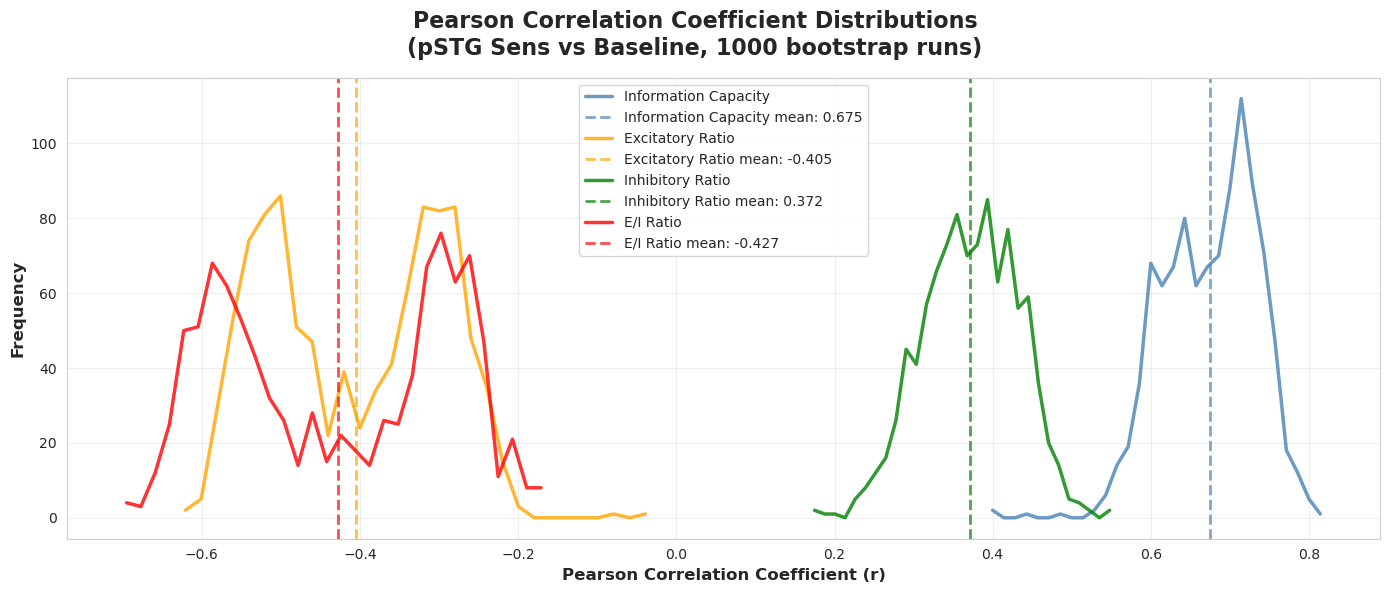

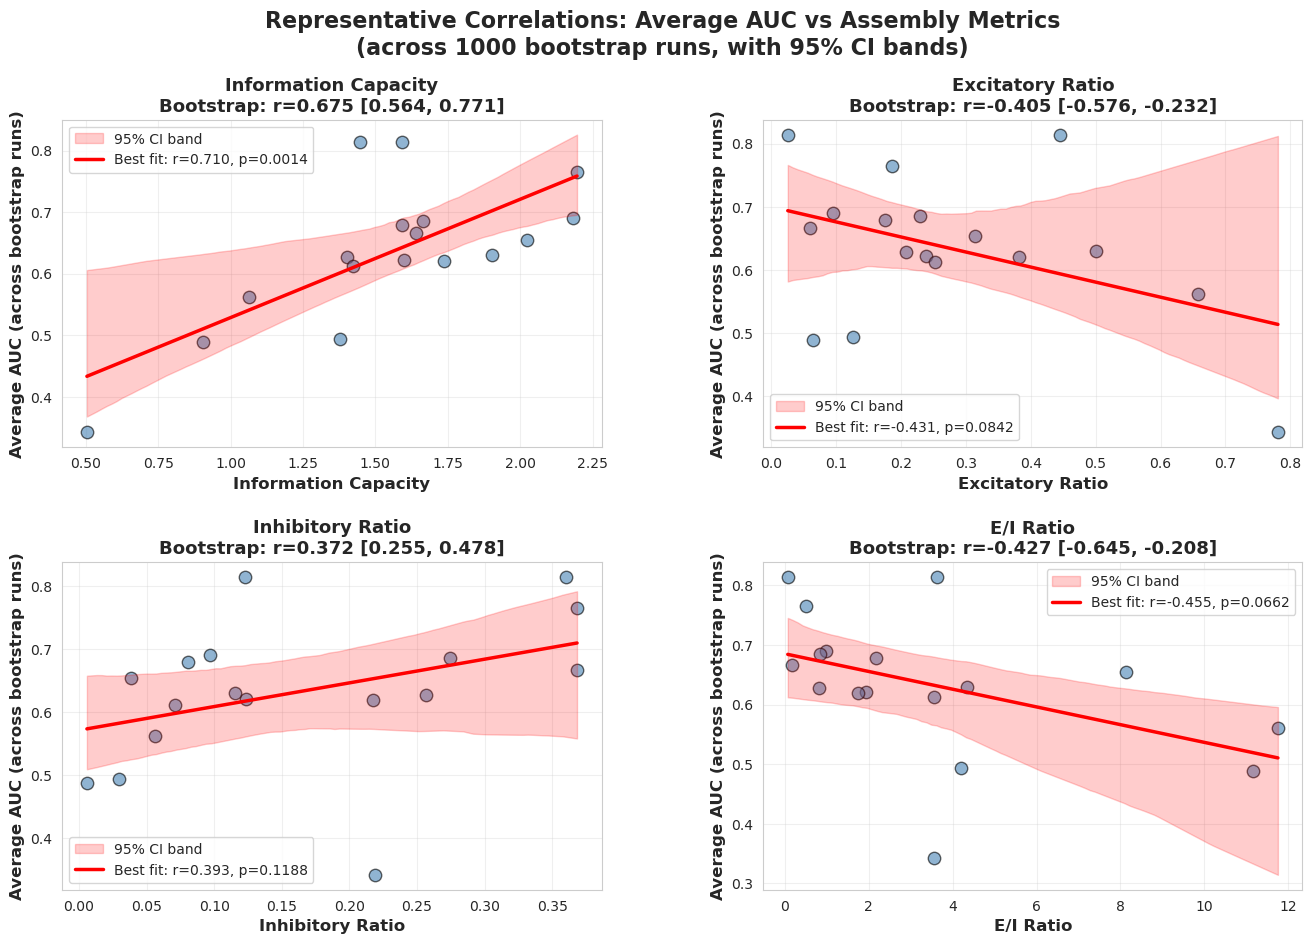

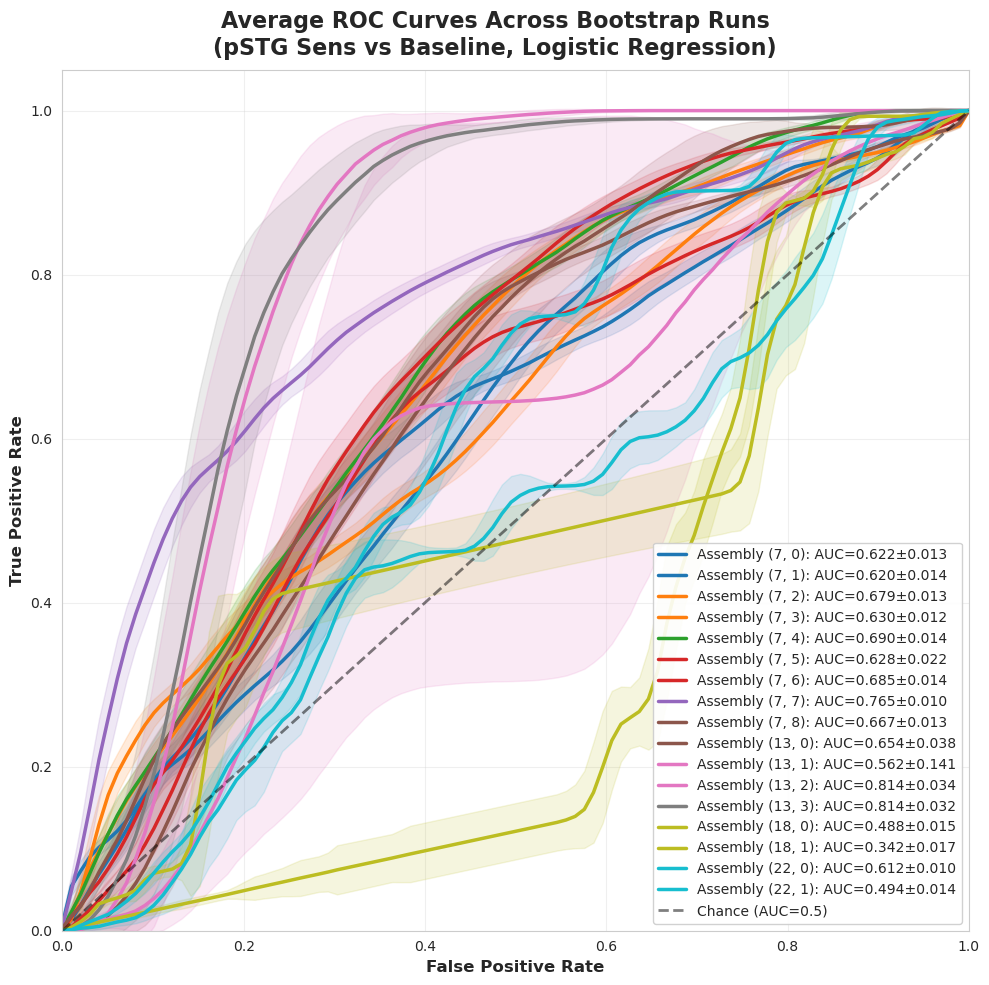


✓ Visualizations complete!
  - Correlation distributions: 4 metrics
  - Representative scatter plots: 4 metrics
  - Average ROC curves: 17 assemblies


In [10]:
# COMPREHENSIVE VISUALIZATIONS FOR BOOTSTRAP ANALYSIS
# 1. Correlation coefficient distributions with means
# 2. Representative correlation scatter plots with best fit lines
# 3. Representative ROC curves (if available)

print(f"\n{'='*80}")
print("COMPREHENSIVE BOOTSTRAP VISUALIZATIONS")
print(f"{'='*80}\n")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_curve, auc
from scipy.interpolate import interp1d

plt.rcParams['svg.fonttype'] = 'none'
sns.set_style("whitegrid")

# ============================================================================
# 1. PEARSON CORRELATION COEFFICIENT DISTRIBUTIONS (line plots with means)
# ============================================================================

fig1 = plt.figure(figsize=(14, 6))
ax1 = fig1.add_subplot(1, 1, 1)

fig1.suptitle('Pearson Correlation Coefficient Distributions\n(pSTG Sens vs Baseline, 1000 bootstrap runs)', 
             fontsize=16, fontweight='bold', y=0.98)

metrics_to_correlate = ['information_capacity', 'excitatory_ratio', 'inhibitory_ratio', 'ei_ratio']
metric_labels = {
    'information_capacity': 'Information Capacity',
    'excitatory_ratio': 'Excitatory Ratio',
    'inhibitory_ratio': 'Inhibitory Ratio',
    'ei_ratio': 'E/I Ratio'
}

colors = ['steelblue', 'orange', 'green', 'red']
for idx, metric in enumerate(metrics_to_correlate):
    metric_corrs = df_correlations[df_correlations['metric'] == metric]
    pearson_rs = metric_corrs['pearson_r'].values
    
    # Create histogram data
    counts, bins = np.histogram(pearson_rs, bins=30)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Plot as line plot (step plot)
    ax1.plot(bin_centers, counts, linewidth=2.5, color=colors[idx], 
            label=metric_labels[metric], alpha=0.8)
    
    # Add mean line
    mean_r = np.mean(pearson_rs)
    ax1.axvline(mean_r, color=colors[idx], linestyle='--', linewidth=2, 
               alpha=0.7, label=f'{metric_labels[metric]} mean: {mean_r:.3f}')

ax1.set_xlabel('Pearson Correlation Coefficient (r)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("bootstrap_coefficients.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 2. REPRESENTATIVE CORRELATION SCATTER PLOTS
# (Average AUC across bootstrap runs vs each metric)
# ============================================================================

# Compute average AUC for each assembly across all bootstrap runs
avg_auc_by_assembly = df_bootstrap.groupby('assembly_id')['auc'].mean().reset_index()
avg_auc_by_assembly.columns = ['assembly_id', 'avg_auc']

# Get metric values (same for all runs, so just take first run)
first_run_data = df_bootstrap[df_bootstrap['run'] == df_bootstrap['run'].min()].copy()
assembly_metrics = first_run_data[['assembly_id', 'information_capacity', 
                                    'excitatory_ratio', 'inhibitory_ratio', 'ei_ratio']].copy()

# Merge
plot_data = avg_auc_by_assembly.merge(assembly_metrics, on='assembly_id', how='inner')

fig2 = plt.figure(figsize=(16, 10))
gs2 = fig2.add_gridspec(2, 2, hspace=0.35, wspace=0.3)

fig2.suptitle('Representative Correlations: Average AUC vs Assembly Metrics\n(across 1000 bootstrap runs, with 95% CI bands)', 
             fontsize=16, fontweight='bold', y=0.99)

for idx, metric in enumerate(metrics_to_correlate):
    row = idx // 2
    col = idx % 2
    ax = fig2.add_subplot(gs2[row, col])
    
    # Get data for this metric
    x = plot_data[metric].values
    y = plot_data['avg_auc'].values
    
    # Remove NaN values
    valid_mask = ~(np.isnan(x) | np.isnan(y))
    x_clean = x[valid_mask]
    y_clean = y[valid_mask]
    
    if len(x_clean) > 1:
        # Scatter plot
        ax.scatter(x_clean, y_clean, alpha=0.6, s=80, color='steelblue', edgecolors='black', linewidth=1)
        
        # Linear regression
        slope, intercept, r_value, p_value, std_err = stats.linregress(x_clean, y_clean)
        
        # Create line of best fit
        x_line = np.linspace(x_clean.min(), x_clean.max(), 100)
        y_line = slope * x_line + intercept
        
        # Calculate confidence interval for the regression line
        # Using bootstrap method for CI
        n_boot = 1000
        slopes = []
        intercepts = []
        for _ in range(n_boot):
            indices = np.random.choice(len(x_clean), len(x_clean), replace=True)
            x_boot = x_clean[indices]
            y_boot = y_clean[indices]
            try:
                s, i, _, _, _ = stats.linregress(x_boot, y_boot)
                slopes.append(s)
                intercepts.append(i)
            except:
                continue
        
        slopes = np.array(slopes)
        intercepts = np.array(intercepts)
        
        # Calculate CI for each x point
        y_line_lower = np.zeros_like(x_line)
        y_line_upper = np.zeros_like(x_line)
        for i, x_val in enumerate(x_line):
            y_vals = slopes * x_val + intercepts
            y_line_lower[i] = np.percentile(y_vals, 2.5)
            y_line_upper[i] = np.percentile(y_vals, 97.5)
        
        # Plot CI band
        ax.fill_between(x_line, y_line_lower, y_line_upper, alpha=0.2, color='red', 
                       label='95% CI band')
        
        # Plot best fit line
        ax.plot(x_line, y_line, 'r-', linewidth=2.5, label=f'Best fit: r={r_value:.3f}, p={p_value:.4f}')
        
        # Get correlation from bootstrap analysis
        metric_corrs = df_correlations[df_correlations['metric'] == metric]
        bootstrap_mean_r = metric_corrs['pearson_r'].mean()
        bootstrap_ci_lower = np.percentile(metric_corrs['pearson_r'], 2.5)
        bootstrap_ci_upper = np.percentile(metric_corrs['pearson_r'], 97.5)
        
        ax.set_xlabel(metric_labels[metric], fontsize=12, fontweight='bold')
        ax.set_ylabel('Average AUC (across bootstrap runs)', fontsize=12, fontweight='bold')
        ax.set_title(f'{metric_labels[metric]}\n'
                    f'Bootstrap: r={bootstrap_mean_r:.3f} [{bootstrap_ci_lower:.3f}, {bootstrap_ci_upper:.3f}]', 
                    fontsize=13, fontweight='bold')
        ax.legend(loc='best', fontsize=10)
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', 
               transform=ax.transAxes, fontsize=14)
        ax.set_title(metric_labels[metric], fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig("bootstrap_correlations.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 3. AVERAGE ROC CURVES FOR EACH ASSEMBLY (ALL ON SAME AXES)
# ============================================================================

# Get unique assemblies
unique_assemblies = df_bootstrap['assembly_id'].unique()

# Create single figure with one axes
fig3 = plt.figure(figsize=(10, 10))
ax3 = fig3.add_subplot(1, 1, 1)

fig3.suptitle('Average ROC Curves Across Bootstrap Runs\n(pSTG Sens vs Baseline, Logistic Regression)', 
             fontsize=16, fontweight='bold', y=0.98)

# Use a colormap to get different colors for each assembly
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_assemblies)))

# Interpolate all ROC curves to common FPR points
all_fpr = np.linspace(0, 1, 100)

for idx, assembly_id in enumerate(unique_assemblies):
    # Get all ROC curves for this assembly across all bootstrap runs
    assembly_mask = df_bootstrap['assembly_id'] == assembly_id
    assembly_fprs = df_bootstrap.loc[assembly_mask, 'fpr'].values
    assembly_tprs = df_bootstrap.loc[assembly_mask, 'tpr'].values
    assembly_aucs = df_bootstrap.loc[assembly_mask, 'auc'].values
    
    if len(assembly_fprs) > 0:
        # Interpolate all ROC curves to common FPR points
        all_tpr = []
        
        for fpr_array, tpr_array in zip(assembly_fprs, assembly_tprs):
            # Handle case where fpr/tpr might be stored as lists
            if isinstance(fpr_array, (list, np.ndarray)) and isinstance(tpr_array, (list, np.ndarray)):
                fpr_array = np.array(fpr_array)
                tpr_array = np.array(tpr_array)
                # Interpolate
                tpr_interp = np.interp(all_fpr, fpr_array, tpr_array)
                all_tpr.append(tpr_interp)
        
        if len(all_tpr) > 0:
            all_tpr = np.array(all_tpr)
            mean_tpr = np.mean(all_tpr, axis=0)
            std_tpr = np.std(all_tpr, axis=0)
            mean_auc = np.mean(assembly_aucs)
            std_auc = np.std(assembly_aucs)
            
            # Plot mean with confidence interval
            ax3.plot(all_fpr, mean_tpr, color=colors[idx], lw=2.5, 
                   label=f'Assembly {assembly_id}: AUC={mean_auc:.3f}±{std_auc:.3f}')
            ax3.fill_between(all_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr,
                           color=colors[idx], alpha=0.15)

# Plot chance line (only once)
ax3.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5, label='Chance (AUC=0.5)')

ax3.set_xlim([0.0, 1.0])
ax3.set_ylim([0.0, 1.05])
ax3.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax3.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax3.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("bootstrap_roc_curves.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Visualizations complete!")
print(f"  - Correlation distributions: {len(metrics_to_correlate)} metrics")
print(f"  - Representative scatter plots: {len(metrics_to_correlate)} metrics")
print(f"  - Average ROC curves: {len(unique_assemblies)} assemblies")

In [ ]:
# OUTLIER CHECK pSTG
# add me here — pSTG assemblies: capacity + E/I (run after pSTG PER-ASSEMBLY bootstrap cell)
import pandas as pd

if "df_bootstrap_pstg" not in globals():
    raise RuntimeError("Run the pSTG PER-ASSEMBLY bootstrap cell first (it creates df_bootstrap_pstg).")

b = df_bootstrap_pstg.copy()


def _assembly_id_parts(aid):
    if isinstance(aid, tuple) and len(aid) == 2:
        return int(aid[0]), int(aid[1])
    if isinstance(aid, list) and len(aid) == 2:
        return int(aid[0]), int(aid[1])
    import ast

    t = ast.literal_eval(str(aid))
    return int(t[0]), int(t[1])


b["insertion_idx"] = b["assembly_id"].apply(lambda a: _assembly_id_parts(a)[0])
b["assembly_idx"] = b["assembly_id"].apply(lambda a: _assembly_id_parts(a)[1])

cols = [
    "insertion_idx",
    "assembly_idx",
    "information_capacity",
    "excitatory_ratio",
    "inhibitory_ratio",
    "ei_ratio",
]
pstg_asm = (
    b[cols]
    .drop_duplicates(subset=["insertion_idx", "assembly_idx"])
    .sort_values(["insertion_idx", "assembly_idx"])
    .reset_index(drop=True)
)

pstg_asm = pstg_asm.rename(
    columns={
        "information_capacity": "information_capacity",
        "excitatory_ratio": "E_ratio",
        "inhibitory_ratio": "I_ratio",
        "ei_ratio": "EI_ratio",
    }
)

print(f"pSTG assemblies in table: {len(pstg_asm)}")
display(pstg_asm)

pSTG assemblies in table: 17


,insertion_idx,assembly_idx,information_capacity,E_ratio,I_ratio,EI_ratio
0,7,0,1.598921,0.238830,0.123616,1.932032
1,7,1,1.736817,0.381595,0.217624,1.753458
2,7,2,1.591912,0.176002,0.080918,2.175073
3,7,3,1.901901,0.500402,0.115343,4.338386
4,7,4,2.182416,0.094445,0.096944,0.974224
5,7,5,1.402055,0.207082,0.256570,0.807116
6,7,6,1.663271,0.229544,0.274359,0.836654
7,7,7,2.196540,0.186058,0.367966,0.505639
8,7,8,1.640916,0.060288,0.368343,0.163674
9,13,0,2.024076,0.313973,0.038611,8.131620


PER-ASSEMBLY LOGISTIC REGRESSION ANALYSIS (LR ONLY) - BOOTSTRAP
Other regions (excluding parsTr, parsOp, vPrCG, pSTG, PoCG) with sens events (Sens vs Baseline)
Using yield_independent_capacity from pickle file
Running 1000 iterations with different baseline samples

Loading yield_independent_capacity data...
Loaded from pickle: 154 entries
Found 10 other region insertions with sens events

Pre-computing assemblies and extracting sens expression values...
  Behavioral duration 14.15 min (>= 0 min) — using TaskTimes restrict; KS window [321.000, 1261.000] s
  Behavioral duration 14.90 min (>= 0 min) — using TaskTimes restrict; KS window [268.000, 1162.000] s
  Behavioral duration 7.28 min (>= 0 min) — using TaskTimes restrict; KS window [147.000, 584.000] s
  Behavioral duration 10.15 min (>= 0 min) — using TaskTimes restrict; KS window [330.000, 939.000] s
  Behavioral duration 8.07 min (>= 0 min) — using TaskTimes restrict; KS window [1380.000, 1864.000] s
  Behavioral duration 26.82 m

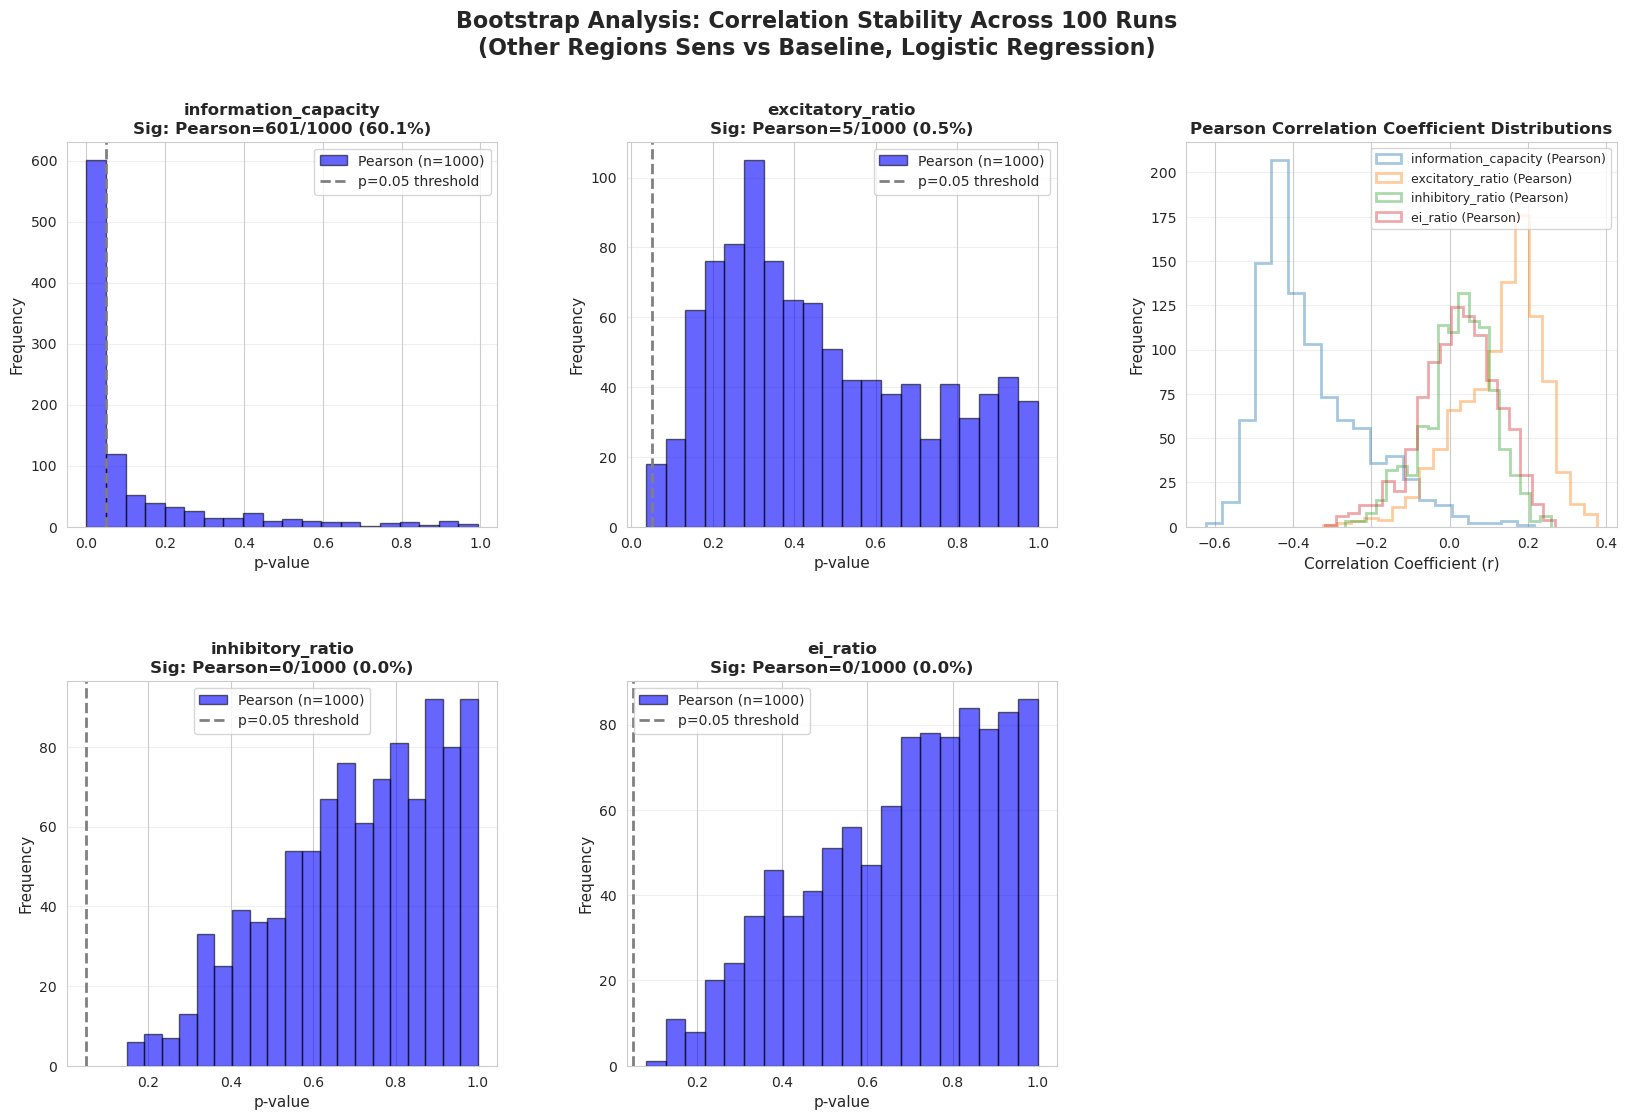


Created visualization showing p-value distributions and correlation stability

ANALYSIS COMPLETE


In [15]:
# PER-ASSEMBLY LOGISTIC REGRESSION ANALYSIS (LR ONLY) - BOOTSTRAP VERSION
# Other regions (excluding parsTr, parsOp, vPrCG, pSTG, PoCG) with sens events
# Compares sens periods vs non-language periods (baseline)
# Uses Logistic Regression classifier only
# Uses yield_independent_capacity from pickle file
# Runs 1000 times with different baseline samples to assess stability

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import ttest_ind, mannwhitneyu, kstest, spearmanr, pearsonr
from scipy.linalg import norm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.decomposition import PCA, FastICA
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import fnmatch
import pickle
import os

warnings.filterwarnings('ignore')

plt.rcParams['svg.fonttype'] = 'none'
sns.set_style("whitegrid")

print("=" * 80)
print("PER-ASSEMBLY LOGISTIC REGRESSION ANALYSIS (LR ONLY) - BOOTSTRAP")
print("Other regions (excluding parsTr, parsOp, vPrCG, pSTG, PoCG) with sens events (Sens vs Baseline)")
print("Using yield_independent_capacity from pickle file")
print("Running 1000 iterations with different baseline samples")
print("=" * 80)

# Load yield_independent_capacity from pickle or CSV
print("\nLoading yield_independent_capacity data...")
capacity_map = {}

try:
    pkl_path = 'yield_independent_assembly_capacity.pkl'
    if os.path.exists(pkl_path):
        with open(pkl_path, 'rb') as f:
            capacity_data = pickle.load(f)
        if isinstance(capacity_data, pd.DataFrame):
            for idx, row in capacity_data.iterrows():
                insertion_idx = int(row['insertion_idx'])
                assembly_number = int(row['assembly_number'])
                capacity = float(row['yield_independent_capacity'])
                capacity_map[(insertion_idx, assembly_number)] = capacity
        elif isinstance(capacity_data, dict):
            if len(capacity_data) > 0:
                first_key = list(capacity_data.keys())[0]
                if isinstance(first_key, tuple) and len(first_key) == 2:
                    capacity_map = capacity_data
                else:
                    for key, value in capacity_data.items():
                        if isinstance(value, dict) and 'yield_independent_capacity' in value:
                            capacity_map[key] = value['yield_independent_capacity']
        print(f"Loaded from pickle: {len(capacity_map)} entries")
    else:
        raise FileNotFoundError("Pickle file not found")
except Exception as e:
    print(f"Error loading pickle: {e}")
    try:
        csv_path = 'yield_independent_assembly_capacity.csv'
        capacity_df = pd.read_csv(csv_path)
        for idx, row in capacity_df.iterrows():
            insertion_idx = int(row['insertion_idx'])
            assembly_number = int(row['assembly_number'])
            capacity = float(row['yield_independent_capacity'])
            capacity_map[(insertion_idx, assembly_number)] = capacity
        print(f"Loaded from CSV: {len(capacity_map)} entries")
    except Exception as e2:
        print(f"ERROR: Could not load capacity data: {e2}")
        capacity_map = {}

def calculate_expression_strength(firingRateMatrix, ap_norm_matrix):
    """Calculate expression strength"""
    n_time_bins, n_neurons = firingRateMatrix.shape
    n_assemblies = ap_norm_matrix.shape[0]
    expression_strength = np.zeros((n_time_bins, n_assemblies))
    for assembly_idx in range(n_assemblies):
        weight_vector = ap_norm_matrix[assembly_idx, :]
        outer_product = np.outer(weight_vector, weight_vector)
        for time_bin in range(n_time_bins):
            firing_rate_vector = firingRateMatrix[time_bin, :]
            expression_strength[time_bin, assembly_idx] = firing_rate_vector.T @ outer_product @ firing_rate_vector
    return expression_strength

MIN_BEHAVIOR_MINUTES = 0

def _behavior_duration_seconds(task_times_obj):
    starts = np.asarray(task_times_obj.start, dtype=float).ravel()
    ends = np.asarray(task_times_obj.end, dtype=float).ravel()
    if starts.size != ends.size:
        return np.nan
    return float(np.sum(ends - starts))

def _ks_time_bounds_full_recording(spike_times_obj):
    """Min/max time for uniform KS (full recording)."""
    tmin, tmax = np.inf, -np.inf
    for u in range(len(spike_times_obj)):
        idx = spike_times_obj[u].as_series().index.values
        if len(idx):
            tmin = min(tmin, float(np.min(idx)))
            tmax = max(tmax, float(np.max(idx)))
    if np.isfinite(tmin) and np.isfinite(tmax):
        return tmin, tmax
    return np.nan, np.nan

def imec_key_sorter(key):
    """Extract the number after 'imec'"""
    match = re.search(r'imec(\d+)', key)
    return int(match.group(1)) if match else float('inf')

def map_to_pickle_insertion_idx(insertion_counter):
    """Map insertion_counter to pickle insertion_idx"""
    if insertion_counter >= 13:
        return insertion_counter + 2
    else:
        return insertion_counter

def find_valid_baseline_windows(task_start, task_end, all_language_starts, all_language_ends,
                               buffer, baseline_duration, bin_starts, bin_ends):
    """
    Pre-compute all valid baseline windows that don't overlap with language events.
    Returns list of (start, end) tuples for valid baseline periods.
    """
    valid_windows = []
    # Create a fine grid of potential start times
    step_size = 0.01  # 10ms steps
    potential_starts = np.arange(task_start, task_end - baseline_duration + step_size, step_size)
    for start_candidate in potential_starts:
        end_candidate = start_candidate + baseline_duration
        # Check if this window overlaps with any language event
        overlaps = False
        for lang_start, lang_end in zip(all_language_starts, all_language_ends):
            if not (end_candidate < lang_start - buffer or start_candidate > lang_end + buffer):
                overlaps = True
                break
        if not overlaps:
            # Check if we have bins that cover this window
            mask = (bin_starts >= start_candidate) & (bin_ends <= end_candidate)
            if np.any(mask):
                valid_windows.append((start_candidate, end_candidate))
    return valid_windows

# Get other region insertions with sens events (excluding parsTr, parsOp, vPrCG, pSTG, PoCG)
excluded_regions = ['parsTr', 'parsOp', 'vPrCG', 'pSTG', 'PoCG']
other_region_insertions = []
insertion_counter = 0

for i in range(len(nwb_paths)):
    data = nap.load_file(nwb_paths[i])
    keys = data.keys()
    template = "*imec*"
    keys = [key for key in keys if fnmatch.fnmatch(key, template)]
    ks_keys = [key for key in keys if "KS4" in key]
    if ks_keys:
        keys = ks_keys
    th8_keys = [key for key in keys if "Th=8" in key]
    if th8_keys:
        keys = th8_keys
    else:
        th_keys = [key for key in keys if "Th=" in key]
        if th_keys:
            keys = th_keys
    template_sentgen = "*sentgen*"
    template_auto = "*_auto*"
    keys = [key for key in keys if not fnmatch.fnmatch(key, template_sentgen) and not fnmatch.fnmatch(key, template_auto)]
    if 'NP137' in str(nwb_paths[i]) or 'NP139_B2' in str(nwb_paths[i]):
        keys = [key for key in keys if 'imec1' not in key]
    keys = sorted(keys, key=imec_key_sorter)
    for s in range(len(keys)):
        if insertion_counter < len(region_list):
            region = region_list[insertion_counter]
            if region not in excluded_regions:
                has_sens = ("StimSpeechWords" in data) or ("mfa_stim_words" in data)
                if has_sens:
                    other_region_insertions.append({
                        'nwb_idx': i,
                        'session_idx': s,
                        'insertion_idx': insertion_counter,
                        'region': region,
                        'opercular': opercular_list[insertion_counter] if insertion_counter < len(opercular_list) else None
                    })
        insertion_counter += 1

print(f"Found {len(other_region_insertions)} other region insertions with sens events")

# PRE-COMPUTE ALL ASSEMBLIES AND DATA (ONCE, OUTSIDE BOOTSTRAP LOOP)
print("\nPre-computing assemblies and extracting sens expression values...")

assembly_data = {}  # Store pre-computed data for each assembly

for ins_info in other_region_insertions:
    nwb_idx = ins_info['nwb_idx']
    session_idx = ins_info['session_idx']
    insertion_idx = ins_info['insertion_idx']
    region = ins_info['region']
    opercular = ins_info['opercular']

    # Load data
    data = nap.load_file(nwb_paths[nwb_idx])
    keys = data.keys()
    template = "*imec*"
    keys = [key for key in keys if fnmatch.fnmatch(key, template)]
    ks_keys = [key for key in keys if "KS4" in key]
    if ks_keys:
        keys = ks_keys
    th8_keys = [key for key in keys if "Th=8" in key]
    if th8_keys:
        keys = th8_keys
    else:
        th_keys = [key for key in keys if "Th=" in key]
        if th_keys:
            keys = th_keys
    template_sentgen = "*sentgen*"
    template_auto = "*_auto*"
    keys = [key for key in keys if not fnmatch.fnmatch(key, template_sentgen) and not fnmatch.fnmatch(key, template_auto)]
    if 'NP137' in str(nwb_paths[nwb_idx]) or 'NP139_B2' in str(nwb_paths[nwb_idx]):
        keys = [key for key in keys if 'imec1' not in key]
    keys = sorted(keys, key=imec_key_sorter)
    spike_times = data[keys[session_idx]]
    has_prod = "ProdSpeechWords" in data
    has_sens = ("StimSpeechWords" in data) or ("mfa_stim_words" in data)
    if not has_sens:
        continue
    # Filter to good neurons
    firingRates_all = spike_times.metadata["rate"]
    if "TaskTimes" in data.keys():
        task_times = data["TaskTimes"]
    else:
        task_times = data["task_times"]

    start_time = task_times.start
    end_time = task_times.end
    beh_epochs = nap.IntervalSet(start=task_times.start, end=task_times.end)

    beh_sec = _behavior_duration_seconds(task_times)
    beh_min = beh_sec / 60.0 if np.isfinite(beh_sec) else np.nan
    use_full_recording = (not np.isfinite(beh_min)) or (beh_min < MIN_BEHAVIOR_MINUTES)

    if use_full_recording:
        spike_times_beh = spike_times
        firingRates_beh = firingRates_all
        min_time, max_time = _ks_time_bounds_full_recording(spike_times)
        if not (np.isfinite(min_time) and np.isfinite(max_time)) or (max_time <= min_time):
            print(f"  Short behavior ({beh_min:.2f} min) but could not get recording bounds; skipping shank")
            continue
        print(
            f"  Behavioral duration {beh_min:.2f} min (< {MIN_BEHAVIOR_MINUTES} min) — using full recording for filters; KS window [{min_time:.3f}, {max_time:.3f}] s"
        )
    else:
        spike_times_beh = spike_times.restrict(beh_epochs)
        firingRates_beh = spike_times_beh.metadata["rate"]
        min_time = start_time[0]
        max_time = end_time[-1]
        print(
            f"  Behavioral duration {beh_min:.2f} min (>= {MIN_BEHAVIOR_MINUTES} min) — using TaskTimes restrict; KS window [{min_time:.3f}, {max_time:.3f}] s"
        )

    ks_stats = np.zeros(len(spike_times))
    ks_pvals = np.zeros(len(spike_times))
    for u in range(len(spike_times)):
        test = spike_times[u].as_series().index.values
        if len(test) > 1:
            normalized_spike_times = (test - min_time) / (max_time - min_time)
            ks_result = kstest(normalized_spike_times, 'uniform')
            ks_stats[u] = ks_result.statistic
            ks_pvals[u] = ks_result.pvalue
        else:
            ks_stats[u] = np.nan
            ks_pvals[u] = np.nan
    violationThreshold = 3 / 1000
    violationPct = np.zeros(len(spike_times))
    for u in range(len(spike_times)):
        unit = spike_times[u]
        unit = unit.as_series().index
        if len(unit) < 100:
            violationPct[u] = 1
        else:
            isi = unit.diff()[1:len(unit)]
            violations = np.where(isi < violationThreshold)
            violations = np.array(violations)
            violationPct[u] = violations.size / len(isi)
    if "KSLabel" in spike_times.metadata:
        KSLabels = spike_times.metadata["KSLabel"]
    else:
        KSLabels = spike_times.metadata["quality"]
    firingRates = firingRates_beh
    mask1 = violationPct < 3 / 100
    mask2 = firingRates > 0.5
    mask3 = KSLabels != "noise"
    mask4 = ks_stats < 0.3
    mask = mask1 & mask2 & mask3 & mask4
    indicesFinal = firingRates.index[mask]
    if insertion_idx < len(manual_exclude_lists):
        indicesFinal = np.setdiff1d(indicesFinal, manual_exclude_lists[insertion_idx])
    spike_times_good = spike_times[indicesFinal]
    n_neurons = len(spike_times_good)
    if n_neurons == 0:
        continue
    # Make spike rate matrix
    timescale = 25 / 1000
    spikeCountMatrix = spike_times_good.count(bin_size=timescale)
    bin_edges = spikeCountMatrix.index.values
    bin_centers = bin_edges[:-1] + np.diff(bin_edges) / 2
    if len(bin_centers) < len(bin_edges):
        last_width = bin_edges[-1] - bin_edges[-2] if len(bin_edges) > 1 else 0
        last_center = bin_edges[-1] - last_width / 2
        bin_centers = np.append(bin_centers, last_center)
    spikeCountMatrix = spikeCountMatrix.values
    firingRateMatrix = spikeCountMatrix / timescale
    firingRateMatrix = stats.zscore(firingRateMatrix, axis=0)
    # Calculate assemblies
    pca = PCA()
    firingRateMatrix_pca = pca.fit_transform(firingRateMatrix)
    eigenvalues = pca.explained_variance_
    upperbound = (1 + np.sqrt(firingRateMatrix.shape[1] / firingRateMatrix.shape[0])) ** 2
    assemblyIndices = np.where(eigenvalues > upperbound)
    assemblyEigenvalues = eigenvalues[assemblyIndices]
    n_pcs = len(assemblyEigenvalues)
    if n_pcs == 0:
        continue
    # Get cluster labels if available
    insertion_cluster_labels = []
    if 'et_sparse_labels' in globals() and 'et_sparse_metadata' in globals():
        matching_neurons = [(idx, neuron) for idx, neuron in enumerate(et_sparse_metadata)
                            if neuron.get('insertion_idx') == insertion_idx]
        for local_neuron_idx in range(len(indicesFinal)):
            cluster_label = -1
            if local_neuron_idx < len(matching_neurons):
                global_idx = matching_neurons[local_neuron_idx][0]
                cluster_label = et_sparse_labels[global_idx]
            insertion_cluster_labels.append(cluster_label)
    else:
        insertion_cluster_labels = [-1] * len(indicesFinal)
    insertion_cluster_labels = np.array(insertion_cluster_labels)
    # Orthogonalize with ICA
    pc_vectors = pca.components_[:n_pcs, :]
    projections = firingRateMatrix @ pc_vectors.T
    fastica = FastICA(n_components=n_pcs, algorithm='parallel', whiten='unit-variance',
                      max_iter=500, tol=1e-7, random_state=1)
    ica_components = fastica.fit_transform(projections)
    unmixing_matrix = fastica.components_
    ica_assembly_patterns = unmixing_matrix @ pc_vectors
    # Normalize assembly patterns
    ap_norm_matrix = ica_assembly_patterns.copy()
    for ii in range(n_pcs):
        ap = ica_assembly_patterns[ii, :]
        ap_norm = ap / norm(ap)
        maxW = max(ap_norm)
        minW = min(ap_norm)
        if abs(minW) > maxW:
            ap_norm = ap_norm * -1
        ap_norm_matrix[ii, :] = ap_norm
    # Calculate expression strength
    expression_strength_matrix = calculate_expression_strength(firingRateMatrix, ap_norm_matrix)
    # Get sens trial times and task times for baseline
    sens_rel_start = 0
    sens_rel_end = 0.10
    if "StimSpeechWords" in data:
        speech_sens_times = data["StimSpeechWords"]
    else:
        speech_sens_times = data["mfa_stim_words"]
    sens_onsets = nap.Ts(speech_sens_times.start)
    sens_offsets = nap.Ts(speech_sens_times.end)
    sens_starts = sens_onsets.as_series().index + sens_rel_start
    sens_ends = sens_offsets.as_series().index + sens_rel_end
    # Get task times for baseline
    if "TaskTimes" in data.keys():
        task_times = data["TaskTimes"]
    else:
        task_times = data["task_times"]
    if isinstance(task_times.start, np.ndarray):
        task_start = task_times.start[0]
        task_end = task_times.end[-1]
    else:
        task_start = task_times.start.values[0]
        task_end = task_times.end.values[-1]
    # Get prod times if available
    prod_starts = []
    prod_ends = []
    if has_prod:
        prod_rel_start = -0.10
        prod_rel_end = 0
        speech_prod_times = data["ProdSpeechWords"]
        prod_onsets = nap.Ts(speech_prod_times.start)
        prod_offsets = nap.Ts(speech_prod_times.end)
        prod_starts = (prod_onsets.as_series().index + prod_rel_start).values
        prod_ends = (prod_offsets.as_series().index + prod_rel_end).values
    sens_starts = sens_starts.values
    sens_ends = sens_ends.values
    # Pre-compute bin boundaries
    bin_starts = bin_centers - timescale / 2
    bin_ends = bin_centers + timescale / 2
    # Pre-compute all valid baseline windows once per insertion
    all_language_starts = list(sens_starts)
    all_language_ends = list(sens_ends)
    if has_prod:
        all_language_starts.extend(prod_starts)
        all_language_ends.extend(prod_ends)
    buffer = 0.1
    baseline_duration = 0.1
    valid_baseline_windows = find_valid_baseline_windows(
        task_start, task_end, all_language_starts, all_language_ends,
        buffer, baseline_duration, bin_starts, bin_ends
    )
    # For each assembly, pre-compute everything except baseline sampling
    for asm_idx in range(n_pcs):
        assembly_expression = ica_components[:, asm_idx]
        # Get yield-independent capacity
        pickle_insertion_idx = map_to_pickle_insertion_idx(insertion_idx)
        if (pickle_insertion_idx, asm_idx) in capacity_map:
            info_capacity = capacity_map[(pickle_insertion_idx, asm_idx)]
        else:
            info_capacity = np.nan
        # Calculate ratios
        assembly_pattern = ap_norm_matrix[asm_idx, :]
        weights = assembly_pattern
        excitatory_tone = np.sum(weights[insertion_cluster_labels == 0])
        inhibitory_tone = np.sum(weights[insertion_cluster_labels == 2])
        total_tone = np.sum(abs(weights))
        excitatory_ratio = np.abs(excitatory_tone) / (total_tone + 1e-10)
        inhibitory_ratio = np.abs(inhibitory_tone) / (total_tone + 1e-10)
        ei_ratio = excitatory_ratio / (inhibitory_ratio + 1e-10)
        # Extract sens expression values (same for all bootstrap iterations)
        sens_expression_values = []
        for u in range(len(sens_starts)):
            interval_start = sens_starts[u]
            interval_end = sens_ends[u]
            mask = (bin_starts >= interval_start) & (bin_ends <= interval_end)
            if np.any(mask):
                trial_expression = np.mean(assembly_expression[mask])
                sens_expression_values.append(trial_expression)

        # Drop assemblies that are essentially purely-E or purely-I
        # (matches R_z_AIproductionref behavior).
        #if (excitatory_ratio < 0.0001) or (inhibitory_ratio < 0.0001):
        if ei_ratio > 19.57: # fileter out extreme outliers
            excitatory_ratio = np.nan
            inhibitory_ratio = np.nan
            ei_ratio = np.nan
            info_capacity = np.nan
            sens_expression_values = [np.nan for _ in sens_expression_values]

        # Store pre-computed data for this assembly
        assembly_id = (insertion_idx, asm_idx)
        assembly_data[assembly_id] = {
            'insertion_idx': insertion_idx,
            'assembly_idx': asm_idx,
            'region': region,
            'opercular': opercular,
            'assembly_expression': assembly_expression,
            'sens_expression_values': sens_expression_values,
            'valid_baseline_windows': valid_baseline_windows,
            'bin_starts': bin_starts,
            'bin_ends': bin_ends,
            'info_capacity': info_capacity,
            'excitatory_ratio': excitatory_ratio,
            'inhibitory_ratio': inhibitory_ratio,
            'ei_ratio': ei_ratio,
            'n_neurons': n_neurons
        }

print(f"Pre-computed data for {len(assembly_data)} assemblies")

# Number of bootstrap iterations
n_bootstrap = 1000

# Storage for bootstrap results
bootstrap_results = {
    'run': [],
    'assembly_id': [],
    'auc': [],
    'information_capacity': [],
    'excitatory_ratio': [],
    'inhibitory_ratio': [],
    'ei_ratio': [],
    'fpr': [],
    'tpr': []
}

# Storage for correlation results across runs
correlation_results = {
    'run': [],
    'metric': [],
    'pearson_r': [],
    'pearson_p': []
}

print(f"\nRunning {n_bootstrap} bootstrap iterations...")

# Run bootstrap iterations - ONLY baseline sampling and correlation calculation
for bootstrap_iter in range(n_bootstrap):
    print(f"Iteration {bootstrap_iter + 1}/{n_bootstrap}...", end=' ', flush=True)
    # Set random seed for this iteration
    np.random.seed(bootstrap_iter)
    # Process each assembly
    for assembly_id, asm_data in assembly_data.items():
        sens_expression_values = asm_data['sens_expression_values']
        valid_baseline_windows = asm_data['valid_baseline_windows']
        assembly_expression = asm_data['assembly_expression']
        bin_starts = asm_data['bin_starts']
        bin_ends = asm_data['bin_ends']
        if len(valid_baseline_windows) == 0:
            continue
        # Sample baseline periods from pre-computed valid windows
        baseline_expression_values = []
        n_baseline_samples = len(sens_expression_values)
        # Sample with replacement from valid windows
        if len(valid_baseline_windows) >= n_baseline_samples:
            selected_windows = np.random.choice(len(valid_baseline_windows),
                                                size=n_baseline_samples, replace=False)
        else:
            selected_windows = np.random.choice(len(valid_baseline_windows),
                                                size=n_baseline_samples, replace=True)
        for window_idx in selected_windows:
            start_candidate, end_candidate = valid_baseline_windows[window_idx]
            mask = (bin_starts >= start_candidate) & (bin_ends <= end_candidate)
            if np.any(mask):
                baseline_expression = np.mean(assembly_expression[mask])
                baseline_expression_values.append(baseline_expression)
        if len(sens_expression_values) < 3 or len(baseline_expression_values) < 3:
            continue
        # Prepare data
        X_all = np.array(sens_expression_values + baseline_expression_values).reshape(-1, 1)
        y_all = np.array([1] * len(sens_expression_values) + [0] * len(baseline_expression_values))
        # Cross-validation with Logistic Regression
        try:
            n_sens = np.sum(y_all == 1)
            n_baseline = np.sum(y_all == 0)
            n_splits = min(5, min(n_sens, n_baseline))
            if n_splits < 2:
                continue
            skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
            cv_aucs = []
            for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all)):
                X_train_cv, X_val_cv = X_all[train_idx], X_all[val_idx]
                y_train_cv, y_val_cv = y_all[train_idx], y_all[val_idx]
                lr = LogisticRegression(C=1.0, penalty='l2', class_weight='balanced', random_state=42, max_iter=1000)
                lr.fit(X_train_cv, y_train_cv)
                y_pred_proba_cv = lr.predict_proba(X_val_cv)[:, 1]
                auc_cv = roc_auc_score(y_val_cv, y_pred_proba_cv)
                cv_aucs.append(auc_cv)
            cv_aucs = np.array(cv_aucs)
            cv_auc_mean = np.mean(cv_aucs)
            # Train final model on all data for ROC curve
            lr_final = LogisticRegression(
                C=1.0,
                penalty='l2',
                class_weight='balanced',
                random_state=42,
                max_iter=1000
            )
            lr_final.fit(X_all, y_all)
            y_pred_proba_all = lr_final.predict_proba(X_all)[:, 1]
            fpr, tpr, thresholds = roc_curve(y_all, y_pred_proba_all)
            # Store results for this bootstrap iteration
            bootstrap_results['run'].append(bootstrap_iter)
            bootstrap_results['assembly_id'].append(assembly_id)
            bootstrap_results['auc'].append(cv_auc_mean)
            bootstrap_results['information_capacity'].append(asm_data['info_capacity'])
            bootstrap_results['excitatory_ratio'].append(asm_data['excitatory_ratio'])
            bootstrap_results['inhibitory_ratio'].append(asm_data['inhibitory_ratio'])
            bootstrap_results['ei_ratio'].append(asm_data['ei_ratio'])
            bootstrap_results['fpr'].append(fpr)
            bootstrap_results['tpr'].append(tpr)
        except Exception as e:
            continue
    # Calculate correlations for this bootstrap iteration
    # Get only results from this iteration
    start_idx = len([r for r in bootstrap_results['run'] if r < bootstrap_iter])
    end_idx = len([r for r in bootstrap_results['run'] if r <= bootstrap_iter])
    if end_idx > start_idx:
        df_iter = pd.DataFrame({
            'auc': bootstrap_results['auc'][start_idx:end_idx],
            'information_capacity': bootstrap_results['information_capacity'][start_idx:end_idx],
            'excitatory_ratio': bootstrap_results['excitatory_ratio'][start_idx:end_idx],
            'inhibitory_ratio': bootstrap_results['inhibitory_ratio'][start_idx:end_idx],
            'ei_ratio': bootstrap_results['ei_ratio'][start_idx:end_idx]
        })
        metrics_to_correlate = ['information_capacity', 'excitatory_ratio', 'inhibitory_ratio', 'ei_ratio']
        for metric in metrics_to_correlate:
            valid_data = df_iter.dropna(subset=[metric, 'auc'])
            if len(valid_data) > 1:
                r_pearson, p_pearson = pearsonr(valid_data[metric], valid_data['auc'])
                correlation_results['run'].append(bootstrap_iter)
                correlation_results['metric'].append(metric)
                correlation_results['pearson_r'].append(r_pearson)
                correlation_results['pearson_p'].append(p_pearson)
    print("Done")

print(f"\n{'='*80}")
print("BOOTSTRAP ANALYSIS COMPLETE")
print(f"{'='*80}")

# Create DataFrames
df_bootstrap = pd.DataFrame(bootstrap_results)
df_correlations = pd.DataFrame(correlation_results)
# Save results for comparison
df_bootstrap_other = df_bootstrap.copy()
df_correlations_other = df_correlations.copy()
print(f"✓ Saved other regions bootstrap results: {len(df_bootstrap_other)} rows")


# Analyze correlation stability
print(f"\n{'='*80}")
print("CORRELATION STABILITY ANALYSIS")
print(f"{'='*80}")

metrics_to_correlate = ['information_capacity', 'excitatory_ratio', 'inhibitory_ratio', 'ei_ratio']
for metric in metrics_to_correlate:
    metric_corrs = df_correlations[df_correlations['metric'] == metric]
    if len(metric_corrs) > 0:
        print(f"\n{metric}:")
        print(f"  Pearson r: mean = {metric_corrs['pearson_r'].mean():.4f} ± {metric_corrs['pearson_r'].std():.4f}")
        print(f"  Pearson p: mean = {metric_corrs['pearson_p'].mean():.4f}, median = {metric_corrs['pearson_p'].median():.4f}")
        # Count how many runs are significant
        n_sig_pearson = np.sum(metric_corrs['pearson_p'] < 0.05)
        print(f"  Significant runs (p < 0.05): Pearson = {n_sig_pearson}/{len(metric_corrs)} ({100*n_sig_pearson/len(metric_corrs):.1f}%)")
        # Percentiles
        print(f"  Pearson p percentiles: 5th = {np.percentile(metric_corrs['pearson_p'], 5):.4f}, "
              f"95th = {np.percentile(metric_corrs['pearson_p'], 95):.4f}")

# Statistical tests for overall significance
print(f"\n{'='*80}")
print("STATISTICAL TESTS FOR OVERALL SIGNIFICANCE")
print(f"{'='*80}")
print("\nMultiple approaches to assess significance across bootstrap runs:")
print("  1. Bootstrap CI on correlation (RECOMMENDED): Tests if 95% CI excludes zero")
print("  2. Fisher's combined test: Combines all p-values into single test")
print("  3. Mean/median p-value tests: Assess if p-values are systematically < 0.05")
print("  4. Binomial test: Tests proportion significant (note: assumes independence)\n")

from scipy.stats import binomtest, ttest_1samp, wilcoxon, chi2

for metric in metrics_to_correlate:
    metric_corrs = df_correlations[df_correlations['metric'] == metric]
    if len(metric_corrs) > 0:
        print(f"\n{metric}:")
        # Test Pearson p-values
        p_values = metric_corrs['pearson_p'].values
        n = len(p_values)
        n_sig = np.sum(p_values < 0.05)
        prop_sig = n_sig / n
        print(f"\n  Pearson p-values:")
        # 1. Binomial test: Is proportion of significant results > 5%?
        binom_result = binomtest(n_sig, n, p=0.05, alternative='greater')
        print(f"    Binomial test (prop > 0.05):")
        print(f"      Proportion significant: {prop_sig:.1%} ({n_sig}/{n})")
        print(f"      p-value: {binom_result.pvalue:.6f}")
        if binom_result.pvalue < 0.05:
            print(f"      ✓ Significant: More than 5% of runs are significant (p < 0.05)")
        else:
            print(f"      ✗ Not significant: Proportion not significantly > 5%")
        # 2. One-sample t-test: Is mean p-value < 0.05?
        t_stat, t_pval = ttest_1samp(p_values, 0.05, alternative='less')
        print(f"\n    One-sample t-test (mean < 0.05):")
        print(f"      Mean p-value: {np.mean(p_values):.6f}")
        print(f"      t-statistic: {t_stat:.4f}, p-value: {t_pval:.6f}")
        if t_pval < 0.05:
            print(f"      ✓ Significant: Mean p-value is significantly < 0.05")
        else:
            print(f"      ✗ Not significant: Mean p-value not significantly < 0.05")
        # 3. Wilcoxon signed-rank test: Is median p-value < 0.05?
        diff_from_threshold = p_values - 0.05
        w_pval = None
        if np.all(diff_from_threshold == 0):
            print(f"\n    Wilcoxon signed-rank test: Cannot compute (all p-values = 0.05)")
        else:
            w_stat, w_pval = wilcoxon(diff_from_threshold, alternative='less')
            print(f"\n    Wilcoxon signed-rank test (median < 0.05):")
            print(f"      Median p-value: {np.median(p_values):.6f}")
            print(f"      W-statistic: {w_stat:.4f}, p-value: {w_pval:.6f}")
            if w_pval < 0.05:
                print(f"      ✓ Significant: Median p-value is significantly < 0.05")
            else:
                print(f"      ✗ Not significant: Median p-value not significantly < 0.05")
        # 4. Fisher's combined probability test
        p_values_for_fisher = p_values.copy()
        p_values_for_fisher[p_values_for_fisher == 0] = np.finfo(float).eps
        chi2_stat = -2 * np.sum(np.log(p_values_for_fisher))
        df_fisher = 2 * n
        fisher_pval = 1 - chi2.cdf(chi2_stat, df_fisher)
        print(f"\n    Fisher's combined probability test:")
        print(f"      χ² statistic: {chi2_stat:.4f} (df={df_fisher})")
        print(f"      p-value: {fisher_pval:.6f}")
        if fisher_pval < 0.05:
            print(f"      ✓ Significant: Combined evidence suggests real effect")
        else:
            print(f"      ✗ Not significant: Combined evidence does not suggest real effect")
        # 5. Bootstrap Confidence Interval on Correlation Coefficient
        corr_values = metric_corrs['pearson_r'].values
        ci_lower = np.percentile(corr_values, 2.5)
        ci_upper = np.percentile(corr_values, 97.5)
        median_corr = np.median(corr_values)
        mean_corr = np.mean(corr_values)
        std_corr = np.std(corr_values)
        print(f"\n    Bootstrap Confidence Interval on Correlation Coefficient:")
        print(f"      Mean correlation: {mean_corr:.4f} ± {std_corr:.4f}")
        print(f"      Median correlation: {median_corr:.4f}")
        print(f"      95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
        if ci_lower > 0 and ci_upper > 0:
            print(f"      ✓ Significant: 95% CI excludes zero (positive correlation)")
            ci_significant = True
        elif ci_lower < 0 and ci_upper < 0:
            print(f"      ✓ Significant: 95% CI excludes zero (negative correlation)")
            ci_significant = True
        else:
            print(f"      ✗ Not significant: 95% CI includes zero")
            ci_significant = False
        # Also compute 90% and 99% CIs for more information
        ci_90_lower = np.percentile(corr_values, 5)
        ci_90_upper = np.percentile(corr_values, 95)
        ci_99_lower = np.percentile(corr_values, 0.5)
        ci_99_upper = np.percentile(corr_values, 99.5)
        print(f"      90% CI: [{ci_90_lower:.4f}, {ci_90_upper:.4f}]")
        print(f"      99% CI: [{ci_99_lower:.4f}, {ci_99_upper:.4f}]")
        # Summary recommendation
        print(f"\n    Summary for Pearson:")
        significant_tests = []
        if ci_significant:
            significant_tests.append("Bootstrap CI (RECOMMENDED)")
        if fisher_pval < 0.05:
            significant_tests.append("Fisher's combined")
        if t_pval < 0.05:
            significant_tests.append("t-test (mean p-value)")
        if w_pval is not None and np.any(diff_from_threshold != 0) and w_pval < 0.05:
            significant_tests.append("Wilcoxon (median p-value)")
        if binom_result.pvalue < 0.05:
            significant_tests.append("Binomial (note: assumes independence)")
        if len(significant_tests) > 0:
            print(f"      ✓ Overall significant: {len(significant_tests)}/5 tests significant")
            print(f"        Significant tests: {', '.join(significant_tests)}")
            if ci_significant:
                print(f"        → PRIMARY CONCLUSION: Correlation is significant (95% CI excludes zero)")
            elif fisher_pval < 0.05:
                print(f"        → PRIMARY CONCLUSION: Combined evidence suggests significant correlation")
        else:
            print(f"      ✗ Overall not significant: 0/5 tests significant")
            print(f"        → PRIMARY CONCLUSION: No consistent evidence for significant correlation")

# Visualizations
print(f"\n{'='*80}")
print("CREATING VISUALIZATIONS")
print(f"{'='*80}")

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.3)

fig.suptitle('Bootstrap Analysis: Correlation Stability Across 100 Runs\n(Other Regions Sens vs Baseline, Logistic Regression)',
             fontsize=16, fontweight='bold', y=0.99)

for idx, metric in enumerate(metrics_to_correlate):
    row = idx // 2
    col = idx % 2
    if row >= 2:
        break
    ax = fig.add_subplot(gs[row, col])
    metric_corrs = df_correlations[df_correlations['metric'] == metric]
    if len(metric_corrs) > 0:
        # Plot distribution of p-values
        ax.hist(metric_corrs['pearson_p'], bins=20, alpha=0.6, label=f"Pearson (n={len(metric_corrs)})",
                color='blue', edgecolor='black')
        ax.axvline(0.05, color='gray', linestyle='--', linewidth=2, label='p=0.05 threshold')
        n_sig_pearson = np.sum(metric_corrs['pearson_p'] < 0.05)
        ax.set_xlabel('p-value', fontsize=11)
        ax.set_ylabel('Frequency', fontsize=11)
        ax.set_title(f'{metric}\nSig: Pearson={n_sig_pearson}/{len(metric_corrs)} ({100 * n_sig_pearson / len(metric_corrs):.1f}%)',
                     fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')

# Plot correlation coefficient distributions
ax = fig.add_subplot(gs[0, 2])
for metric in metrics_to_correlate:
    metric_corrs = df_correlations[df_correlations['metric'] == metric]
    if len(metric_corrs) > 0:
        ax.hist(metric_corrs['pearson_r'], bins=20, alpha=0.4, label=f"{metric} (Pearson)",
                histtype='step', linewidth=2)
ax.set_xlabel('Correlation Coefficient (r)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Pearson Correlation Coefficient Distributions', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# Removed Spearman correlation plot - only using Pearson

plt.tight_layout()
plt.show()

print(f"\nCreated visualization showing p-value distributions and correlation stability")
print(f"\n{'='*80}")
print("ANALYSIS COMPLETE")
print("=" * 80)


COMPREHENSIVE BOOTSTRAP VISUALIZATIONS



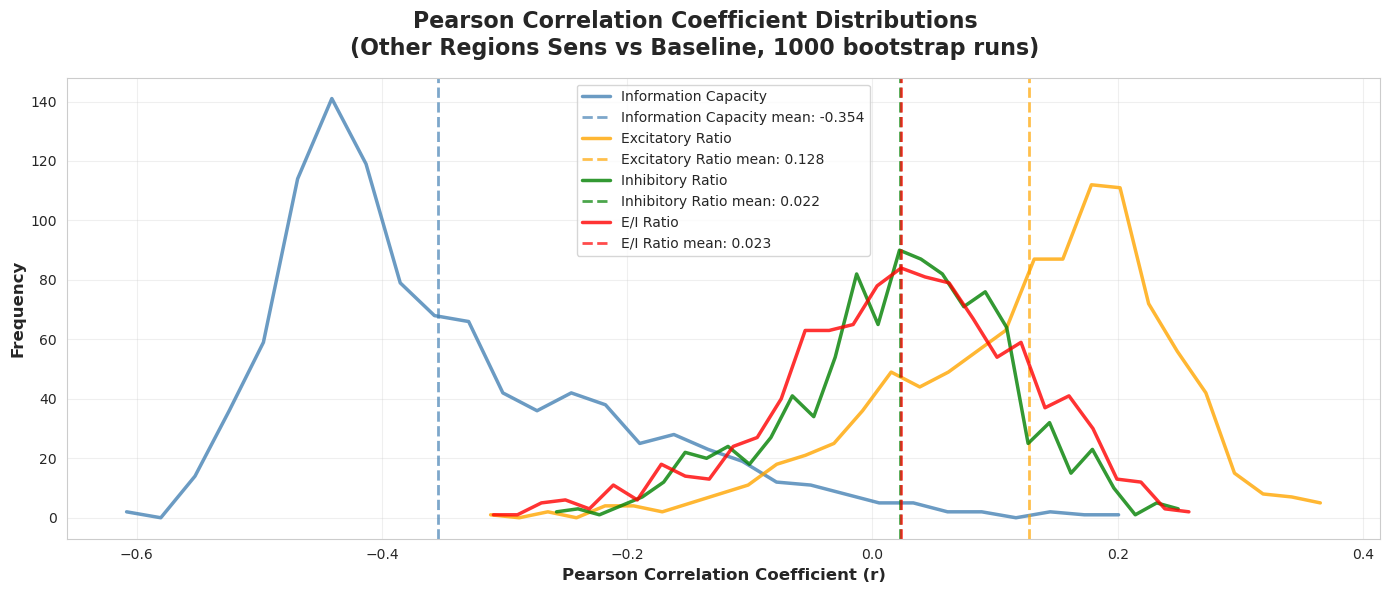

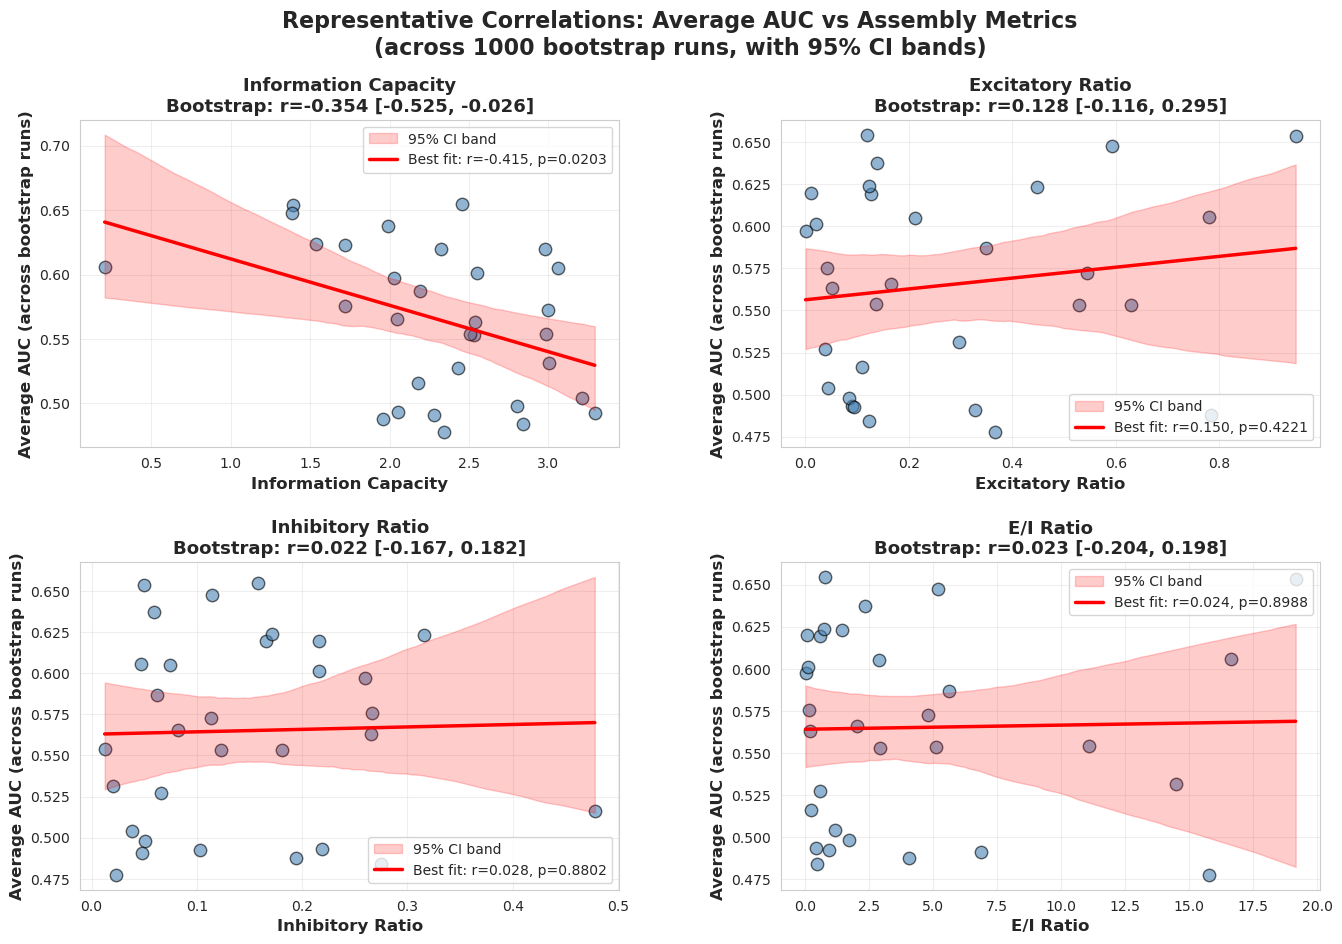

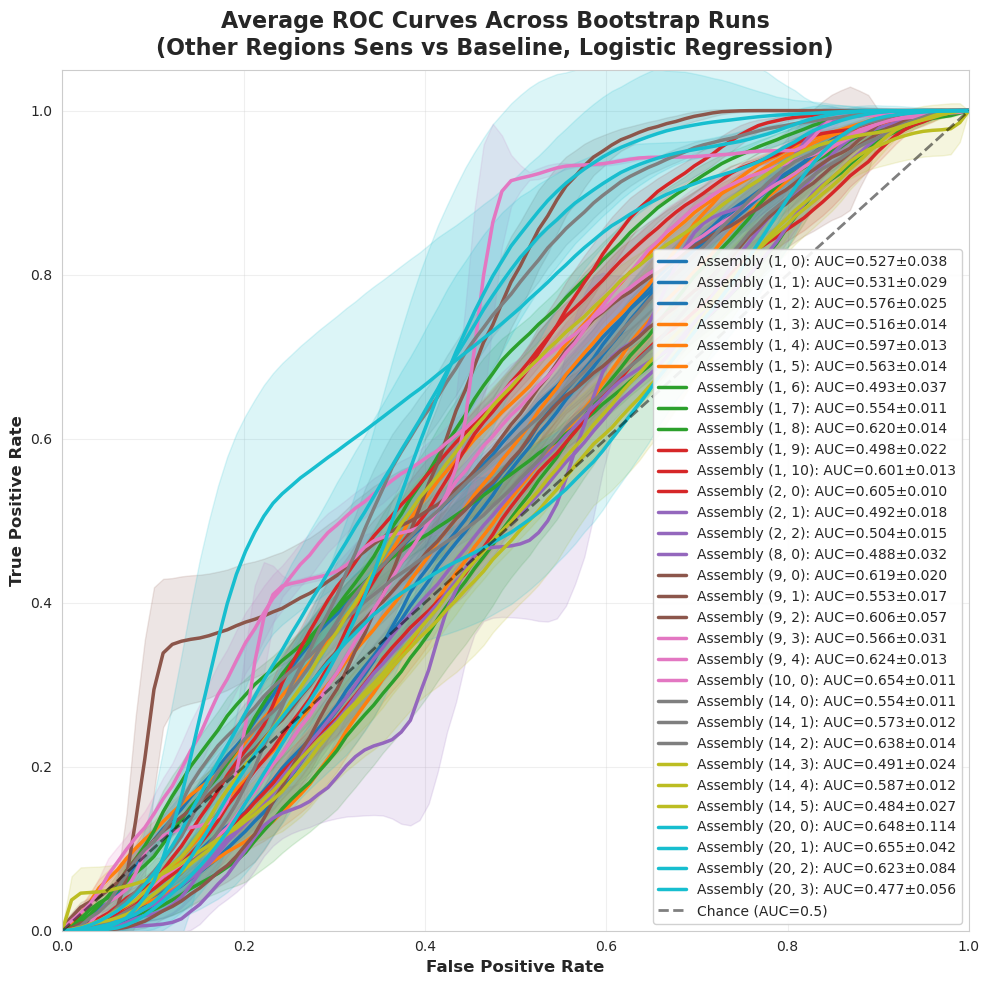


✓ Visualizations complete!
  - Correlation distributions: 4 metrics
  - Representative scatter plots: 4 metrics
  - Average ROC curves: 31 assemblies


In [16]:
# COMPREHENSIVE VISUALIZATIONS FOR BOOTSTRAP ANALYSIS
# 1. Correlation coefficient distributions with means
# 2. Representative correlation scatter plots with best fit lines
# 3. Representative ROC curves (if available)

print(f"\n{'='*80}")
print("COMPREHENSIVE BOOTSTRAP VISUALIZATIONS")
print(f"{'='*80}\n")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_curve, auc
from scipy.interpolate import interp1d

plt.rcParams['svg.fonttype'] = 'none'
sns.set_style("whitegrid")

# ============================================================================
# 1. PEARSON CORRELATION COEFFICIENT DISTRIBUTIONS (line plots with means)
# ============================================================================

fig1 = plt.figure(figsize=(14, 6))
ax1 = fig1.add_subplot(1, 1, 1)

fig1.suptitle('Pearson Correlation Coefficient Distributions\n(Other Regions Sens vs Baseline, 1000 bootstrap runs)', 
             fontsize=16, fontweight='bold', y=0.98)

metrics_to_correlate = ['information_capacity', 'excitatory_ratio', 'inhibitory_ratio', 'ei_ratio']
metric_labels = {
    'information_capacity': 'Information Capacity',
    'excitatory_ratio': 'Excitatory Ratio',
    'inhibitory_ratio': 'Inhibitory Ratio',
    'ei_ratio': 'E/I Ratio'
}

colors = ['steelblue', 'orange', 'green', 'red']
for idx, metric in enumerate(metrics_to_correlate):
    metric_corrs = df_correlations[df_correlations['metric'] == metric]
    pearson_rs = metric_corrs['pearson_r'].values
    
    # Create histogram data
    counts, bins = np.histogram(pearson_rs, bins=30)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Plot as line plot (step plot)
    ax1.plot(bin_centers, counts, linewidth=2.5, color=colors[idx], 
            label=metric_labels[metric], alpha=0.8)
    
    # Add mean line
    mean_r = np.mean(pearson_rs)
    ax1.axvline(mean_r, color=colors[idx], linestyle='--', linewidth=2, 
               alpha=0.7, label=f'{metric_labels[metric]} mean: {mean_r:.3f}')

ax1.set_xlabel('Pearson Correlation Coefficient (r)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("bootstrap_coefficients_control.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 2. REPRESENTATIVE CORRELATION SCATTER PLOTS
# (Average AUC across bootstrap runs vs each metric)
# ============================================================================

# Compute average AUC for each assembly across all bootstrap runs
avg_auc_by_assembly = df_bootstrap.groupby('assembly_id')['auc'].mean().reset_index()
avg_auc_by_assembly.columns = ['assembly_id', 'avg_auc']

# Get metric values (same for all runs, so just take first run)
first_run_data = df_bootstrap[df_bootstrap['run'] == df_bootstrap['run'].min()].copy()
assembly_metrics = first_run_data[['assembly_id', 'information_capacity', 
                                    'excitatory_ratio', 'inhibitory_ratio', 'ei_ratio']].copy()

# Merge
plot_data = avg_auc_by_assembly.merge(assembly_metrics, on='assembly_id', how='inner')

fig2 = plt.figure(figsize=(16, 10))
gs2 = fig2.add_gridspec(2, 2, hspace=0.35, wspace=0.3)

fig2.suptitle('Representative Correlations: Average AUC vs Assembly Metrics\n(across 1000 bootstrap runs, with 95% CI bands)', 
             fontsize=16, fontweight='bold', y=0.99)

for idx, metric in enumerate(metrics_to_correlate):
    row = idx // 2
    col = idx % 2
    ax = fig2.add_subplot(gs2[row, col])
    
    # Get data for this metric
    x = plot_data[metric].values
    y = plot_data['avg_auc'].values
    
    # Remove NaN values
    valid_mask = ~(np.isnan(x) | np.isnan(y))
    x_clean = x[valid_mask]
    y_clean = y[valid_mask]
    
    if len(x_clean) > 1:
        # Scatter plot
        ax.scatter(x_clean, y_clean, alpha=0.6, s=80, color='steelblue', edgecolors='black', linewidth=1)
        
        # Linear regression
        slope, intercept, r_value, p_value, std_err = stats.linregress(x_clean, y_clean)
        
        # Create line of best fit
        x_line = np.linspace(x_clean.min(), x_clean.max(), 100)
        y_line = slope * x_line + intercept
        
        # Calculate confidence interval for the regression line
        # Using bootstrap method for CI
        n_boot = 1000
        slopes = []
        intercepts = []
        for _ in range(n_boot):
            indices = np.random.choice(len(x_clean), len(x_clean), replace=True)
            x_boot = x_clean[indices]
            y_boot = y_clean[indices]
            try:
                s, i, _, _, _ = stats.linregress(x_boot, y_boot)
                slopes.append(s)
                intercepts.append(i)
            except:
                continue
        
        slopes = np.array(slopes)
        intercepts = np.array(intercepts)
        
        # Calculate CI for each x point
        y_line_lower = np.zeros_like(x_line)
        y_line_upper = np.zeros_like(x_line)
        for i, x_val in enumerate(x_line):
            y_vals = slopes * x_val + intercepts
            y_line_lower[i] = np.percentile(y_vals, 2.5)
            y_line_upper[i] = np.percentile(y_vals, 97.5)
        
        # Plot CI band
        ax.fill_between(x_line, y_line_lower, y_line_upper, alpha=0.2, color='red', 
                       label='95% CI band')
        
        # Plot best fit line
        ax.plot(x_line, y_line, 'r-', linewidth=2.5, label=f'Best fit: r={r_value:.3f}, p={p_value:.4f}')
        
        # Get correlation from bootstrap analysis
        metric_corrs = df_correlations[df_correlations['metric'] == metric]
        bootstrap_mean_r = metric_corrs['pearson_r'].mean()
        bootstrap_ci_lower = np.percentile(metric_corrs['pearson_r'], 2.5)
        bootstrap_ci_upper = np.percentile(metric_corrs['pearson_r'], 97.5)
        
        ax.set_xlabel(metric_labels[metric], fontsize=12, fontweight='bold')
        ax.set_ylabel('Average AUC (across bootstrap runs)', fontsize=12, fontweight='bold')
        ax.set_title(f'{metric_labels[metric]}\n'
                    f'Bootstrap: r={bootstrap_mean_r:.3f} [{bootstrap_ci_lower:.3f}, {bootstrap_ci_upper:.3f}]', 
                    fontsize=13, fontweight='bold')
        ax.legend(loc='best', fontsize=10)
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', 
               transform=ax.transAxes, fontsize=14)
        ax.set_title(metric_labels[metric], fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig("bootstrap_correlations_control.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 3. AVERAGE ROC CURVES FOR EACH ASSEMBLY (ALL ON SAME AXES)
# ============================================================================

# Get unique assemblies
unique_assemblies = df_bootstrap['assembly_id'].unique()

# Create single figure with one axes
fig3 = plt.figure(figsize=(10, 10))
ax3 = fig3.add_subplot(1, 1, 1)

fig3.suptitle('Average ROC Curves Across Bootstrap Runs\n(Other Regions Sens vs Baseline, Logistic Regression)', 
             fontsize=16, fontweight='bold', y=0.98)

# Use a colormap to get different colors for each assembly
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_assemblies)))

# Interpolate all ROC curves to common FPR points
all_fpr = np.linspace(0, 1, 100)

for idx, assembly_id in enumerate(unique_assemblies):
    # Get all ROC curves for this assembly across all bootstrap runs
    assembly_mask = df_bootstrap['assembly_id'] == assembly_id
    assembly_fprs = df_bootstrap.loc[assembly_mask, 'fpr'].values
    assembly_tprs = df_bootstrap.loc[assembly_mask, 'tpr'].values
    assembly_aucs = df_bootstrap.loc[assembly_mask, 'auc'].values
    
    if len(assembly_fprs) > 0:
        # Interpolate all ROC curves to common FPR points
        all_tpr = []
        
        for fpr_array, tpr_array in zip(assembly_fprs, assembly_tprs):
            # Handle case where fpr/tpr might be stored as lists
            if isinstance(fpr_array, (list, np.ndarray)) and isinstance(tpr_array, (list, np.ndarray)):
                fpr_array = np.array(fpr_array)
                tpr_array = np.array(tpr_array)
                # Interpolate
                tpr_interp = np.interp(all_fpr, fpr_array, tpr_array)
                all_tpr.append(tpr_interp)
        
        if len(all_tpr) > 0:
            all_tpr = np.array(all_tpr)
            mean_tpr = np.mean(all_tpr, axis=0)
            std_tpr = np.std(all_tpr, axis=0)
            mean_auc = np.mean(assembly_aucs)
            std_auc = np.std(assembly_aucs)
            
            # Plot mean with confidence interval
            ax3.plot(all_fpr, mean_tpr, color=colors[idx], lw=2.5, 
                   label=f'Assembly {assembly_id}: AUC={mean_auc:.3f}±{std_auc:.3f}')
            ax3.fill_between(all_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr,
                           color=colors[idx], alpha=0.15)

# Plot chance line (only once)
ax3.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5, label='Chance (AUC=0.5)')

ax3.set_xlim([0.0, 1.0])
ax3.set_ylim([0.0, 1.05])
ax3.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax3.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax3.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("bootstrap_roc_curves_control.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Visualizations complete!")
print(f"  - Correlation distributions: {len(metrics_to_correlate)} metrics")
print(f"  - Representative scatter plots: {len(metrics_to_correlate)} metrics")
print(f"  - Average ROC curves: {len(unique_assemblies)} assemblies")

In [14]:
# Other-regions (control) assemblies: capacity + E/I
# Run after the OTHER REGIONS PER-ASSEMBLY bootstrap cell (creates df_bootstrap_other).
import numpy as np
import pandas as pd

if "df_bootstrap_other" not in globals():
    raise RuntimeError(
        "Run the other-regions PER-ASSEMBLY bootstrap cell first (it creates df_bootstrap_other)."
    )

b = df_bootstrap_other.copy()


def _assembly_id_parts(aid):
    if isinstance(aid, tuple) and len(aid) == 2:
        return int(aid[0]), int(aid[1])
    if isinstance(aid, list) and len(aid) == 2:
        return int(aid[0]), int(aid[1])
    import ast

    t = ast.literal_eval(str(aid))
    return int(t[0]), int(t[1])


b["insertion_idx"] = b["assembly_id"].apply(lambda a: _assembly_id_parts(a)[0])
b["assembly_idx"] = b["assembly_id"].apply(lambda a: _assembly_id_parts(a)[1])

cols = [
    "insertion_idx",
    "assembly_idx",
    "information_capacity",
    "excitatory_ratio",
    "inhibitory_ratio",
    "ei_ratio",
]
other_asm = (
    b[cols]
    .drop_duplicates(subset=["insertion_idx", "assembly_idx"])
    .sort_values(["insertion_idx", "assembly_idx"])
    .reset_index(drop=True)
)

other_asm = other_asm.rename(
    columns={
        "information_capacity": "information_capacity",
        "excitatory_ratio": "E_ratio",
        "inhibitory_ratio": "I_ratio",
        "ei_ratio": "EI_ratio",
    }
)

print(f"Other-regions assemblies in table: {len(other_asm)}")
display(other_asm)


def _tukey_outliers(series, k=1.5):
    """Return mask for values outside Tukey fences (k=1.5 standard, k=3 extreme)."""
    x = series.dropna().astype(float)
    if len(x) < 4:
        return pd.Series(False, index=series.index), np.nan, np.nan, np.nan, np.nan, np.nan
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    mask = series.notna() & ((series < lo) | (series > hi))
    return mask, q1, q3, iqr, lo, hi


print("\n" + "=" * 80)
print("OUTLIER CHECK (Tukey IQR) — other regions")
print("=" * 80)

for col, label in [
    ("information_capacity", "information_capacity"),
    ("E_ratio", "E_ratio"),
    ("I_ratio", "I_ratio"),
    ("EI_ratio", "EI_ratio"),
]:
    m15, q1, q3, iqr, lo15, hi15 = _tukey_outliers(other_asm[col], k=1.5)
    m3, _, _, _, lo3, hi3 = _tukey_outliers(other_asm[col], k=3.0)
    print(f"\n{label}: Q1={q1:.6f}, Q3={q3:.6f}, IQR={iqr:.6f}")
    print(f"  Standard fences (1.5*IQR): [{lo15:.6f}, {hi15:.6f}]")
    print(f"  Extreme fences   (3*IQR):  [{lo3:.6f}, {hi3:.6f}]")
    n15, n3 = int(m15.sum()), int(m3.sum())
    print(f"  Standard outliers (1.5*IQR): {n15}")
    if n15:
        display(other_asm.loc[m15, ["insertion_idx", "assembly_idx", col]])
    print(f"  Extreme outliers (3*IQR): {n3}")
    if n3:
        display(other_asm.loc[m3, ["insertion_idx", "assembly_idx", col]])

Other-regions assemblies in table: 32


,insertion_idx,assembly_idx,information_capacity,E_ratio,I_ratio,EI_ratio
0,1,0,2.430465,0.037202,0.066177,0.562161
1,1,1,3.001510,0.296283,0.020473,14.472252
2,1,2,1.720850,0.041496,0.266433,0.155748
3,1,3,2.179481,0.109504,0.477911,0.229132
4,1,4,2.027177,0.000503,0.259384,0.001938
5,1,5,2.537094,0.052000,0.265038,0.196199
6,1,6,2.053415,0.090352,0.218540,0.413435
7,1,7,2.985758,0.137522,0.012428,11.065883
8,1,8,2.322790,0.010874,0.165778,0.065591
9,1,9,2.803662,0.085085,0.050341,1.690164



OUTLIER CHECK (Tukey IQR) — other regions

information_capacity: Q1=2.017986, Q3=2.812624, IQR=0.794638
  Standard fences (1.5*IQR): [0.826030, 4.004580]
  Extreme fences   (3*IQR):  [-0.365927, 5.196537]
  Standard outliers (1.5*IQR): 1


,insertion_idx,assembly_idx,information_capacity
17,9,2,0.205111


  Extreme outliers (3*IQR): 0

E_ratio: Q1=0.089035, Q3=0.386700, IQR=0.297664
  Standard fences (1.5*IQR): [-0.357461, 0.833196]
  Extreme fences   (3*IQR):  [-0.803958, 1.279693]
  Standard outliers (1.5*IQR): 1


...

,insertion_idx,assembly_idx,I_ratio
3,1,3,0.477911


  Extreme outliers (3*IQR): 0

EI_ratio: Q1=0.534148, Q3=5.293573, IQR=4.759424
  Standard fences (1.5*IQR): [-6.604988, 12.432709]
  Extreme fences   (3*IQR):  [-13.744125, 19.571846]
  Standard outliers (1.5*IQR): 5


,insertion_idx,assembly_idx,EI_ratio
1,1,1,14.472252
17,9,2,16.639004
20,10,0,19.154102
30,20,3,15.787403
31,20,4,57.958069


  Extreme outliers (3*IQR): 1


,insertion_idx,assembly_idx,EI_ratio
31,20,4,57.958069


AUC COMPARISON BY ASSEMBLY: pSTG vs OTHER REGIONS
(Average AUC per assembly across all bootstrap runs)

Calculating average AUC per assembly for pSTG...
  Found 17 pSTG assemblies
  Mean assembly AUC = 0.6333 ± 0.1181
  Median assembly AUC = 0.6302
  Range: [0.3422, 0.8143]

Calculating average AUC per assembly for other regions...
  Found 31 other region assemblies
  Mean assembly AUC = 0.5650 ± 0.0568
  Median assembly AUC = 0.5658
  Range: [0.4774, 0.6546]

STATISTICAL TEST
Using Student's t-test (equal variances assumed, one-sided, H1: mean_pSTG > mean_other)

t-statistic = 2.7113
one-sided p-value = 0.004696
Significance: ** (p < 0.01)


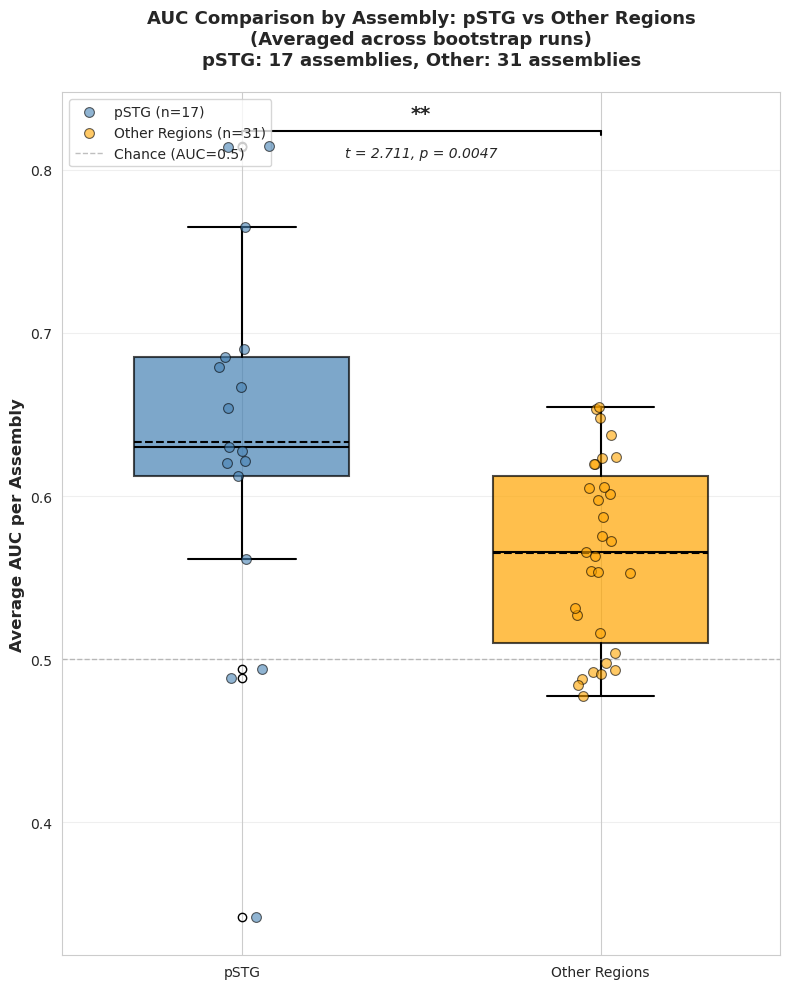


SUMMARY TABLE
       Region  N Assemblies  Mean AUC  Std AUC  Median AUC  Min AUC  Max AUC
         pSTG            17  0.633290 0.114619    0.630220 0.342233 0.814268
Other Regions            31  0.565035 0.055862    0.565771 0.477441 0.654595

COMPARISON COMPLETE

✓ Plot saved as 'auc_comparison_by_assembly_pstg_vs_other.svg'


In [17]:
# COMPARE AUCs BY ASSEMBLY: pSTG vs OTHER REGIONS
# Averages AUC across all bootstrap runs for each assembly, then compares groups
# Statistical comparison using standard one-sided t-test (Student's t-test, equal variance, alternative='greater')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['svg.fonttype'] = 'none'
sns.set_style("whitegrid")

print("=" * 80)
print("AUC COMPARISON BY ASSEMBLY: pSTG vs OTHER REGIONS")
print("(Average AUC per assembly across all bootstrap runs)")
print("=" * 80)

# Check if the saved dataframes exist
if 'df_bootstrap_pstg' not in globals():
    print("\n⚠️  Warning: df_bootstrap_pstg not found.")
    print("   Please run the pSTG bootstrap cell (Cell 17) first.")
    raise NameError("df_bootstrap_pstg not found. Please run Cell 17 first.")

if 'df_bootstrap_other' not in globals():
    print("\n⚠️  Warning: df_bootstrap_other not found.")
    print("   Please run the other regions bootstrap cell (Cell 19) first.")
    raise NameError("df_bootstrap_other not found. Please run Cell 19 first.")

# Calculate average AUC per assembly for pSTG
print("\nCalculating average AUC per assembly for pSTG...")
pstg_avg_auc = df_bootstrap_pstg.groupby('assembly_id')['auc'].mean().reset_index()
pstg_avg_auc.columns = ['assembly_id', 'avg_auc']
pstg_avg_auc['region'] = 'pSTG'

print(f"  Found {len(pstg_avg_auc)} pSTG assemblies")
print(f"  Mean assembly AUC = {pstg_avg_auc['avg_auc'].mean():.4f} ± {pstg_avg_auc['avg_auc'].std():.4f}")
print(f"  Median assembly AUC = {pstg_avg_auc['avg_auc'].median():.4f}")
print(f"  Range: [{pstg_avg_auc['avg_auc'].min():.4f}, {pstg_avg_auc['avg_auc'].max():.4f}]")

# Calculate average AUC per assembly for other regions
print("\nCalculating average AUC per assembly for other regions...")
other_avg_auc = df_bootstrap_other.groupby('assembly_id')['auc'].mean().reset_index()
other_avg_auc.columns = ['assembly_id', 'avg_auc']
other_avg_auc['region'] = 'Other Regions'

print(f"  Found {len(other_avg_auc)} other region assemblies")
print(f"  Mean assembly AUC = {other_avg_auc['avg_auc'].mean():.4f} ± {other_avg_auc['avg_auc'].std():.4f}")
print(f"  Median assembly AUC = {other_avg_auc['avg_auc'].median():.4f}")
print(f"  Range: [{other_avg_auc['avg_auc'].min():.4f}, {other_avg_auc['avg_auc'].max():.4f}]")

# Extract average AUC values for statistical test
auc_pstg_assemblies = pstg_avg_auc['avg_auc'].values
auc_other_assemblies = other_avg_auc['avg_auc'].values

# One-sided Student's t-test: H0: mean_pstg <= mean_other, H1: mean_pstg > mean_other
t_stat, t_pval_one_sided = stats.ttest_ind(auc_pstg_assemblies, auc_other_assemblies, equal_var=True, alternative='greater')

print(f"\n{'='*80}")
print("STATISTICAL TEST")
print(f"{'='*80}")
print("Using Student's t-test (equal variances assumed, one-sided, H1: mean_pSTG > mean_other)")

print(f"\nt-statistic = {t_stat:.4f}")
print(f"one-sided p-value = {t_pval_one_sided:.6f}")

if t_pval_one_sided < 0.001:
    sig_text = "*** (p < 0.001)"
elif t_pval_one_sided < 0.01:
    sig_text = "** (p < 0.01)"
elif t_pval_one_sided < 0.05:
    sig_text = "* (p < 0.05)"
else:
    sig_text = "ns (p >= 0.05)"

print(f"Significance: {sig_text}")

# Create box plot with overlaid data points
fig, ax = plt.subplots(figsize=(8, 10))

# Prepare data for plotting
data_to_plot = [auc_pstg_assemblies, auc_other_assemblies]
labels = ['pSTG', 'Other Regions']
colors = ['steelblue', 'orange']

# Create box plot
bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, 
                widths=0.6, showmeans=True, meanline=True)

# Color the boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

# Style the other elements
for element in ['whiskers', 'fliers', 'means', 'medians', 'caps']:
    if element in bp:
        for item in bp[element]:
            item.set_color('black')
            item.set_linewidth(1.5)

# Overlay individual data points with jitter
for i, (data, color) in enumerate(zip(data_to_plot, colors)):
    # Add jitter to x positions
    x_pos = np.random.normal(i+1, 0.04, size=len(data))
    ax.scatter(x_pos, data, alpha=0.6, s=50, color=color, 
              edgecolors='black', linewidth=0.8, zorder=10, label=f'{labels[i]} (n={len(data)})')

# Add statistical annotation
y_max = max(np.max(auc_pstg_assemblies), np.max(auc_other_assemblies))
y_min = min(np.min(auc_pstg_assemblies), np.min(auc_other_assemblies))
y_range = y_max - y_min

# Draw bracket for significance
y_bracket = y_max + 0.02 * y_range
ax.plot([1, 2], [y_bracket, y_bracket], 'k-', linewidth=1.5)
ax.plot([1, 1], [y_bracket - 0.005 * y_range, y_bracket], 'k-', linewidth=1.5)
ax.plot([2, 2], [y_bracket - 0.005 * y_range, y_bracket], 'k-', linewidth=1.5)

# Add text annotation
if t_pval_one_sided < 0.001:
    sig_symbol = "***"
elif t_pval_one_sided < 0.01:
    sig_symbol = "**"
elif t_pval_one_sided < 0.05:
    sig_symbol = "*"
else:
    sig_symbol = "ns"

ax.text(1.5, y_bracket + 0.01 * y_range, sig_symbol, 
        ha='center', va='bottom', fontsize=14, fontweight='bold')

# Add test statistics text
stats_text = f"t = {t_stat:.3f}, p = {t_pval_one_sided:.4f}"
ax.text(1.5, y_bracket - 0.02 * y_range, stats_text,
        ha='center', va='top', fontsize=10, style='italic')

# Customize axes
ax.set_ylabel('Average AUC per Assembly', fontsize=12, fontweight='bold')
ax.set_title('AUC Comparison by Assembly: pSTG vs Other Regions\n' + 
            f'(Averaged across bootstrap runs)\n' +
            f'pSTG: {len(auc_pstg_assemblies)} assemblies, Other: {len(auc_other_assemblies)} assemblies',
            fontsize=13, fontweight='bold', pad=20)
ax.set_ylim([y_min - 0.05 * y_range, y_bracket + 0.05 * y_range])
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Chance (AUC=0.5)')
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig("auc_comparison_by_assembly_pstg_vs_other.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# Create summary table
print(f"\n{'='*80}")
print("SUMMARY TABLE")
print(f"{'='*80}")
summary_df = pd.DataFrame({
    'Region': ['pSTG', 'Other Regions'],
    'N Assemblies': [len(auc_pstg_assemblies), len(auc_other_assemblies)],
    'Mean AUC': [np.mean(auc_pstg_assemblies), np.mean(auc_other_assemblies)],
    'Std AUC': [np.std(auc_pstg_assemblies), np.std(auc_other_assemblies)],
    'Median AUC': [np.median(auc_pstg_assemblies), np.median(auc_other_assemblies)],
    'Min AUC': [np.min(auc_pstg_assemblies), np.min(auc_other_assemblies)],
    'Max AUC': [np.max(auc_pstg_assemblies), np.max(auc_other_assemblies)]
})
print(summary_df.to_string(index=False))

print(f"\n{'='*80}")
print("COMPARISON COMPLETE")
print(f"{'='*80}")
print(f"\n✓ Plot saved as 'auc_comparison_by_assembly_pstg_vs_other.svg'")


ROC CURVES: pSTG vs OTHER REGIONS
(Average ROC curves per assembly across all bootstrap runs)

pSTG: 17 assemblies
Other Regions: 31 assemblies

Processing pSTG assemblies...
Processing other region assemblies...


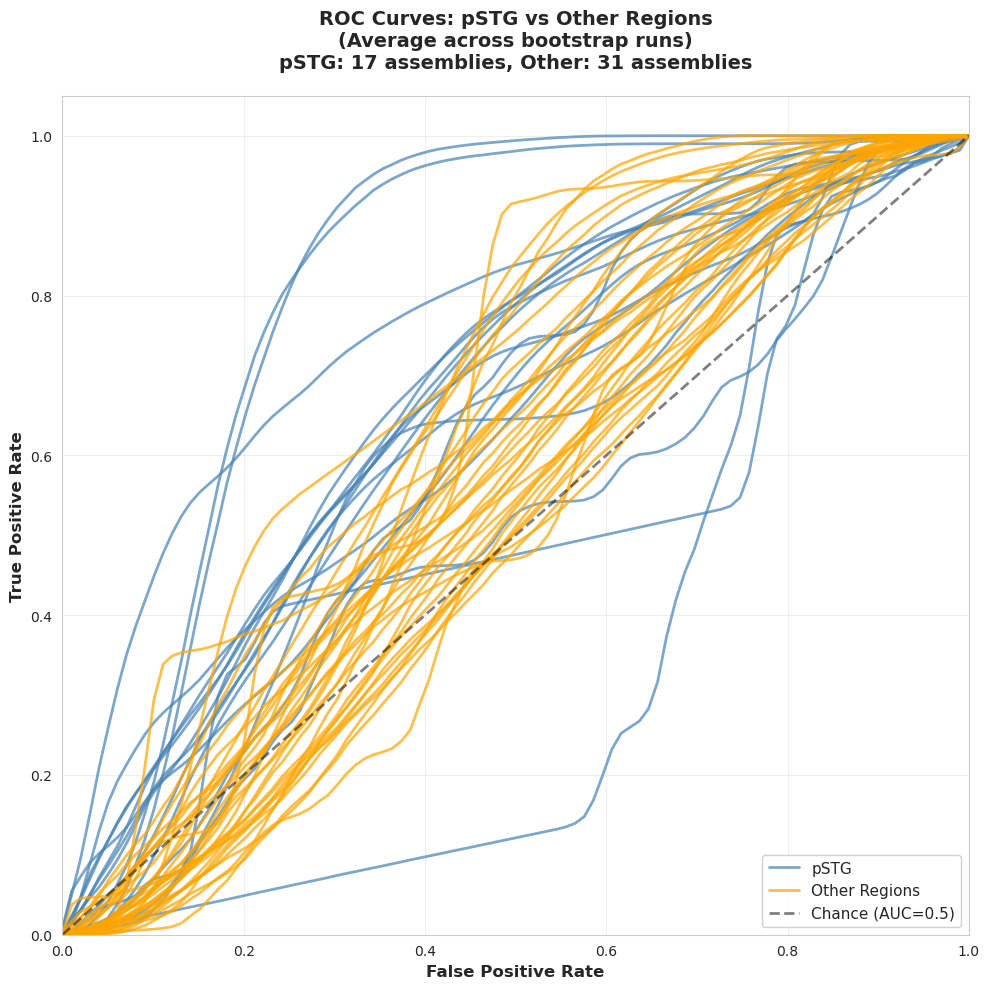


ROC COMPARISON COMPLETE

✓ Plotted 17 pSTG assemblies and 31 other region assemblies
✓ Plot saved as 'roc_curves_pstg_vs_other.svg'


In [18]:
# ROC CURVES: pSTG vs OTHER REGIONS
# Plots all average ROC curves together, colored by region category

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['svg.fonttype'] = 'none'
sns.set_style("whitegrid")

print("=" * 80)
print("ROC CURVES: pSTG vs OTHER REGIONS")
print("(Average ROC curves per assembly across all bootstrap runs)")
print("=" * 80)

# Check if the saved dataframes exist
if 'df_bootstrap_pstg' not in globals():
    print("\n⚠️  Warning: df_bootstrap_pstg not found.")
    print("   Please run the pSTG bootstrap cell (Cell 17) first.")
    raise NameError("df_bootstrap_pstg not found. Please run Cell 17 first.")

if 'df_bootstrap_other' not in globals():
    print("\n⚠️  Warning: df_bootstrap_other not found.")
    print("   Please run the other regions bootstrap cell (Cell 19) first.")
    raise NameError("df_bootstrap_other not found. Please run Cell 19 first.")

# Get unique assemblies for each region category
pstg_assemblies = df_bootstrap_pstg['assembly_id'].unique()
other_assemblies = df_bootstrap_other['assembly_id'].unique()

print(f"\npSTG: {len(pstg_assemblies)} assemblies")
print(f"Other Regions: {len(other_assemblies)} assemblies")

# Create figure
fig, ax = plt.subplots(figsize=(10, 10))

# Colors for each category
pstg_color = 'steelblue'
other_color = 'orange'

# Interpolate all ROC curves to common FPR points
all_fpr = np.linspace(0, 1, 100)

# Plot pSTG ROC curves
print("\nProcessing pSTG assemblies...")
pstg_count = 0
for assembly_id in pstg_assemblies:
    assembly_mask = df_bootstrap_pstg['assembly_id'] == assembly_id
    assembly_fprs = df_bootstrap_pstg.loc[assembly_mask, 'fpr'].values
    assembly_tprs = df_bootstrap_pstg.loc[assembly_mask, 'tpr'].values
    assembly_aucs = df_bootstrap_pstg.loc[assembly_mask, 'auc'].values
    
    if len(assembly_fprs) > 0:
        # Interpolate all ROC curves to common FPR points
        all_tpr = []
        
        for fpr_array, tpr_array in zip(assembly_fprs, assembly_tprs):
            if isinstance(fpr_array, (list, np.ndarray)) and isinstance(tpr_array, (list, np.ndarray)):
                fpr_array = np.array(fpr_array)
                tpr_array = np.array(tpr_array)
                tpr_interp = np.interp(all_fpr, fpr_array, tpr_array)
                all_tpr.append(tpr_interp)
        
        if len(all_tpr) > 0:
            all_tpr = np.array(all_tpr)
            mean_tpr = np.mean(all_tpr, axis=0)
            mean_auc = np.mean(assembly_aucs)
            
            # Plot mean ROC curve
            ax.plot(all_fpr, mean_tpr, color=pstg_color, lw=2, alpha=0.7, 
                   label='pSTG' if pstg_count == 0 else '')
            pstg_count += 1

# Plot other regions ROC curves
print("Processing other region assemblies...")
other_count = 0
for assembly_id in other_assemblies:
    assembly_mask = df_bootstrap_other['assembly_id'] == assembly_id
    assembly_fprs = df_bootstrap_other.loc[assembly_mask, 'fpr'].values
    assembly_tprs = df_bootstrap_other.loc[assembly_mask, 'tpr'].values
    assembly_aucs = df_bootstrap_other.loc[assembly_mask, 'auc'].values
    
    if len(assembly_fprs) > 0:
        # Interpolate all ROC curves to common FPR points
        all_tpr = []
        
        for fpr_array, tpr_array in zip(assembly_fprs, assembly_tprs):
            if isinstance(fpr_array, (list, np.ndarray)) and isinstance(tpr_array, (list, np.ndarray)):
                fpr_array = np.array(fpr_array)
                tpr_array = np.array(tpr_array)
                tpr_interp = np.interp(all_fpr, fpr_array, tpr_array)
                all_tpr.append(tpr_interp)
        
        if len(all_tpr) > 0:
            all_tpr = np.array(all_tpr)
            mean_tpr = np.mean(all_tpr, axis=0)
            mean_auc = np.mean(assembly_aucs)
            
            # Plot mean ROC curve
            ax.plot(all_fpr, mean_tpr, color=other_color, lw=2, alpha=0.7,
                   label='Other Regions' if other_count == 0 else '')
            other_count += 1

# Plot chance line
ax.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5, label='Chance (AUC=0.5)')

# Customize axes
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curves: pSTG vs Other Regions\n' + 
            f'(Average across bootstrap runs)\n' +
            f'pSTG: {pstg_count} assemblies, Other: {other_count} assemblies',
            fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='lower right', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("roc_curves_pstg_vs_other.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*80}")
print("ROC COMPARISON COMPLETE")
print(f"{'='*80}")
print(f"\n✓ Plotted {pstg_count} pSTG assemblies and {other_count} other region assemblies")
print(f"✓ Plot saved as 'roc_curves_pstg_vs_other.svg'")

In [19]:
# ============================================================================
# CALCULATE BOOTSTRAP P-VALUES FOR EACH CORRELATION
# For both pSTG and Other Regions
# ============================================================================
# The p-value is the proportion of bootstrap samples that are as or more 
# extreme than the observed correlation (or on the opposite side of zero)

print(f"\n{'='*80}")
print("BOOTSTRAP P-VALUE CALCULATION")
print(f"{'='*80}\n")

# Check which datasets are available
datasets = {}
if 'df_correlations_pstg' in globals():
    datasets['pSTG'] = df_correlations_pstg
    print("✓ Found pSTG correlation data")
if 'df_correlations_other' in globals():
    datasets['Other Regions'] = df_correlations_other
    print("✓ Found Other Regions correlation data")

if len(datasets) == 0:
    print("⚠️  Warning: No correlation datasets found!")
    print("   Please run the bootstrap analysis cells first.")
    raise NameError("No correlation datasets found")

metrics_to_correlate = ['information_capacity', 'excitatory_ratio', 'inhibitory_ratio', 'ei_ratio']
metric_labels = {
    'information_capacity': 'Information Capacity',
    'excitatory_ratio': 'Excitatory Ratio',
    'inhibitory_ratio': 'Inhibitory Ratio',
    'ei_ratio': 'E/I Ratio'
}

# Store results for both datasets
all_results = {}

for dataset_name, df_correlations in datasets.items():
    print(f"\n{'='*80}")
    print(f"{dataset_name.upper()}")
    print(f"{'='*80}")
    
    bootstrap_pvalues = {}
    
    for metric in metrics_to_correlate:
        metric_corrs = df_correlations[df_correlations['metric'] == metric]
        bootstrap_rs = metric_corrs['pearson_r'].values
        
        if len(bootstrap_rs) == 0:
            continue
        
        # Calculate observed correlation (mean of bootstrap distribution)
        observed_r = np.mean(bootstrap_rs)
        
        # Bootstrap p-value: One-sided test of H0: r = 0
        # Count bootstrap samples on opposite side of zero
        # Note: For one-sided tests, use alpha=0.025 for FDR correction (equivalent to two-sided alpha=0.05)
        if observed_r > 0:
            # Count how many bootstrap samples are <= 0 (or negative)
            n_extreme = np.sum(bootstrap_rs <= 0)
        else:
            # Count how many bootstrap samples are >= 0 (or positive)
            n_extreme = np.sum(bootstrap_rs >= 0)
        
        p_value = n_extreme / len(bootstrap_rs)
        
        # Calculate confidence intervals
        ci_lower = np.percentile(bootstrap_rs, 2.5)
        ci_upper = np.percentile(bootstrap_rs, 97.5)
        
        bootstrap_pvalues[metric] = {
            'observed_r': observed_r,
            'p_value': p_value,
            'n_bootstrap': len(bootstrap_rs),
            'n_extreme': n_extreme,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper,
        }
        
        print(f"\n{metric_labels[metric]}:")
        print(f"  Observed correlation (mean): {observed_r:.4f}")
        print(f"  95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
        print(f"  Bootstrap p-value (H0: r=0): {p_value:.6f}")
        print(f"    (Count: {n_extreme}/{len(bootstrap_rs)} bootstrap samples on opposite side of zero)")
        if p_value < 0.05:
            print(f"  ✓ Significant (p < 0.05)")
        else:
            print(f"  ✗ Not significant (p >= 0.05)")
    
    all_results[dataset_name] = bootstrap_pvalues

# Apply FDR correction (Benjamini-Hochberg) with Q=0.025 for one-sided tests
def benjamini_hochberg(p_values, alpha=0.025):
    """
    Benjamini-Hochberg FDR correction
    """
    n = len(p_values)
    # Sort p-values and keep track of original indices
    sorted_indices = np.argsort(p_values)
    sorted_p = p_values[sorted_indices]
    
    # Calculate adjusted p-values
    adjusted_p = np.zeros(n)
    for i in range(n-1, -1, -1):  # Start from the largest p-value
        if i == n-1:
            adjusted_p[i] = sorted_p[i]
        else:
            adjusted_p[i] = min(adjusted_p[i+1], sorted_p[i] * n / (i+1))
    
    # Map back to original order
    final_adjusted = np.zeros(n)
    final_adjusted[sorted_indices] = adjusted_p
    
    # Determine which are significant
    rejected = final_adjusted <= alpha
    
    return rejected, final_adjusted

# Apply FDR correction to each dataset
for dataset_name in datasets.keys():
    bootstrap_pvalues = all_results[dataset_name]
    # Collect p-values in order
    p_values_list = []
    metric_order = []
    for metric in metrics_to_correlate:
        if metric in bootstrap_pvalues:
            p_values_list.append(bootstrap_pvalues[metric]['p_value'])
            metric_order.append(metric)
    
    if len(p_values_list) > 0:
        p_values_array = np.array(p_values_list)
        rejected, p_corrected = benjamini_hochberg(p_values_array, alpha=0.025)
        
        # Store FDR-corrected p-values back in the dictionary
        for i, metric in enumerate(metric_order):
            bootstrap_pvalues[metric]['p_value_fdr'] = p_corrected[i]
            bootstrap_pvalues[metric]['significant_fdr'] = rejected[i]

# Print summary table for both datasets
print(f"\n\n{'='*80}")
print("SUMMARY - ALL DATASETS")
print(f"{'='*80}")

for dataset_name in datasets.keys():
    print(f"\n{dataset_name.upper()}:")
    print(f"{'Metric':<25} {'r (mean)':<12} {'95% CI':<20} {'p-value':<10} {'FDR p (Q=0.025)':<18} {'Significant'}")
    print("-" * 100)
    bootstrap_pvalues = all_results[dataset_name]
    for metric in metrics_to_correlate:
        if metric in bootstrap_pvalues:
            pval = bootstrap_pvalues[metric]
            # Use FDR-corrected p-value for significance (Q=0.025)
            sig = "✓" if pval.get('significant_fdr', False) else "✗"
            ci_str = f"[{pval['ci_lower']:.3f}, {pval['ci_upper']:.3f}]"
            fdr_p = pval.get('p_value_fdr', np.nan)
            print(f"{metric_labels[metric]:<25} {pval['observed_r']:>10.4f}  {ci_str:<20} {pval['p_value']:>9.6f}  {fdr_p:>17.6f}  {sig}")


BOOTSTRAP P-VALUE CALCULATION

✓ Found pSTG correlation data
✓ Found Other Regions correlation data

PSTG

Information Capacity:
  Observed correlation (mean): 0.6747
  95% CI: [0.5636, 0.7710]
  Bootstrap p-value (H0: r=0): 0.000000
    (Count: 0/1000 bootstrap samples on opposite side of zero)
  ✓ Significant (p < 0.05)

Excitatory Ratio:
  Observed correlation (mean): -0.4055
  95% CI: [-0.5757, -0.2316]
  Bootstrap p-value (H0: r=0): 0.000000
    (Count: 0/1000 bootstrap samples on opposite side of zero)
  ✓ Significant (p < 0.05)

Inhibitory Ratio:
  Observed correlation (mean): 0.3719
  95% CI: [0.2549, 0.4781]
  Bootstrap p-value (H0: r=0): 0.000000
    (Count: 0/1000 bootstrap samples on opposite side of zero)
  ✓ Significant (p < 0.05)

E/I Ratio:
  Observed correlation (mean): -0.4273
  95% CI: [-0.6450, -0.2085]
  Bootstrap p-value (H0: r=0): 0.000000
    (Count: 0/1000 bootstrap samples on opposite side of zero)
  ✓ Significant (p < 0.05)

OTHER REGIONS

Information Capaci